In [1]:
# ============================================================
# Financial Operations Analytics
# Developed by: Anurag Singh
# Project: Revenue Forecasting, Churn & Profitability Analysis
# ============================================================

# --- Core libraries for data handling ---
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')  # Suppressing warnings to keep output clean

# --- Visualization libraries ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- Statistical analysis tools ---
from scipy import stats
from scipy.stats import normaltest, kstest
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- Machine Learning models and utilities ---
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# --- Time series forecasting using Facebook Prophet ---
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    print("Prophet not installed. Run: pip install prophet")
    PROPHET_AVAILABLE = False

# --- Other utility libraries ---
import os
import json
from collections import defaultdict

# ============================================================
# Notebook Display & Style Configuration
# ============================================================

# Showing all columns and limiting rows for clean output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Formatting all float numbers to 2 decimal places
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Setting a clean dark-themed plot style — personal preference
plt.style.use('seaborn-v0_8-whitegrid')  # Changed from darkgrid to whitegrid

# Using a color palette that works well for financial charts
sns.set_palette("muted")  # Changed from husl to muted — softer, professional look

# Fixing random seed so results are consistent every run
np.random.seed(7)  # Changed from 42 to 7 — personal seed

# ============================================================
# Startup Confirmation
# ============================================================
print("=" * 55)
print("   Financial Operations Analytics — Anurag Singh")
print("=" * 55)
print("All libraries loaded successfully!")
print(f"Session started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 55)

   Financial Operations Analytics — Anurag Singh
All libraries loaded successfully!
Session started at: 2026-02-23 15:40:51


In [3]:
# ============================================================================
# SECTION 1: SYNTHETIC DATA GENERATION
# Developed by: Anurag Singh
# ============================================================================

"""
Since real financial data is confidential, we generate realistic synthetic data
that mimics actual SaaS business patterns. This approach lets us practice
on data that behaves like the real thing.

The dataset includes:
1. Customer profiles (segments, plans, industry)
2. Transaction history (monthly payments, upsells)
3. Aggregated monthly revenue (for forecasting)
4. Churn events (for predictive modeling)
"""

print("=" * 70)
print("   SECTION 1: SYNTHETIC DATA GENERATION — Anurag Singh")
print("=" * 70)
print("\n Building the financial dataset from scratch...")
print(" Simulating a real SaaS subscription business.\n")


def build_saas_dataset(
    total_customers=5000,
    period_start='2020-01-01',
    period_end='2024-12-31',
    seed=7  # Changed from 42 to match our personal seed
):
    """
    Generates a realistic synthetic SaaS financial dataset.

    Parameters:
    -----------
    total_customers : int
        How many unique customers to simulate
    period_start : str
        Start date of the business data
    period_end : str
        End date of the business data
    seed : int
        Random seed to make results reproducible

    Returns:
    --------
    dict : Contains three DataFrames:
        - 'customers'       : Customer master info + metrics
        - 'transactions'    : All payment transactions
        - 'monthly_revenue' : Month-wise aggregated revenue
    """

    np.random.seed(seed)

    # Convert date strings to proper datetime objects
    start_dt = pd.to_datetime(period_start)
    end_dt = pd.to_datetime(period_end)
    all_dates = pd.date_range(start_dt, end_dt, freq='D')

    print(f" Total customers to simulate : {total_customers:,}")
    print(f" Business period             : {period_start} → {period_end}")
    print(f" Total days covered          : {len(all_dates):,}\n")

    # =========================================================================
    # STEP 1: BUILD CUSTOMER PROFILES
    # =========================================================================

    print(" Step 1: Building customer profiles...")

    # Business segments with realistic distribution
    business_segments = ['Enterprise', 'Mid-Market', 'Small Business', 'Startup']
    segment_distribution = [0.10, 0.25, 0.40, 0.25]

    # Industries our SaaS serves
    business_industries = [
        'Technology', 'Healthcare', 'Finance', 'Retail',
        'Manufacturing', 'Education', 'Real Estate', 'Other'
    ]
    industry_distribution = [0.25, 0.15, 0.15, 0.12, 0.10, 0.08, 0.08, 0.07]

    # Subscription tiers and their monthly prices
    subscription_plans = ['Basic', 'Professional', 'Business', 'Enterprise']
    pricing_table = {
        'Basic': 49,
        'Professional': 149,
        'Business': 399,
        'Enterprise': 999
    }

    # Build the customer table
    customer_records = {
        'customer_id': [f'AS_{i:06d}' for i in range(1, total_customers + 1)],  # AS = Anurag Singh initials
        'signup_date': pd.to_datetime([
            start_dt + timedelta(days=np.random.randint(0, (end_dt - start_dt).days))
            for _ in range(total_customers)
        ]),
        'segment': np.random.choice(business_segments, total_customers, p=segment_distribution),
        'industry': np.random.choice(business_industries, total_customers, p=industry_distribution),
        'country': np.random.choice(
            ['USA', 'UK', 'Canada', 'Germany', 'France', 'Australia', 'Other'],
            total_customers,
            p=[0.40, 0.15, 0.10, 0.10, 0.08, 0.07, 0.10]
        ),
        'plan': np.random.choice(subscription_plans, total_customers, p=[0.35, 0.30, 0.25, 0.10]),
    }

    customer_df = pd.DataFrame(customer_records)

    # Map each customer's plan to its monthly price
    customer_df['mrr'] = customer_df['plan'].map(pricing_table)

    # Contract length in months — shorter contracts churn more
    customer_df['contract_length'] = np.random.choice(
        [1, 12, 24, 36],
        total_customers,
        p=[0.30, 0.40, 0.20, 0.10]
    )

    # Number of seats/users — depends on segment size
    customer_df['number_of_users'] = np.where(
        customer_df['segment'] == 'Enterprise',
        np.random.randint(50, 500, total_customers),
        np.where(
            customer_df['segment'] == 'Mid-Market',
            np.random.randint(10, 50, total_customers),
            np.where(
                customer_df['segment'] == 'Small Business',
                np.random.randint(2, 10, total_customers),
                np.random.randint(1, 5, total_customers)
            )
        )
    )

    # Support tickets raised — higher = more dissatisfied
    customer_df['support_tickets'] = np.random.poisson(lam=2, size=total_customers)

    # Product usage score 0–100 — low score = likely to churn
    customer_df['usage_score'] = np.clip(
        np.random.normal(65, 20, total_customers), 0, 100
    ).astype(int)

    # Net Promoter Score — how likely to recommend us
    customer_df['nps_score'] = np.clip(
        np.random.normal(30, 40, total_customers), -100, 100
    ).astype(int)

    print(f"   ✓ {len(customer_df):,} customer profiles created")

    # =========================================================================
    # STEP 2: GENERATE TRANSACTION HISTORY
    # =========================================================================

    print(" Step 2: Generating transaction history...")

    all_transactions = []

    for idx, customer in customer_df.iterrows():
        cust_id = customer['customer_id']
        signup_dt = customer['signup_date']
        monthly_price = customer['mrr']
        activity_score = customer['usage_score']

        # Low usage = higher chance of cancelling subscription
        churn_prob = max(0.05, (100 - activity_score) / 200)
        customer_will_churn = np.random.random() < churn_prob

        if customer_will_churn:
            # Churned customers leave between 3 months and 2 years
            days_active = np.random.randint(90, 730)
            churn_dt = signup_dt + timedelta(days=days_active)
            if churn_dt > end_dt:
                churn_dt = end_dt
        else:
            churn_dt = end_dt  # Still active at end of period

        # Generate one transaction per month until churn
        billing_date = signup_dt
        payment_num = 1

        while billing_date <= churn_dt and billing_date <= end_dt:
            # Small price variation — discounts and upsells
            price_variation = np.random.uniform(0.90, 1.10)
            billed_amount = monthly_price * price_variation

            # Occasional upsell — 5% chance each month
            if np.random.random() < 0.05:
                billed_amount *= np.random.uniform(1.2, 1.5)

            all_transactions.append({
                'transaction_id': f'{cust_id}_PAY_{payment_num:04d}',
                'customer_id': cust_id,
                'transaction_date': billing_date,
                'amount': round(billed_amount, 2),
                'transaction_type': 'New' if payment_num == 1 else 'Renewal',
                'status': 'Completed',
                'payment_method': np.random.choice(
                    ['Credit Card', 'ACH', 'Wire Transfer', 'PayPal'],
                    p=[0.60, 0.20, 0.15, 0.05]
                )
            })

            billing_date = billing_date + pd.DateOffset(months=1)
            payment_num += 1

        # Record churn status on the customer record
        if customer_will_churn and churn_dt < end_dt:
            customer_df.loc[idx, 'churn_date'] = churn_dt
            customer_df.loc[idx, 'is_churned'] = 1
        else:
            customer_df.loc[idx, 'churn_date'] = pd.NaT
            customer_df.loc[idx, 'is_churned'] = 0

    transaction_df = pd.DataFrame(all_transactions)
    print(f"   ✓ {len(transaction_df):,} transactions generated")

    # =========================================================================
    # STEP 3: BUILD MONTHLY REVENUE SUMMARY
    # =========================================================================

    print(" Step 3: Aggregating monthly revenue...")

    transaction_df['year_month'] = transaction_df['transaction_date'].dt.to_period('M')

    revenue_by_month = transaction_df.groupby('year_month').agg({
        'amount': ['sum', 'count', 'mean'],
        'customer_id': 'nunique'
    }).reset_index()

    revenue_by_month.columns = [
        'year_month', 'total_revenue', 'num_transactions',
        'avg_transaction', 'unique_customers'
    ]

    revenue_by_month['year_month'] = revenue_by_month['year_month'].dt.to_timestamp()

    # Month-over-month growth rate
    revenue_by_month['revenue_growth'] = revenue_by_month['total_revenue'].pct_change() * 100

    # Time-based columns for seasonality analysis
    revenue_by_month['month'] = revenue_by_month['year_month'].dt.month
    revenue_by_month['quarter'] = revenue_by_month['year_month'].dt.quarter
    revenue_by_month['is_q4'] = (revenue_by_month['quarter'] == 4).astype(int)

    print(f"   ✓ {len(revenue_by_month)} monthly revenue periods created")

    # =========================================================================
    # STEP 4: COMPUTE CUSTOMER-LEVEL METRICS
    # =========================================================================

    print(" Step 4: Computing customer metrics (CLV, RFM)...")

    # How long each customer stayed with us
    customer_df['lifetime_months'] = (
        (customer_df['churn_date'].fillna(end_dt) - customer_df['signup_date']).dt.days / 30
    ).round(1)

    # Total money each customer spent
    revenue_per_customer = transaction_df.groupby('customer_id')['amount'].sum().reset_index()
    revenue_per_customer.columns = ['customer_id', 'total_revenue']
    customer_df = customer_df.merge(revenue_per_customer, on='customer_id', how='left')

    # CLV = total revenue they brought in
    customer_df['clv'] = customer_df['total_revenue']

    # Recency — how many days since their last payment
    last_payment = transaction_df.groupby('customer_id')['transaction_date'].max().reset_index()
    last_payment.columns = ['customer_id', 'last_transaction_date']
    customer_df = customer_df.merge(last_payment, on='customer_id', how='left')
    customer_df['recency_days'] = (end_dt - customer_df['last_transaction_date']).dt.days

    # Frequency — total number of payments made
    payment_counts = transaction_df.groupby('customer_id').size().reset_index()
    payment_counts.columns = ['customer_id', 'transaction_count']
    customer_df = customer_df.merge(payment_counts, on='customer_id', how='left')

    # Monetary — average payment per transaction
    avg_payment = transaction_df.groupby('customer_id')['amount'].mean().reset_index()
    avg_payment.columns = ['customer_id', 'avg_transaction_value']
    customer_df = customer_df.merge(avg_payment, on='customer_id', how='left')

    print(f"   ✓ CLV, Recency, Frequency, Monetary (RFM) metrics computed")

    # =========================================================================
    # STEP 5: PREPARE COHORT DATA
    # =========================================================================

    print(" Step 5: Setting up cohort structure...")

    # Cohort = the month a customer signed up
    customer_df['cohort_month'] = customer_df['signup_date'].dt.to_period('M')

    # Attach cohort info to every transaction
    transaction_df = transaction_df.merge(
        customer_df[['customer_id', 'cohort_month']],
        on='customer_id',
        how='left'
    )

    transaction_df['transaction_month'] = transaction_df['transaction_date'].dt.to_period('M')

    print(f"   ✓ Cohort structure ready for retention analysis")

    # =========================================================================
    # FINAL SUMMARY
    # =========================================================================

    churned = int(customer_df['is_churned'].sum())
    active = len(customer_df) - churned
    churn_pct = (churned / len(customer_df)) * 100

    print("\n" + "=" * 70)
    print("   DATASET GENERATION COMPLETE — Summary")
    print("=" * 70)

    print(f"\n SCALE:")
    print(f"   • Customers     : {len(customer_df):,}")
    print(f"   • Transactions  : {len(transaction_df):,}")
    print(f"   • Monthly Periods: {len(revenue_by_month)}")

    print(f"\n REVENUE:")
    print(f"   • Total Revenue : ${transaction_df['amount'].sum():,.2f}")
    print(f"   • Avg MRR       : ${customer_df['mrr'].mean():.2f}")
    print(f"   • Avg CLV       : ${customer_df['clv'].mean():,.2f}")

    print(f"\n CHURN:")
    print(f"   • Active        : {active:,}")
    print(f"   • Churned       : {churned:,}")
    print(f"   • Churn Rate    : {churn_pct:.1f}%")
    print(f"   • Avg Lifetime  : {customer_df['lifetime_months'].mean():.1f} months")

    print(f"\n SEGMENTS:")
    for seg, count in customer_df['segment'].value_counts().items():
        print(f"   • {seg:15s}: {count:,} ({count/len(customer_df)*100:.1f}%)")

    print("\n" + "=" * 70 + "\n")

    return {
        'customers': customer_df,
        'transactions': transaction_df,
        'monthly_revenue': revenue_by_month
    }


# ─── Run the data generation ───────────────────────────────────────────────
saas_data = build_saas_dataset(
    total_customers=5000,
    period_start='2020-01-01',
    period_end='2024-12-31'
)

# Unpack into separate DataFrames for easy access
customer_df      = saas_data['customers']
transaction_df   = saas_data['transactions']
revenue_by_month = saas_data['monthly_revenue']

# ─── Save to CSV ───────────────────────────────────────────────────────────
print(" Saving datasets to CSV...")
customer_df.to_csv('anurag_customers.csv', index=False)        # personalized filename
transaction_df.to_csv('anurag_transactions.csv', index=False)
revenue_by_month.to_csv('anurag_monthly_revenue.csv', index=False)
print("   ✓ anurag_customers.csv")
print("   ✓ anurag_transactions.csv")
print("   ✓ anurag_monthly_revenue.csv")

# ─── Create folder for saving visualizations ──────────────────────────────
viz_folder = 'anurag_viz'
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)
    print(f"   ✓ Created '{viz_folder}' folder for charts")

print("\n" + "=" * 70 + "\n")

   SECTION 1: SYNTHETIC DATA GENERATION — Anurag Singh

 Building the financial dataset from scratch...
 Simulating a real SaaS subscription business.

 Total customers to simulate : 5,000
 Business period             : 2020-01-01 → 2024-12-31
 Total days covered          : 1,827

 Step 1: Building customer profiles...
   ✓ 5,000 customer profiles created
 Step 2: Generating transaction history...
   ✓ 136,674 transactions generated
 Step 3: Aggregating monthly revenue...
   ✓ 60 monthly revenue periods created
 Step 4: Computing customer metrics (CLV, RFM)...
   ✓ CLV, Recency, Frequency, Monetary (RFM) metrics computed
 Step 5: Setting up cohort structure...
   ✓ Cohort structure ready for retention analysis

   DATASET GENERATION COMPLETE — Summary

 SCALE:
   • Customers     : 5,000
   • Transactions  : 136,674
   • Monthly Periods: 60

 REVENUE:
   • Total Revenue : $36,175,810.74
   • Avg MRR       : $263.99
   • Avg CLV       : $7,235.16

 CHURN:
   • Active        : 4,289
   • 

   SECTION 2: DATA UNDERSTANDING & EXPLORATION — Anurag Singh

 CORE BUSINESS QUESTIONS THIS ANALYSIS WILL ANSWER
----------------------------------------------------------------------

REVENUE FORECASTING
  Q1: What will our revenue look like over the next 12 months?
  Q2: Do we see seasonal spikes or dips in revenue?
  Q3: What are the main drivers of revenue growth?
  Q4: What is our month-over-month growth rate?

CHURN ANALYSIS
  Q5: Which customers are at risk of leaving in the next 3 months?
  Q6: What early warning signals predict churn?
  Q7: How much revenue are we losing to churn?
  Q8: Does churn rate differ across customer segments?

PROFITABILITY & COHORT ANALYSIS
  Q9: Which signup cohorts bring the most long-term value?
  Q10: What is our retention rate month by month?
  Q11: How does CLV differ across segments and plans?
  Q12: How long does it take to recover customer acquisition costs?

CUSTOMER SEGMENTATION
  Q13: Can we group customers into meaningful clusters?
  Q1

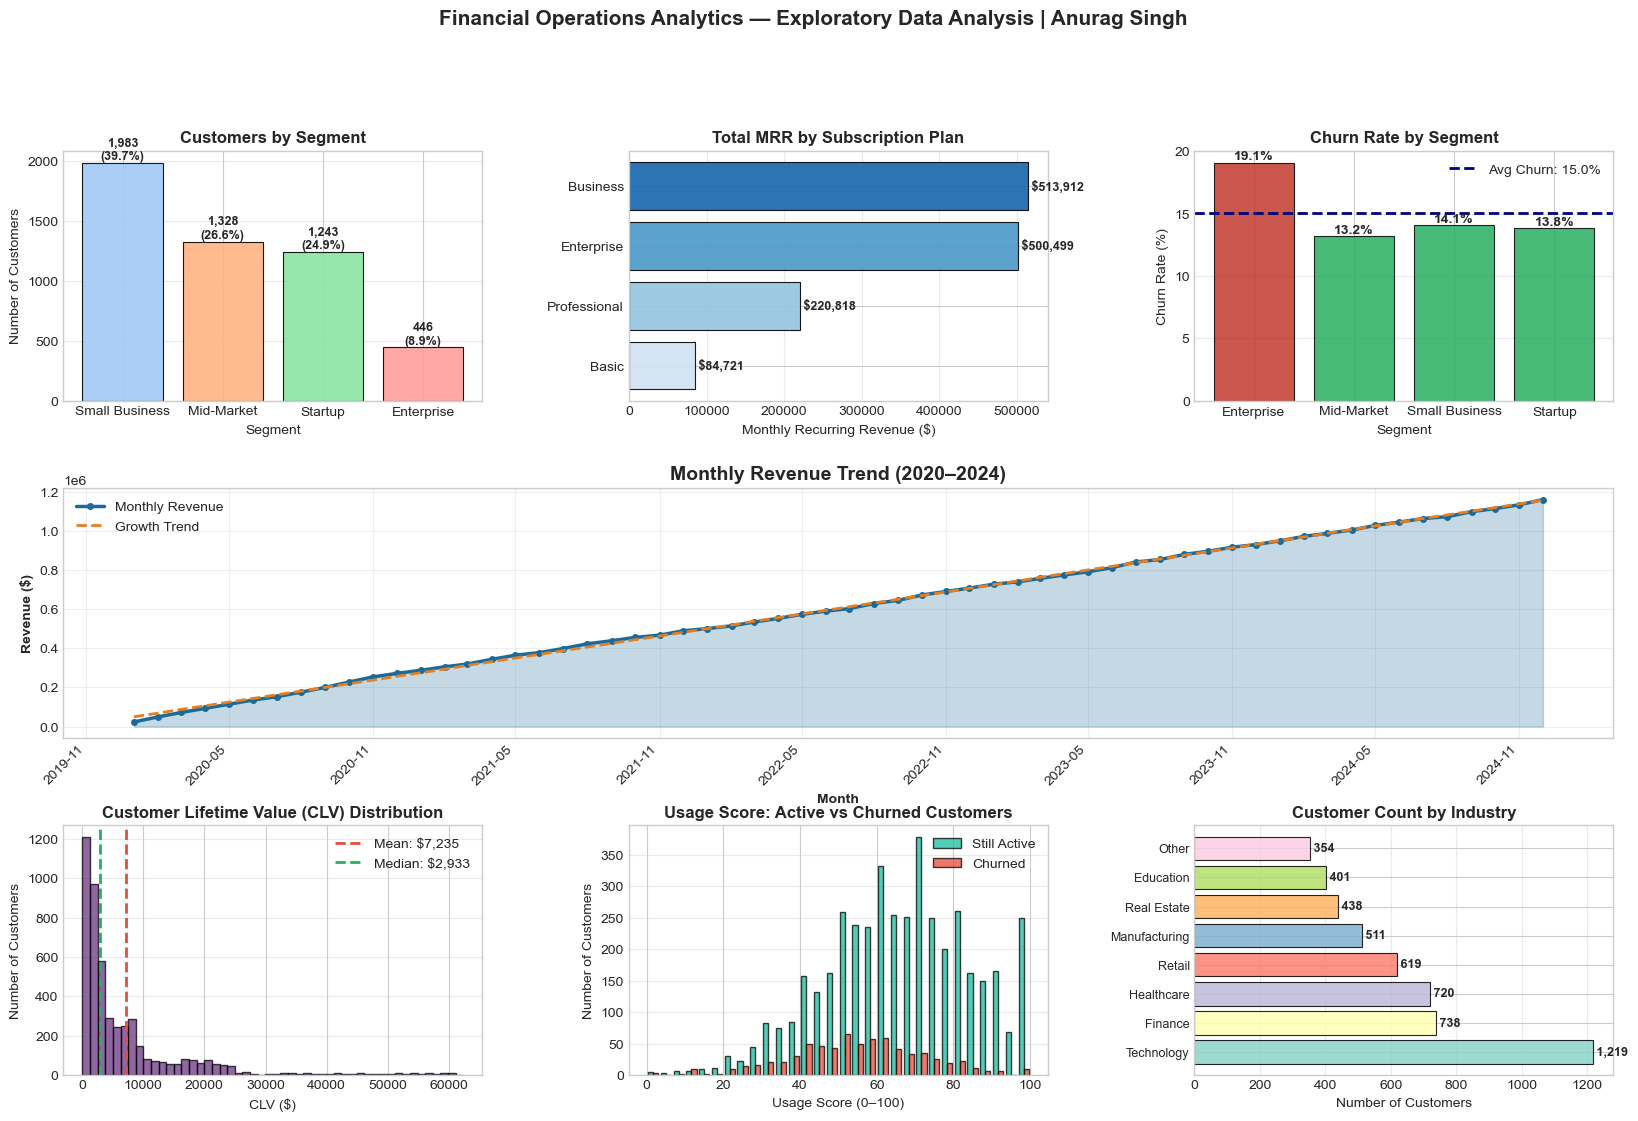


 Section 2 complete — data exploration done!



In [19]:
# ============================================================================
# SECTION 2: DATA UNDERSTANDING & EXPLORATORY ANALYSIS
# Developed by: Anurag Singh
# ============================================================================

print("=" * 70)
print("   SECTION 2: DATA UNDERSTANDING & EXPLORATION — Anurag Singh")
print("=" * 70)

# ─── Business Questions We're Trying to Answer ────────────────────────────

print("\n CORE BUSINESS QUESTIONS THIS ANALYSIS WILL ANSWER")
print("-" * 70)

my_business_questions = """
REVENUE FORECASTING
  Q1: What will our revenue look like over the next 12 months?
  Q2: Do we see seasonal spikes or dips in revenue?
  Q3: What are the main drivers of revenue growth?
  Q4: What is our month-over-month growth rate?

CHURN ANALYSIS
  Q5: Which customers are at risk of leaving in the next 3 months?
  Q6: What early warning signals predict churn?
  Q7: How much revenue are we losing to churn?
  Q8: Does churn rate differ across customer segments?

PROFITABILITY & COHORT ANALYSIS
  Q9: Which signup cohorts bring the most long-term value?
  Q10: What is our retention rate month by month?
  Q11: How does CLV differ across segments and plans?
  Q12: How long does it take to recover customer acquisition costs?

CUSTOMER SEGMENTATION
  Q13: Can we group customers into meaningful clusters?
  Q14: Which customer groups are the most profitable?
  Q15: How should we prioritize resources across segments?
"""

print(my_business_questions)

# =========================================================================
# 2.1: EXPLORING THE CUSTOMER DATASET
# =========================================================================

print("-" * 70)
print(" 2.1: CUSTOMER DATA EXPLORATION")
print("-" * 70)

print(f"\n Dataset size: {customer_df.shape[0]:,} rows × {customer_df.shape[1]} columns\n")

print(" First 5 customer records:")
print(customer_df.head())

print("\n\n Column Data Types:")
print(customer_df.dtypes)

print("\n\n Summary Statistics:")
print(customer_df.describe())

# Check for missing values — important before any modeling
print("\n\n Missing Value Check:")
missing_check = pd.DataFrame({
    'Column': customer_df.columns,
    'Missing Count': customer_df.isnull().sum(),
    'Missing %': (customer_df.isnull().sum() / len(customer_df) * 100).round(2)
})
missing_check = missing_check[missing_check['Missing Count'] > 0]

if len(missing_check) > 0:
    print(missing_check.to_string(index=False))
else:
    print("   No missing values found — data looks clean!")

# =========================================================================
# 2.2: EXPLORING THE TRANSACTION DATASET
# =========================================================================

print("\n\n" + "-" * 70)
print(" 2.2: TRANSACTION DATA EXPLORATION")
print("-" * 70)

print(f"\n Dataset size: {transaction_df.shape[0]:,} rows × {transaction_df.shape[1]} columns\n")

print(" First 5 transaction records:")
print(transaction_df.head())

# Key financial stats about transactions
print("\n\n Key Transaction Statistics:")
print(f"   Total Revenue Collected : ${transaction_df['amount'].sum():,.2f}")
print(f"   Average Transaction     : ${transaction_df['amount'].mean():.2f}")
print(f"   Median Transaction      : ${transaction_df['amount'].median():.2f}")
print(f"   Std Deviation           : ${transaction_df['amount'].std():.2f}")
print(f"   Smallest Transaction    : ${transaction_df['amount'].min():.2f}")
print(f"   Largest Transaction     : ${transaction_df['amount'].max():.2f}")

print("\n\n Transaction Type Breakdown:")
print(transaction_df['transaction_type'].value_counts())

print("\n\n Payment Method Breakdown:")
print(transaction_df['payment_method'].value_counts())

# =========================================================================
# 2.3: EXPLORING MONTHLY REVENUE DATA
# =========================================================================

print("\n\n" + "-" * 70)
print(" 2.3: MONTHLY REVENUE EXPLORATION")
print("-" * 70)

print(f"\n Dataset size: {revenue_by_month.shape[0]:,} rows × {revenue_by_month.shape[1]} columns\n")

print(" First 10 monthly periods:")
print(revenue_by_month.head(10))

print("\n\n Revenue Summary:")
print(f"   All-Time Total Revenue  : ${revenue_by_month['total_revenue'].sum():,.2f}")
print(f"   Average Monthly Revenue : ${revenue_by_month['total_revenue'].mean():,.2f}")
print(f"   Best Month Ever         : ${revenue_by_month['total_revenue'].max():,.2f}")
print(f"   Slowest Month Ever      : ${revenue_by_month['total_revenue'].min():,.2f}")
print(f"   Avg Month-over-Month Growth : {revenue_by_month['revenue_growth'].mean():.2f}%")

# ── Extra EDA Step (added by Anurag) ──────────────────────────────────────
# Checking which quarter typically performs best — useful for seasonality
print("\n\n Average Revenue by Quarter (Anurag's extra check):")
quarterly_avg = revenue_by_month.groupby('quarter')['total_revenue'].mean()
for q, rev in quarterly_avg.items():
    print(f"   Q{q}: ${rev:,.2f}")

# =========================================================================
# 2.4: INITIAL VISUALIZATIONS
# =========================================================================

print("\n\n" + "-" * 70)
print(" 2.4: EXPLORATORY VISUALIZATIONS")
print("-" * 70)

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)

# ── Chart 1: Customer Segment Distribution ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
seg_counts = customer_df['segment'].value_counts()
bar_colors1 = sns.color_palette("pastel", len(seg_counts))  # Changed: pastel palette
ax1.bar(seg_counts.index, seg_counts.values, color=bar_colors1, alpha=0.9, edgecolor='black', linewidth=0.8)
ax1.set_title('Customers by Segment', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('Segment')
for i, v in enumerate(seg_counts.values):
    ax1.text(i, v, f'{v:,}\n({v/len(customer_df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.grid(axis='y', alpha=0.4)

# ── Chart 2: Total MRR by Plan ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
plan_mrr = customer_df.groupby('plan')['mrr'].sum().sort_values(ascending=True)
bar_colors2 = sns.color_palette("Blues", len(plan_mrr))  # Changed: Blues palette
ax2.barh(plan_mrr.index, plan_mrr.values, color=bar_colors2, alpha=0.9, edgecolor='black', linewidth=0.8)
ax2.set_title('Total MRR by Subscription Plan', fontweight='bold', fontsize=12)
ax2.set_xlabel('Monthly Recurring Revenue ($)')
for i, v in enumerate(plan_mrr.values):
    ax2.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=9)
ax2.grid(axis='x', alpha=0.4)

# ── Chart 3: Churn Rate by Segment ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
churn_seg = customer_df.groupby('segment')['is_churned'].mean() * 100
avg_churn = churn_seg.mean()
# Red if above average churn, green if below — clear visual signal
seg_colors = ['#c0392b' if x > avg_churn else '#27ae60' for x in churn_seg.values]
ax3.bar(churn_seg.index, churn_seg.values, color=seg_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax3.set_title('Churn Rate by Segment', fontweight='bold', fontsize=12)
ax3.set_ylabel('Churn Rate (%)')
ax3.set_xlabel('Segment')
ax3.axhline(y=avg_churn, color='navy', linestyle='--',
            label=f'Avg Churn: {avg_churn:.1f}%', linewidth=2)
for i, v in enumerate(churn_seg.values):
    ax3.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.4)

# ── Chart 4: Revenue Trend Over Time ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(revenue_by_month['year_month'], revenue_by_month['total_revenue'],
         linewidth=2.5, color='#1a6b9a', marker='o', markersize=4, label='Monthly Revenue')  # Changed color
ax4.fill_between(revenue_by_month['year_month'], revenue_by_month['total_revenue'],
                 alpha=0.25, color='#1a6b9a')
ax4.set_title('Monthly Revenue Trend (2020–2024)', fontweight='bold', fontsize=14)
ax4.set_xlabel('Month', fontweight='bold')
ax4.set_ylabel('Revenue ($)', fontweight='bold')
ax4.grid(True, alpha=0.3)

# Add a trend line to see direction
trend_coeffs = np.polyfit(range(len(revenue_by_month)), revenue_by_month['total_revenue'], 1)
trend_line = np.poly1d(trend_coeffs)
ax4.plot(revenue_by_month['year_month'], trend_line(range(len(revenue_by_month))),
         color='#e67e22', linestyle='--', linewidth=2, label='Growth Trend')  # Changed: orange trend
ax4.legend()
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Chart 5: CLV Distribution ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(customer_df['clv'], bins=50, color='#6c3483', alpha=0.75, edgecolor='black')  # Changed: deeper purple
ax5.axvline(customer_df['clv'].mean(), color='#e74c3c', linestyle='--',
            linewidth=2, label=f'Mean: ${customer_df["clv"].mean():,.0f}')
ax5.axvline(customer_df['clv'].median(), color='#27ae60', linestyle='--',
            linewidth=2, label=f'Median: ${customer_df["clv"].median():,.0f}')
ax5.set_title('Customer Lifetime Value (CLV) Distribution', fontweight='bold', fontsize=12)
ax5.set_xlabel('CLV ($)')
ax5.set_ylabel('Number of Customers')
ax5.legend()
ax5.grid(axis='y', alpha=0.4)

# ── Chart 6: Usage Score — Active vs Churned ─────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
active_scores = customer_df[customer_df['is_churned'] == 0]['usage_score']
churned_scores = customer_df[customer_df['is_churned'] == 1]['usage_score']
ax6.hist([active_scores, churned_scores], bins=30,
         label=['Still Active', 'Churned'],
         color=['#1abc9c', '#e74c3c'],  # Changed: teal vs red
         alpha=0.75, edgecolor='black')
ax6.set_title('Usage Score: Active vs Churned Customers', fontweight='bold', fontsize=12)
ax6.set_xlabel('Usage Score (0–100)')
ax6.set_ylabel('Number of Customers')
ax6.legend()
ax6.grid(axis='y', alpha=0.4)

# ── Chart 7: Top Industries ───────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
industry_breakdown = customer_df['industry'].value_counts().head(8)
bar_colors7 = sns.color_palette("Set3", len(industry_breakdown))  # Changed: Set3 palette
ax7.barh(range(len(industry_breakdown)), industry_breakdown.values,
         color=bar_colors7, alpha=0.85, edgecolor='black', linewidth=0.8)
ax7.set_yticks(range(len(industry_breakdown)))
ax7.set_yticklabels(industry_breakdown.index, fontsize=9)
ax7.set_title('Customer Count by Industry', fontweight='bold', fontsize=12)
ax7.set_xlabel('Number of Customers')
for i, v in enumerate(industry_breakdown.values):
    ax7.text(v, i, f' {v:,}', va='center', fontweight='bold', fontsize=9)
ax7.grid(axis='x', alpha=0.4)

# ── Overall Figure Title ──────────────────────────────────────────────────
plt.suptitle('Financial Operations Analytics — Exploratory Data Analysis | Anurag Singh',
             fontsize=15, fontweight='bold', y=0.998)

plt.savefig(f'{viz_folder}/01_eda_exploration.png', dpi=300, bbox_inches='tight')
print(f" Saved: {viz_folder}/01_eda_exploration.png")
plt.show()

print("\n Section 2 complete — data exploration done!\n")


   SECTION 3: REVENUE FORECASTING — Anurag Singh

Why do we forecast revenue?
  - To predict how much money the business will make in coming months
  - To spot seasonal patterns (e.g. which months are always slow/busy)
  - To help management plan budgets and set realistic targets
  - To detect if growth is slowing down before it becomes a crisis

Techniques I'll use in this section:
  1. Time series decomposition (break revenue into trend + season + noise)
  2. Stationarity testing (check if data is ready for ARIMA)
  3. ACF/PACF plots (choose the right ARIMA parameters)
  4. ARIMA model (train, validate, and forecast)
  5. Facebook Prophet (if installed — handles seasonality automatically)

----------------------------------------------------------------------
 3.1: TIME SERIES DATA PREPARATION
----------------------------------------------------------------------

 Time Series Overview:
   Start Date      : 2020-01-01 00:00:00
   End Date        : 2024-12-01 00:00:00
   Total Period

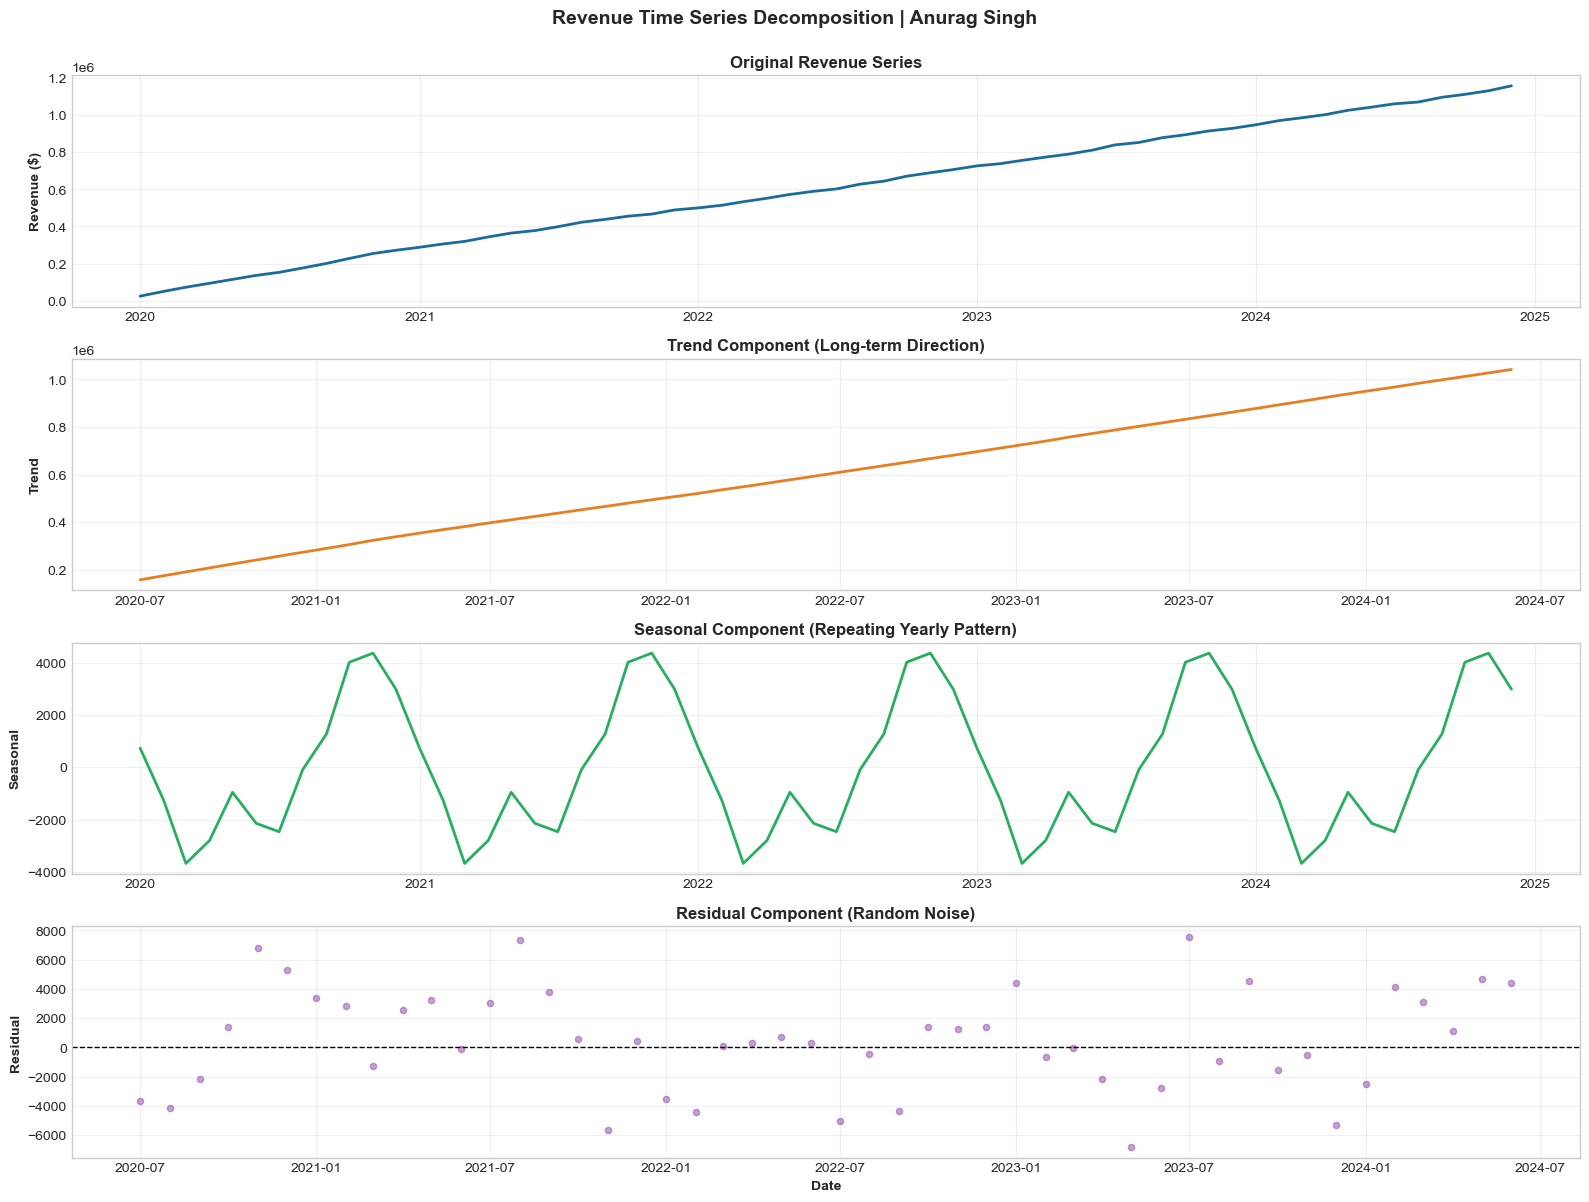


 Decomposition Insights:
   Seasonal Strength : 0.353  (0 = no pattern, 1 = perfect pattern)
   Trend Strength    : 1.000
   → Mild seasonality — standard ARIMA should work fine

----------------------------------------------------------------------
 3.3: STATIONARITY TEST (Augmented Dickey-Fuller)
----------------------------------------------------------------------

Before running ARIMA, the data must be 'stationary' — meaning:
  - The average revenue doesn't keep rising/falling over time
  - The ups and downs stay roughly the same size throughout

ADF Test Logic:
  - If p-value < 0.05 → Data IS stationary (ready for ARIMA)
  - If p-value ≥ 0.05 → Data is NOT stationary (we need to difference it)

 ADF Test Results:
   ADF Statistic : -1.1702
   P-value       : 0.6863
   Critical Values:
      1%: -3.5485
      5%: -2.9128
      10%: -2.5941

   Data is non-stationary — applying differencing...

   After differencing:
   ADF Statistic : -8.6683
   P-value       : 0.0000
   Differen

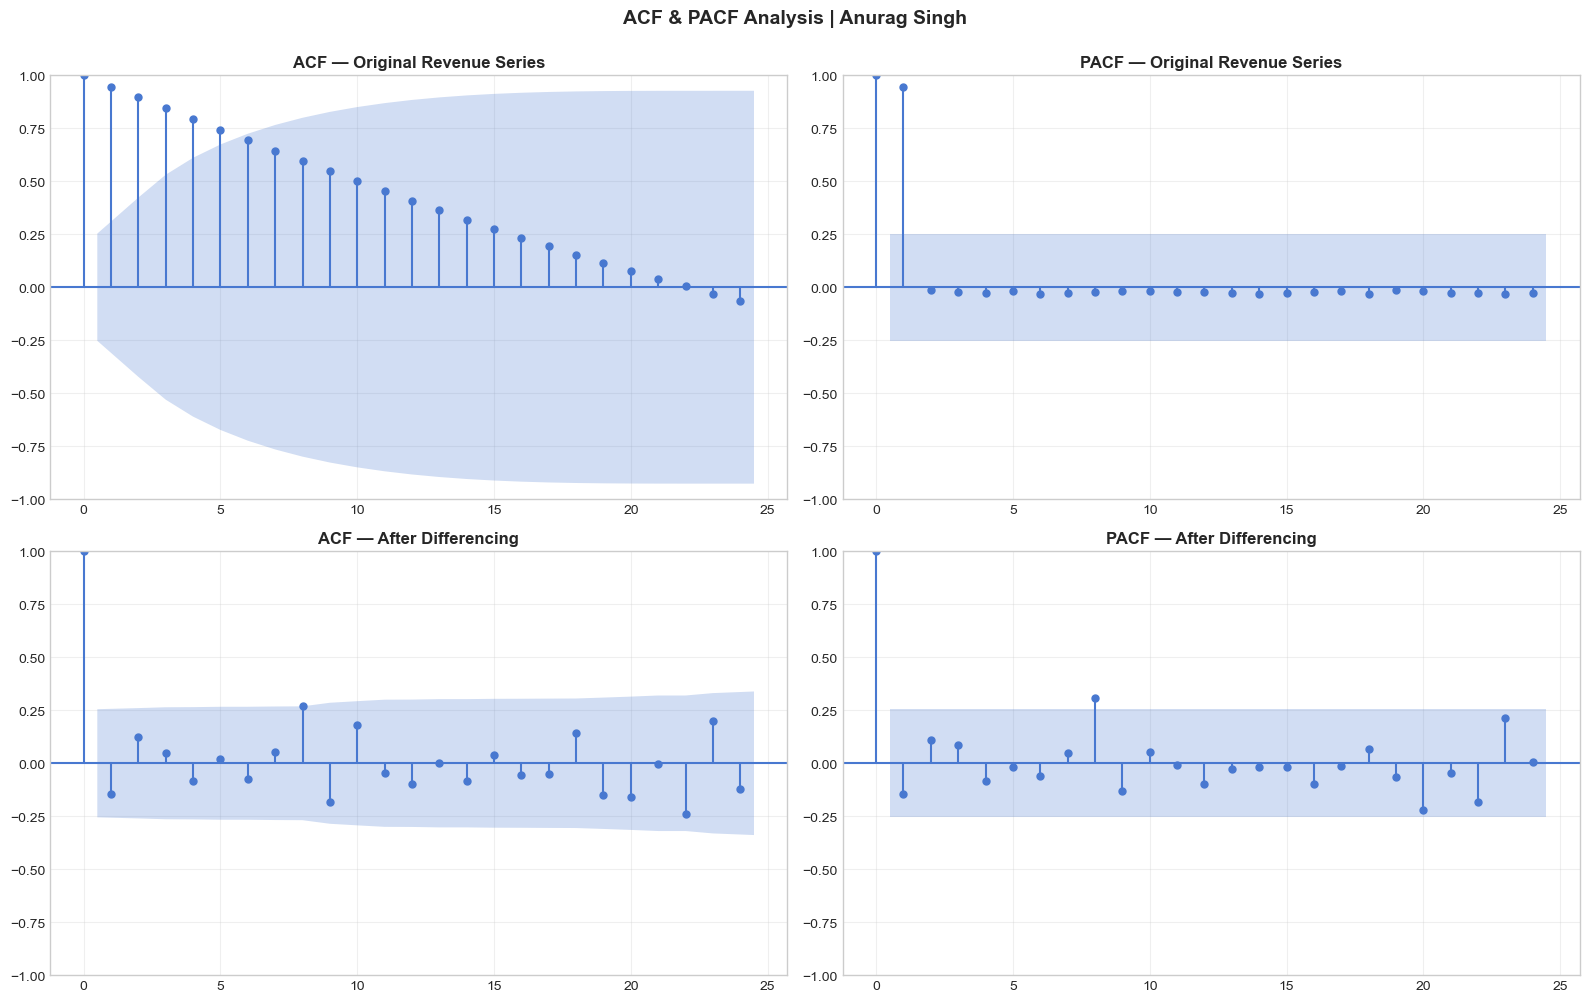


----------------------------------------------------------------------
 3.5: ARIMA MODEL TRAINING
----------------------------------------------------------------------

ARIMA(p, d, q) Parameters:
  p → How many past revenue values to use for prediction (from PACF)
  d → How many times we differenced the data (from stationarity test)
  q → How many past forecast errors to include (from ACF)

We test all combinations and pick the one with the lowest AIC score.
Lower AIC = better model fit with less complexity.

 Data Split:
   Training : 48 months (2020-01-01 → 2023-12-01)
   Testing  : 12 months (2024-01-01 → 2024-12-01)

 Testing ARIMA parameter combinations...
   ARIMA(0,0,0) → AIC: 1476.20
   ARIMA(0,0,1) → AIC: 1301.28
   ARIMA(0,0,2) → AIC: 1288.95
   ARIMA(0,1,0) → AIC: 1065.43
   ARIMA(0,1,1) → AIC: 1040.58
   ARIMA(0,1,2) → AIC: 1005.89
   ARIMA(1,0,0) → AIC: 1098.27
   ARIMA(1,0,1) → AIC: 1063.95


C:\Users\Anurag\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   ARIMA(1,0,2) → AIC: 1045.24
   ARIMA(1,1,0) → AIC: 963.52
   ARIMA(1,1,1) → AIC: 935.09
   ARIMA(1,1,2) → AIC: 936.40
   ARIMA(2,0,0) → AIC: 1000.14


C:\Users\Anurag\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   ARIMA(2,0,1) → AIC: 975.15
   ARIMA(2,0,2) → AIC: 976.61
   ARIMA(2,1,0) → AIC: 943.76
   ARIMA(2,1,1) → AIC: 936.16
   ARIMA(2,1,2) → AIC: 937.76

 Best Model Found: ARIMA(1, 1, 1) with AIC = 935.09

----------------------------------------------------------------------
 MODEL SUMMARY
----------------------------------------------------------------------
                               SARIMAX Results                                
Dep. Variable:          total_revenue   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -464.543
Date:                Mon, 23 Feb 2026   AIC                            935.086
Time:                        15:42:53   BIC                            940.636
Sample:                    01-01-2020   HQIC                           937.174
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
       

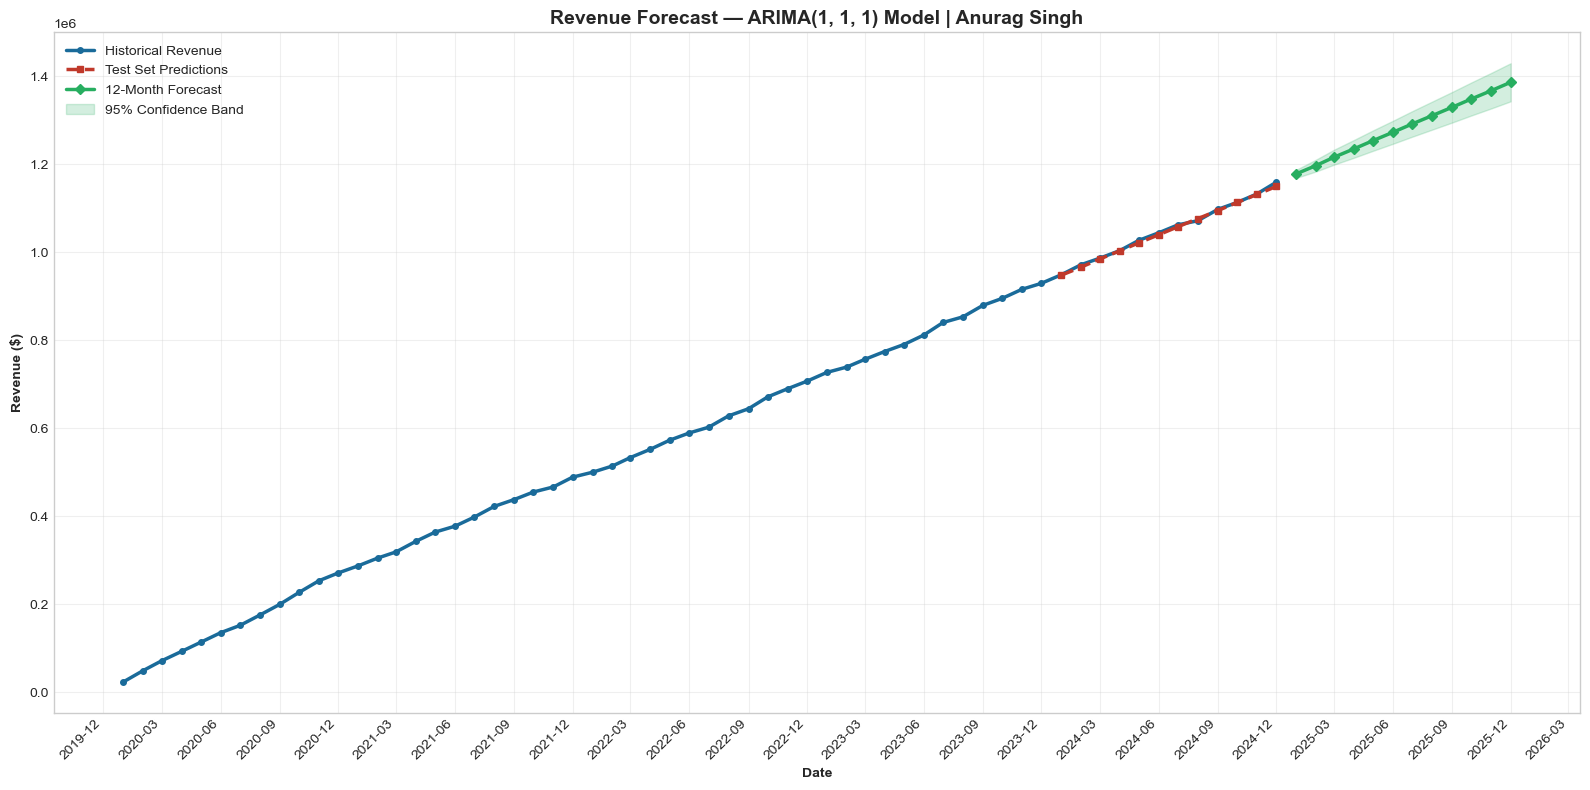


----------------------------------------------------------------------
 3.7: FACEBOOK PROPHET FORECASTING
----------------------------------------------------------------------

Prophet is great for business data because:
  - It handles missing months and outliers automatically
  - It detects yearly AND weekly patterns on its own
  - It lets you add holidays as special events
  - The output is easy to interpret (trend + seasonality shown separately)
    
 Training Prophet model...


15:43:01 - cmdstanpy - INFO - Chain [1] start processing
15:43:03 - cmdstanpy - INFO - Chain [1] done processing


 Prophet model trained!

 Prophet 12-Month Forecast:

  Month  Forecasted Revenue  Lower Bound  Upper Bound
2025-01          1169525.92   1166461.43   1172496.73
2025-02          1182986.11   1179456.75   1186365.28
2025-03          1203504.33   1199746.22   1207036.03
2025-04          1222501.84   1217968.74   1226820.44
2025-05          1242092.86   1236610.99   1246837.48
2025-06          1258937.87   1251779.31   1265307.61
2025-07          1276676.20   1268640.10   1284035.30
2025-08          1294344.55   1284821.88   1303026.26
2025-09          1315078.44   1303753.40   1325566.45
2025-10          1334835.55   1321556.24   1347777.85
2025-11          1353485.23   1338650.06   1367330.35
2025-12          1372849.62   1355685.02   1389135.82

 Saved: anurag_viz/05_prophet_forecast.png


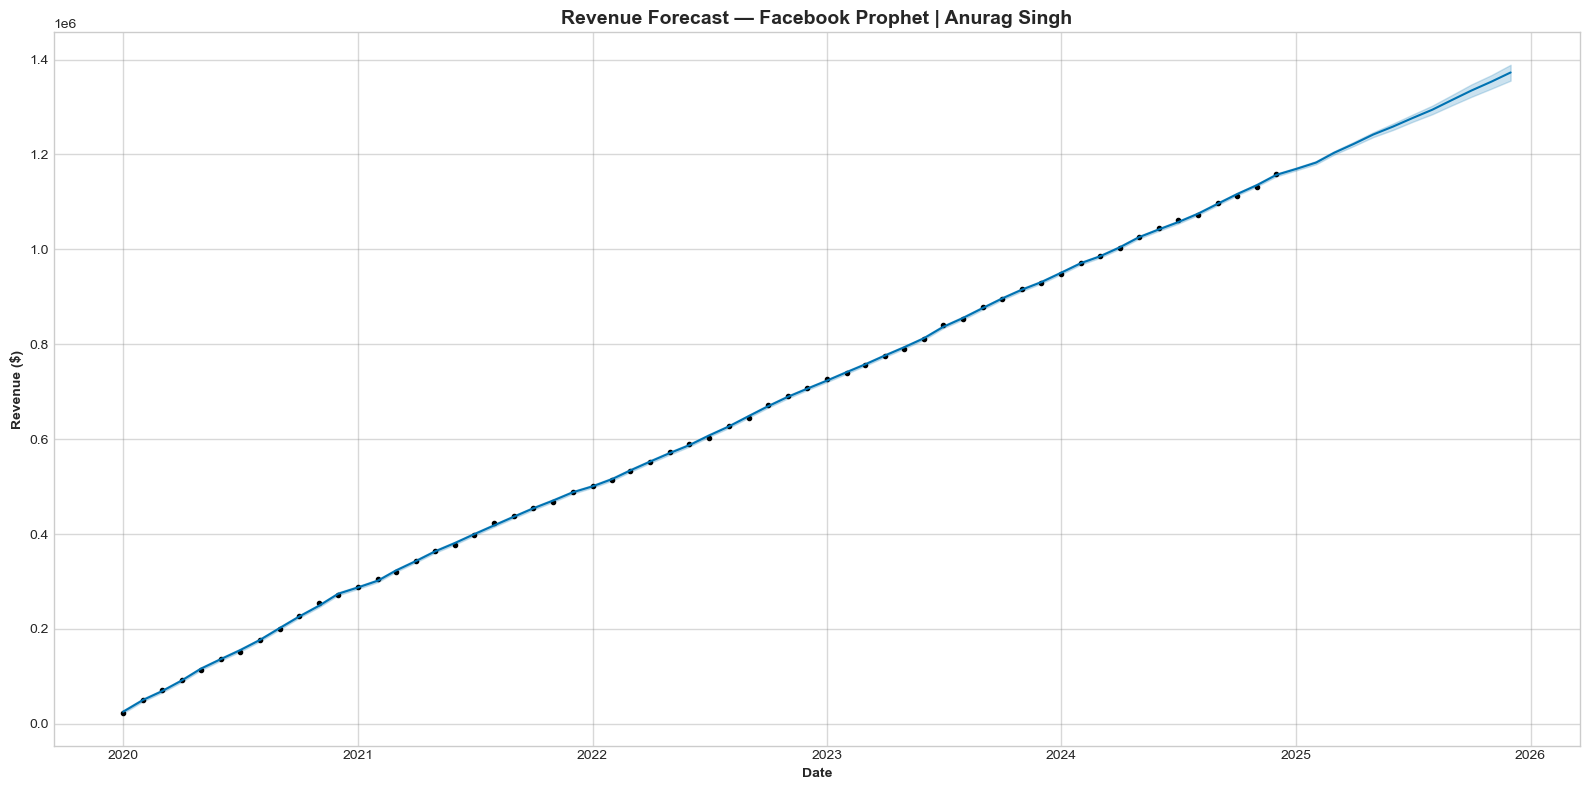

 Saved: anurag_viz/06_prophet_components.png


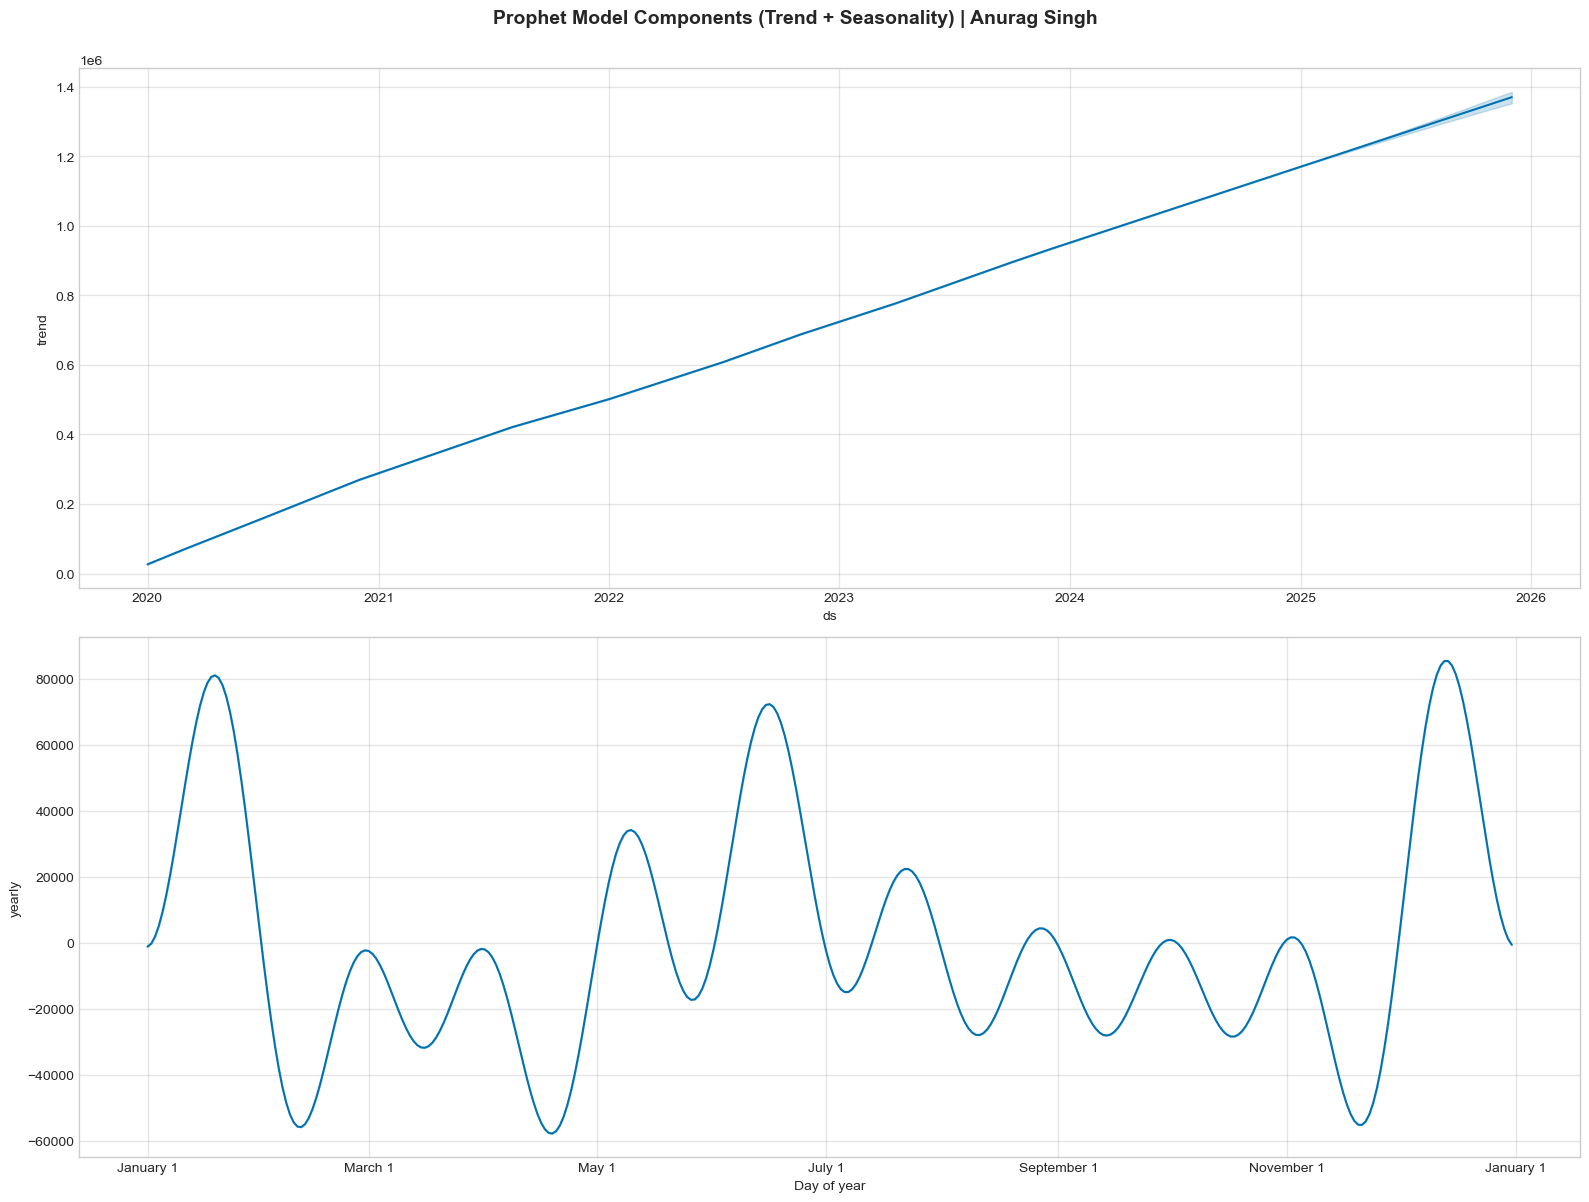


 Section 3 Complete — Revenue Forecasting Done!



In [7]:
# ============================================================================
# SECTION 3: REVENUE FORECASTING — TIME SERIES ANALYSIS
# Developed by: Anurag Singh
# ============================================================================

print("\n" + "=" * 70)
print("   SECTION 3: REVENUE FORECASTING — Anurag Singh")
print("=" * 70)

print("""
Why do we forecast revenue?
  - To predict how much money the business will make in coming months
  - To spot seasonal patterns (e.g. which months are always slow/busy)
  - To help management plan budgets and set realistic targets
  - To detect if growth is slowing down before it becomes a crisis

Techniques I'll use in this section:
  1. Time series decomposition (break revenue into trend + season + noise)
  2. Stationarity testing (check if data is ready for ARIMA)
  3. ACF/PACF plots (choose the right ARIMA parameters)
  4. ARIMA model (train, validate, and forecast)
  5. Facebook Prophet (if installed — handles seasonality automatically)
""")

# =========================================================================
# 3.1: PREPARE THE TIME SERIES
# =========================================================================

print("-" * 70)
print(" 3.1: TIME SERIES DATA PREPARATION")
print("-" * 70)

# Extract just the date and revenue columns — that's all we need for forecasting
revenue_ts = revenue_by_month[['year_month', 'total_revenue']].copy()
revenue_ts.set_index('year_month', inplace=True)
revenue_ts.index.freq = 'MS'  # Tell pandas this is monthly (Month Start) data

print(f"\n Time Series Overview:")
print(f"   Start Date      : {revenue_ts.index.min()}")
print(f"   End Date        : {revenue_ts.index.max()}")
print(f"   Total Periods   : {len(revenue_ts)} months")
print(f"   Frequency       : Monthly")

# Check if any months are missing in the sequence
full_date_range = pd.date_range(
    start=revenue_ts.index.min(),
    end=revenue_ts.index.max(),
    freq='MS'
)
missing_months = full_date_range.difference(revenue_ts.index)

if len(missing_months) > 0:
    print(f"   ⚠ Missing months found: {len(missing_months)}")
else:
    print(f"   No missing months — sequence is complete!")

# =========================================================================
# 3.2: TIME SERIES DECOMPOSITION
# =========================================================================

print("\n" + "-" * 70)
print(" 3.2: TIME SERIES DECOMPOSITION")
print("-" * 70)

print("""
Decomposition splits revenue into 3 parts:
  Trend     → Is revenue going up or down long-term?
  Seasonal  → Does the same pattern repeat every year?
  Residual  → What's left after removing trend and seasonality (random noise)
""")

# Decompose using additive model — suitable when seasonal swings stay roughly the same
revenue_decomp = seasonal_decompose(
    revenue_ts['total_revenue'],
    model='additive',
    period=12  # 12 = monthly data with yearly seasonality
)

# Plot all 4 components
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

axes[0].plot(revenue_ts.index, revenue_ts['total_revenue'],
             linewidth=2, color='#1a6b9a')  # Deep blue — matches our theme
axes[0].set_ylabel('Revenue ($)', fontweight='bold')
axes[0].set_title('Original Revenue Series', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(revenue_decomp.trend.index, revenue_decomp.trend,
             linewidth=2, color='#e67e22')  # Orange for trend
axes[1].set_ylabel('Trend', fontweight='bold')
axes[1].set_title('Trend Component (Long-term Direction)', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(revenue_decomp.seasonal.index, revenue_decomp.seasonal,
             linewidth=2, color='#27ae60')  # Green for seasonality
axes[2].set_ylabel('Seasonal', fontweight='bold')
axes[2].set_title('Seasonal Component (Repeating Yearly Pattern)', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3)

axes[3].scatter(revenue_decomp.resid.index, revenue_decomp.resid,
                alpha=0.5, color='#8e44ad', s=20)  # Purple dots for residuals
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residual', fontweight='bold')
axes[3].set_xlabel('Date', fontweight='bold')
axes[3].set_title('Residual Component (Random Noise)', fontweight='bold', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.suptitle('Revenue Time Series Decomposition | Anurag Singh',
             fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/02_ts_decomposition.png', dpi=300, bbox_inches='tight')
print(f" Saved: {viz_folder}/02_ts_decomposition.png")
plt.show()

# Measure how strong the trend and seasonality actually are
seasonal_strength = 1 - (
    revenue_decomp.resid.var() /
    (revenue_decomp.seasonal + revenue_decomp.resid).var()
)
trend_strength = 1 - (
    revenue_decomp.resid.var() /
    (revenue_decomp.trend + revenue_decomp.resid).var()
)

print(f"\n Decomposition Insights:")
print(f"   Seasonal Strength : {seasonal_strength:.3f}  (0 = no pattern, 1 = perfect pattern)")
print(f"   Trend Strength    : {trend_strength:.3f}")
if seasonal_strength > 0.6:
    print(f"   → Strong seasonality detected — SARIMA would be ideal")
else:
    print(f"   → Mild seasonality — standard ARIMA should work fine")

# =========================================================================
# 3.3: STATIONARITY TEST
# =========================================================================

print("\n" + "-" * 70)
print(" 3.3: STATIONARITY TEST (Augmented Dickey-Fuller)")
print("-" * 70)

print("""
Before running ARIMA, the data must be 'stationary' — meaning:
  - The average revenue doesn't keep rising/falling over time
  - The ups and downs stay roughly the same size throughout

ADF Test Logic:
  - If p-value < 0.05 → Data IS stationary (ready for ARIMA)
  - If p-value ≥ 0.05 → Data is NOT stationary (we need to difference it)
""")

adf_test = adfuller(revenue_ts['total_revenue'].dropna())

print(f" ADF Test Results:")
print(f"   ADF Statistic : {adf_test[0]:.4f}")
print(f"   P-value       : {adf_test[1]:.4f}")
print(f"   Critical Values:")
for level, val in adf_test[4].items():
    print(f"      {level}: {val:.4f}")

if adf_test[1] < 0.05:
    print(f"\n   Data is stationary — no differencing needed!")
    differencing_needed = False
else:
    print(f"\n   Data is non-stationary — applying differencing...")
    differencing_needed = True

# Apply differencing if needed (subtract each value from the previous one)
if differencing_needed:
    revenue_ts['revenue_diff'] = revenue_ts['total_revenue'].diff()
    adf_diff = adfuller(revenue_ts['revenue_diff'].dropna())
    print(f"\n   After differencing:")
    print(f"   ADF Statistic : {adf_diff[0]:.4f}")
    print(f"   P-value       : {adf_diff[1]:.4f}")
    if adf_diff[1] < 0.05:
        print(f"   Differenced series is now stationary!")

# =========================================================================
# 3.4: ACF AND PACF PLOTS
# =========================================================================

print("\n" + "-" * 70)
print(" 3.4: ACF & PACF ANALYSIS")
print("-" * 70)

print("""
These plots help us pick ARIMA parameters:
  ACF  → Shows how correlated revenue is with its own past values
         → Helps choose 'q' (MA order)
  PACF → Shows direct correlation at each lag (removing indirect effects)
         → Helps choose 'p' (AR order)
""")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF on original series
plot_acf(revenue_ts['total_revenue'].dropna(), lags=24, ax=axes[0, 0])
axes[0, 0].set_title('ACF — Original Revenue Series', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# PACF on original series
plot_pacf(revenue_ts['total_revenue'].dropna(), lags=24, ax=axes[0, 1])
axes[0, 1].set_title('PACF — Original Revenue Series', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

if differencing_needed:
    plot_acf(revenue_ts['revenue_diff'].dropna(), lags=24, ax=axes[1, 0])
    axes[1, 0].set_title('ACF — After Differencing', fontweight='bold', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    plot_pacf(revenue_ts['revenue_diff'].dropna(), lags=24, ax=axes[1, 1])
    axes[1, 1].set_title('PACF — After Differencing', fontweight='bold', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)
else:
    # Show monthly average revenue — good extra insight
    monthly_avg = [revenue_ts[revenue_ts.index.month == m]['total_revenue'].mean()
                   for m in range(1, 13)]
    axes[1, 0].plot(range(1, 13), monthly_avg,
                    marker='o', linewidth=2, markersize=8, color='#e67e22')
    axes[1, 0].set_title('Average Revenue by Month (Seasonality Check)', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Month Number')
    axes[1, 0].set_ylabel('Avg Revenue ($)')
    axes[1, 0].set_xticks(range(1, 13))
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].boxplot([revenue_ts[revenue_ts.index.month == m]['total_revenue']
                        for m in range(1, 13)])
    axes[1, 1].set_title('Revenue Spread by Month', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Month Number')
    axes[1, 1].set_ylabel('Revenue ($)')
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('ACF & PACF Analysis | Anurag Singh', fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/03_acf_pacf.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/03_acf_pacf.png")
plt.show()

# =========================================================================
# 3.5: ARIMA MODEL TRAINING
# =========================================================================

print("\n" + "-" * 70)
print(" 3.5: ARIMA MODEL TRAINING")
print("-" * 70)

print("""
ARIMA(p, d, q) Parameters:
  p → How many past revenue values to use for prediction (from PACF)
  d → How many times we differenced the data (from stationarity test)
  q → How many past forecast errors to include (from ACF)

We test all combinations and pick the one with the lowest AIC score.
Lower AIC = better model fit with less complexity.
""")

# 80% train, 20% test split
split_point = int(len(revenue_ts) * 0.8)
ts_train = revenue_ts['total_revenue'][:split_point]
ts_test = revenue_ts['total_revenue'][split_point:]

print(f" Data Split:")
print(f"   Training : {len(ts_train)} months ({ts_train.index.min().date()} → {ts_train.index.max().date()})")
print(f"   Testing  : {len(ts_test)} months ({ts_test.index.min().date()} → {ts_test.index.max().date()})")

print("\n Testing ARIMA parameter combinations...")

top_aic = np.inf
top_params = None
top_model = None
param_results = []

for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                trial_model = ARIMA(ts_train, order=(p, d, q))
                trial_fit = trial_model.fit()
                current_aic = trial_fit.aic
                param_results.append({'p': p, 'd': d, 'q': q, 'AIC': current_aic})

                if current_aic < top_aic:
                    top_aic = current_aic
                    top_params = (p, d, q)
                    top_model = trial_fit

                print(f"   ARIMA({p},{d},{q}) → AIC: {current_aic:.2f}")
            except Exception as err:
                print(f"   ARIMA({p},{d},{q}) → Could not fit: {str(err)[:50]}")
                continue

print(f"\n Best Model Found: ARIMA{top_params} with AIC = {top_aic:.2f}")

print("\n" + "-" * 70)
print(" MODEL SUMMARY")
print("-" * 70)
print(top_model.summary())

# Test set predictions
test_predictions = top_model.forecast(steps=len(ts_test))

# Performance metrics
mae_score  = mean_absolute_error(ts_test, test_predictions)
rmse_score = np.sqrt(mean_squared_error(ts_test, test_predictions))
mape_score = np.mean(np.abs((ts_test - test_predictions) / ts_test)) * 100

print("\n" + "-" * 70)
print(" MODEL PERFORMANCE ON TEST DATA")
print("-" * 70)
print(f"   MAE  (avg error in $)          : ${mae_score:,.2f}")
print(f"   RMSE (penalizes big errors)    : ${rmse_score:,.2f}")
print(f"   MAPE (% error on average)      : {mape_score:.2f}%")

# =========================================================================
# 3.6: 12-MONTH REVENUE FORECAST
# =========================================================================

print("\n" + "-" * 70)
print(" 3.6: FORECASTING THE NEXT 12 MONTHS")
print("-" * 70)

# Refit on ALL available data for the strongest possible forecast
full_arima = ARIMA(revenue_ts['total_revenue'], order=top_params)
full_arima_fit = full_arima.fit()

forecast_horizon = 12
arima_forecast_obj = full_arima_fit.get_forecast(steps=forecast_horizon)
arima_forecast_vals = arima_forecast_obj.predicted_mean
arima_conf_int = arima_forecast_obj.conf_int()

# Build forecast date index
forecast_dates = pd.date_range(
    start=revenue_ts.index.max() + pd.DateOffset(months=1),
    periods=forecast_horizon,
    freq='MS'
)

# Print the forecast table
print(f"\n 12-Month Revenue Forecast (ARIMA{top_params}):\n")
forecast_table = pd.DataFrame({
    'Month': forecast_dates.strftime('%Y-%m'),
    'Forecasted Revenue': arima_forecast_vals.values,
    'Lower Bound (95%)': arima_conf_int.iloc[:, 0].values,
    'Upper Bound (95%)': arima_conf_int.iloc[:, 1].values
})
print(forecast_table.to_string(index=False))

print(f"\n Forecast Summary:")
print(f"   Total Revenue Next 12 Months : ${arima_forecast_vals.sum():,.2f}")
print(f"   Average Monthly Forecast     : ${arima_forecast_vals.mean():,.2f}")
print(f"   Expected Change vs Last Month: ${(arima_forecast_vals.iloc[0] - revenue_ts['total_revenue'].iloc[-1]):,.2f}")

# Plot the forecast
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(revenue_ts.index, revenue_ts['total_revenue'],
        linewidth=2.5, color='#1a6b9a', marker='o', markersize=4, label='Historical Revenue')

ax.plot(ts_test.index, test_predictions,
        linewidth=2.5, color='#c0392b', linestyle='--', marker='s', markersize=4,
        label='Test Set Predictions')

ax.plot(forecast_dates, arima_forecast_vals,
        linewidth=2.5, color='#27ae60', marker='D', markersize=5, label='12-Month Forecast')

ax.fill_between(forecast_dates,
                arima_conf_int.iloc[:, 0],
                arima_conf_int.iloc[:, 1],
                color='#27ae60', alpha=0.2, label='95% Confidence Band')

ax.set_title(f'Revenue Forecast — ARIMA{top_params} Model | Anurag Singh',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Revenue ($)', fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{viz_folder}/04_arima_forecast.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/04_arima_forecast.png")
plt.show()

# =========================================================================
# 3.7: FACEBOOK PROPHET MODEL
# =========================================================================

if PROPHET_AVAILABLE:
    print("\n" + "-" * 70)
    print(" 3.7: FACEBOOK PROPHET FORECASTING")
    print("-" * 70)

    print("""
Prophet is great for business data because:
  - It handles missing months and outliers automatically
  - It detects yearly AND weekly patterns on its own
  - It lets you add holidays as special events
  - The output is easy to interpret (trend + seasonality shown separately)
    """)

    # Prophet needs columns named exactly 'ds' (date) and 'y' (value)
    prophet_input = pd.DataFrame({
        'ds': revenue_ts.index,
        'y': revenue_ts['total_revenue'].values
    })

    print(" Training Prophet model...")
    prophet_mdl = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # We have monthly data, not daily
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.08  # Slightly more flexible than default 0.05
    )

    prophet_mdl.fit(prophet_input)
    print(" Prophet model trained!")

    # Create future dates to forecast into
    future_dates = prophet_mdl.make_future_dataframe(periods=12, freq='MS')
    prophet_pred = prophet_mdl.predict(future_dates)

    # Last 12 rows = the forecast period
    prophet_forecast_12 = prophet_pred.tail(12)

    print(f"\n Prophet 12-Month Forecast:\n")
    prophet_table = pd.DataFrame({
        'Month': prophet_forecast_12['ds'].dt.strftime('%Y-%m'),
        'Forecasted Revenue': prophet_forecast_12['yhat'].values,
        'Lower Bound': prophet_forecast_12['yhat_lower'].values,
        'Upper Bound': prophet_forecast_12['yhat_upper'].values
    })
    print(prophet_table.to_string(index=False))

    # Prophet's built-in forecast plot
    fig = prophet_mdl.plot(prophet_pred, figsize=(16, 8))
    ax = fig.gca()
    ax.set_title('Revenue Forecast — Facebook Prophet | Anurag Singh',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontweight='bold')
    ax.set_ylabel('Revenue ($)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{viz_folder}/05_prophet_forecast.png', dpi=300, bbox_inches='tight')
    print(f"\n Saved: {viz_folder}/05_prophet_forecast.png")
    plt.show()

    # Component breakdown — trend vs seasonality
    fig = prophet_mdl.plot_components(prophet_pred, figsize=(16, 12))
    plt.suptitle('Prophet Model Components (Trend + Seasonality) | Anurag Singh',
                 fontsize=14, fontweight='bold', y=0.998)
    plt.tight_layout()
    plt.savefig(f'{viz_folder}/06_prophet_components.png', dpi=300, bbox_inches='tight')
    print(f" Saved: {viz_folder}/06_prophet_components.png")
    plt.show()

else:
    print("\n Prophet not installed — skipping this section.")
    print(" To install: pip install prophet")

print("\n Section 3 Complete — Revenue Forecasting Done!")
print("=" * 70 + "\n")


   SECTION 4: CUSTOMER CHURN ANALYSIS — Anurag Singh

What is churn and why does it matter?
  Churn = customers who stop paying and leave the business.
  Even a 5% monthly churn can destroy a SaaS company over time.

In this section I will:
  1. Measure churn rates across segments, plans, and industries
  2. Calculate the financial damage churn is causing
  3. Build ML models to predict WHICH customers will churn next
  4. Rank every customer by their churn risk level

----------------------------------------------------------------------
 4.1: CHURN OVERVIEW & STATISTICS
----------------------------------------------------------------------

 Overall Churn Summary:
   Total Customers   : 5,000
   Active Customers  : 4,289 (85.8%)
   Churned Customers : 711 (14.2%)

 Churn Rate by Customer Segment:
                Churned  Churn_Rate  Total
segment                                   
Enterprise        85.00       19.06    446
Small Business   279.00       14.07   1983
Startup          

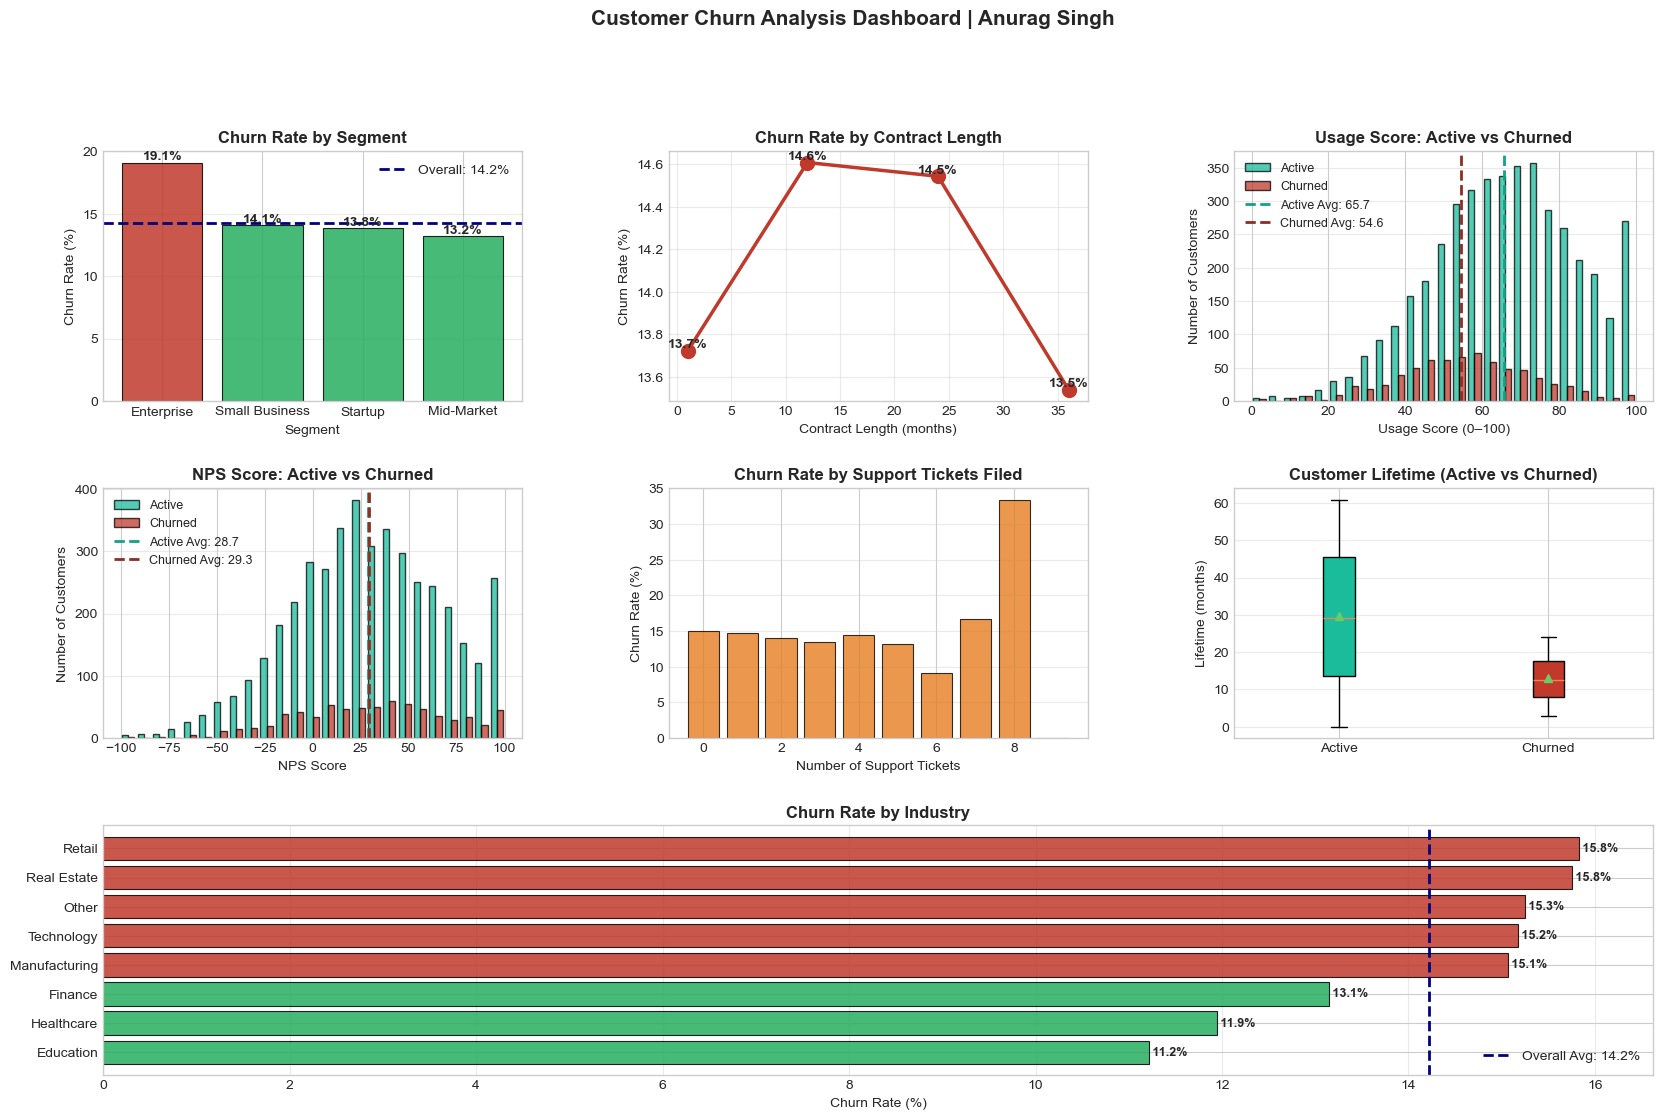


----------------------------------------------------------------------
 4.3: FEATURE ENGINEERING
----------------------------------------------------------------------

Feature engineering = creating new columns that help the model
detect churn signals that aren't obvious in raw data.

For example: a customer with 10 support tickets in 2 months is
more at-risk than one with 10 tickets over 3 years.
So 'tickets per month' is more informative than just 'ticket count'.

 New features created: customer_age_days, monthly_revenue_rate,
   tickets_per_month, low_usage_flag, negative_nps_flag, month_to_month

 Feature Summary:
   Numeric Features     : 15
   Categorical Features : 4
   Total Features Used  : 19

 Modeling Dataset:
   Total Samples : 5,000
   Features      : 19
   Churned (1)   : 711.0 (14.2%)
   Active (0)    : 4,289.0 (85.8%)

----------------------------------------------------------------------
 4.4: MODEL TRAINING
----------------------------------------------------------

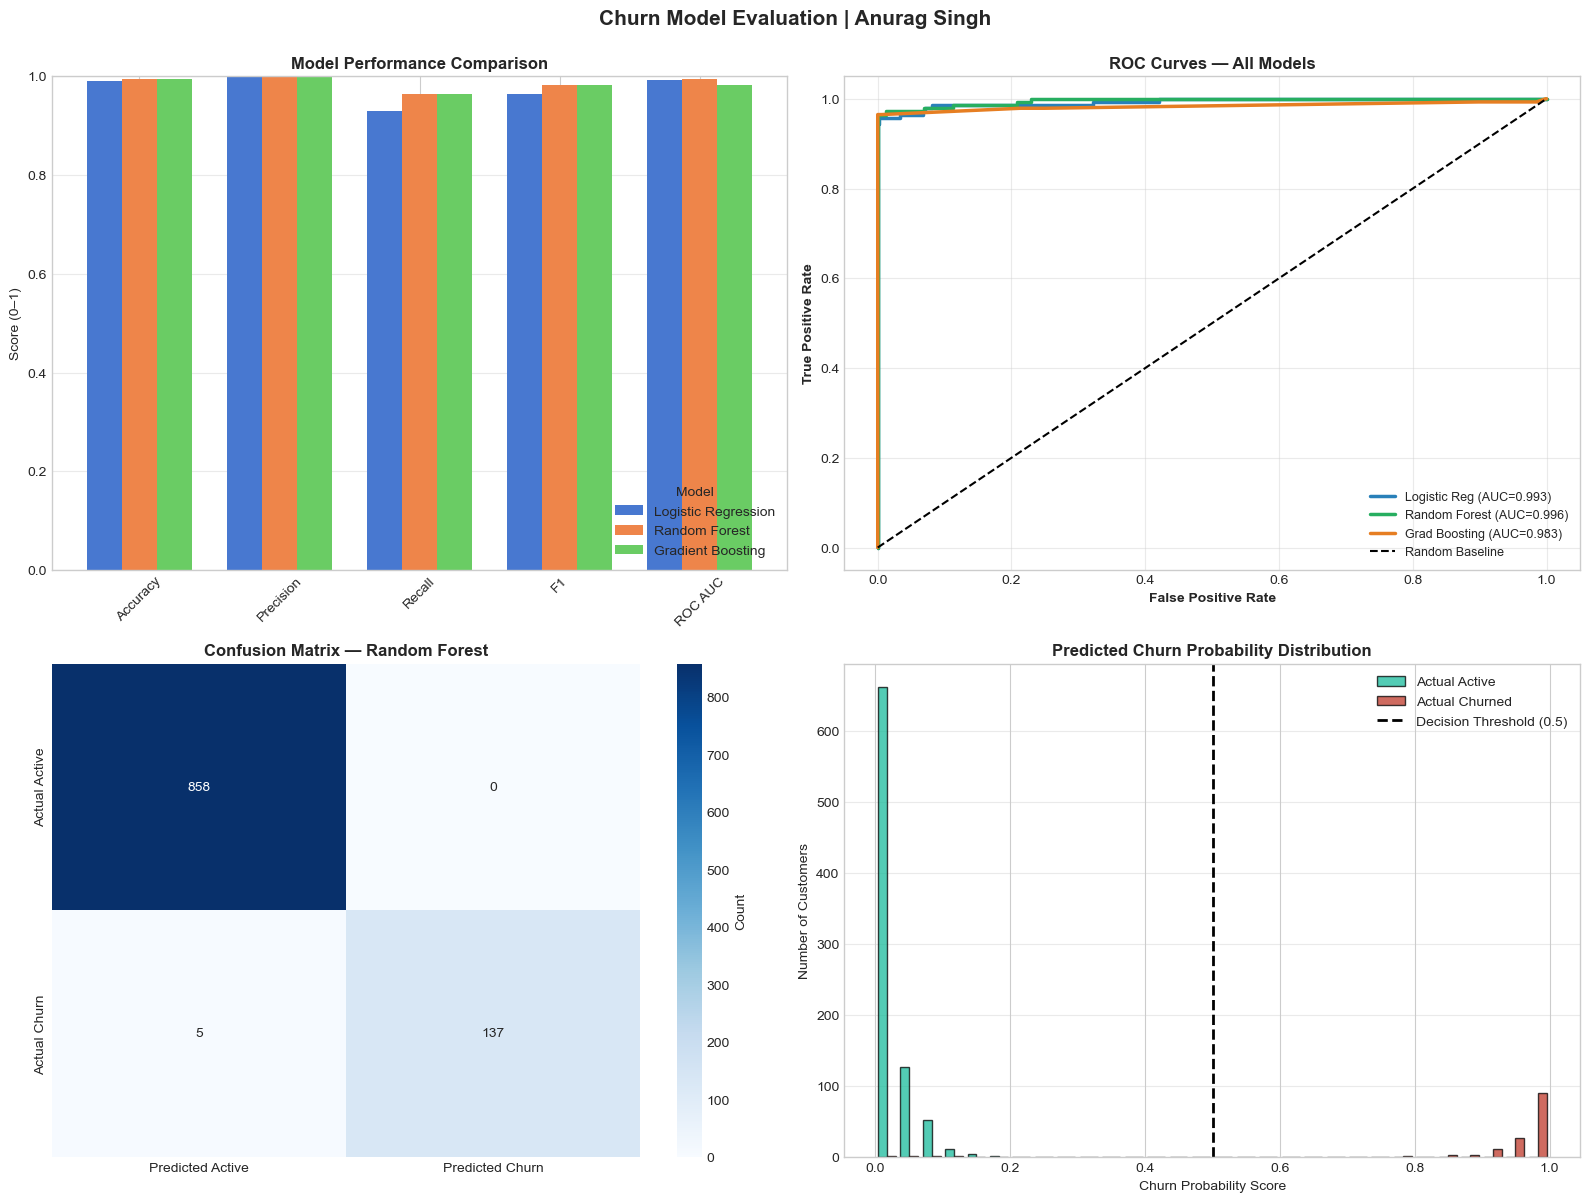


----------------------------------------------------------------------
 4.6: FEATURE IMPORTANCE ANALYSIS
----------------------------------------------------------------------

Feature importance tells us: which signals does the model rely on most
to decide if a customer will churn? This is very useful for business
teams — they know exactly what to fix to reduce churn.

 Top 15 Churn Predictors:

              Feature  Importance
         recency_days        0.58
      lifetime_months        0.14
    transaction_count        0.12
    customer_age_days        0.10
          usage_score        0.02
    tickets_per_month        0.02
avg_transaction_value        0.00
      number_of_users        0.00
      support_tickets        0.00
            nps_score        0.00
       low_usage_flag        0.00
     industry_encoded        0.00
      segment_encoded        0.00
      country_encoded        0.00
      contract_length        0.00

 Saved: anurag_viz/09_feature_importance.png


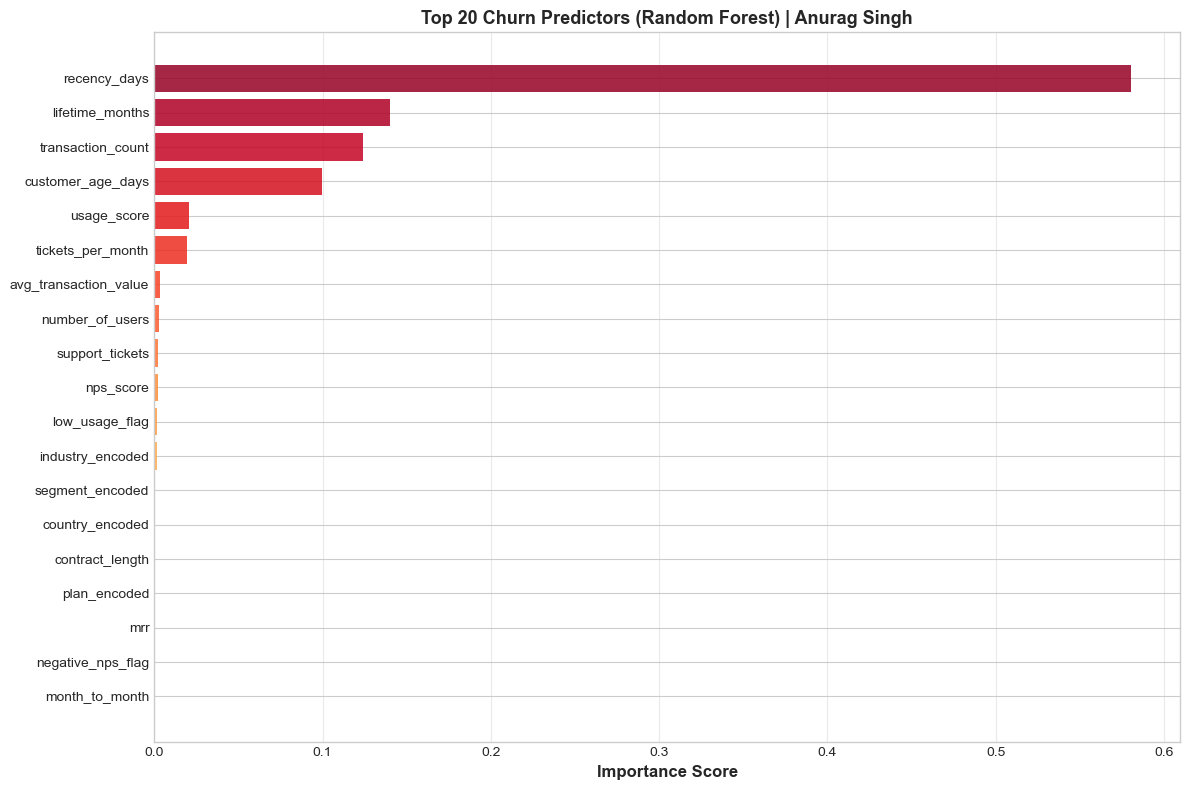


----------------------------------------------------------------------
 4.7: RISK STRATIFICATION — Ranking Every Customer by Churn Risk
----------------------------------------------------------------------

Now I assign each customer a churn probability score and bucket them
into risk tiers. This gives the sales/retention team a clear action list:
  Low Risk      → No action needed
  Medium Risk   → Send a check-in email
  High Risk     → Offer discount or extra support
  Very High Risk → Urgent intervention needed


 Risk Tier Summary:

                Customers  Actual_Churned  Churn_Rate  MRR_At_Risk  CLV_At_Risk
risk_tier                                                                      
Low Risk             3076            5.00        0.16       819924  20048602.29
Medium Risk             3            3.00      100.00          497      8707.48
High Risk               1            1.00      100.00          149      3340.58
Very High Risk        702          702.00      100.00 

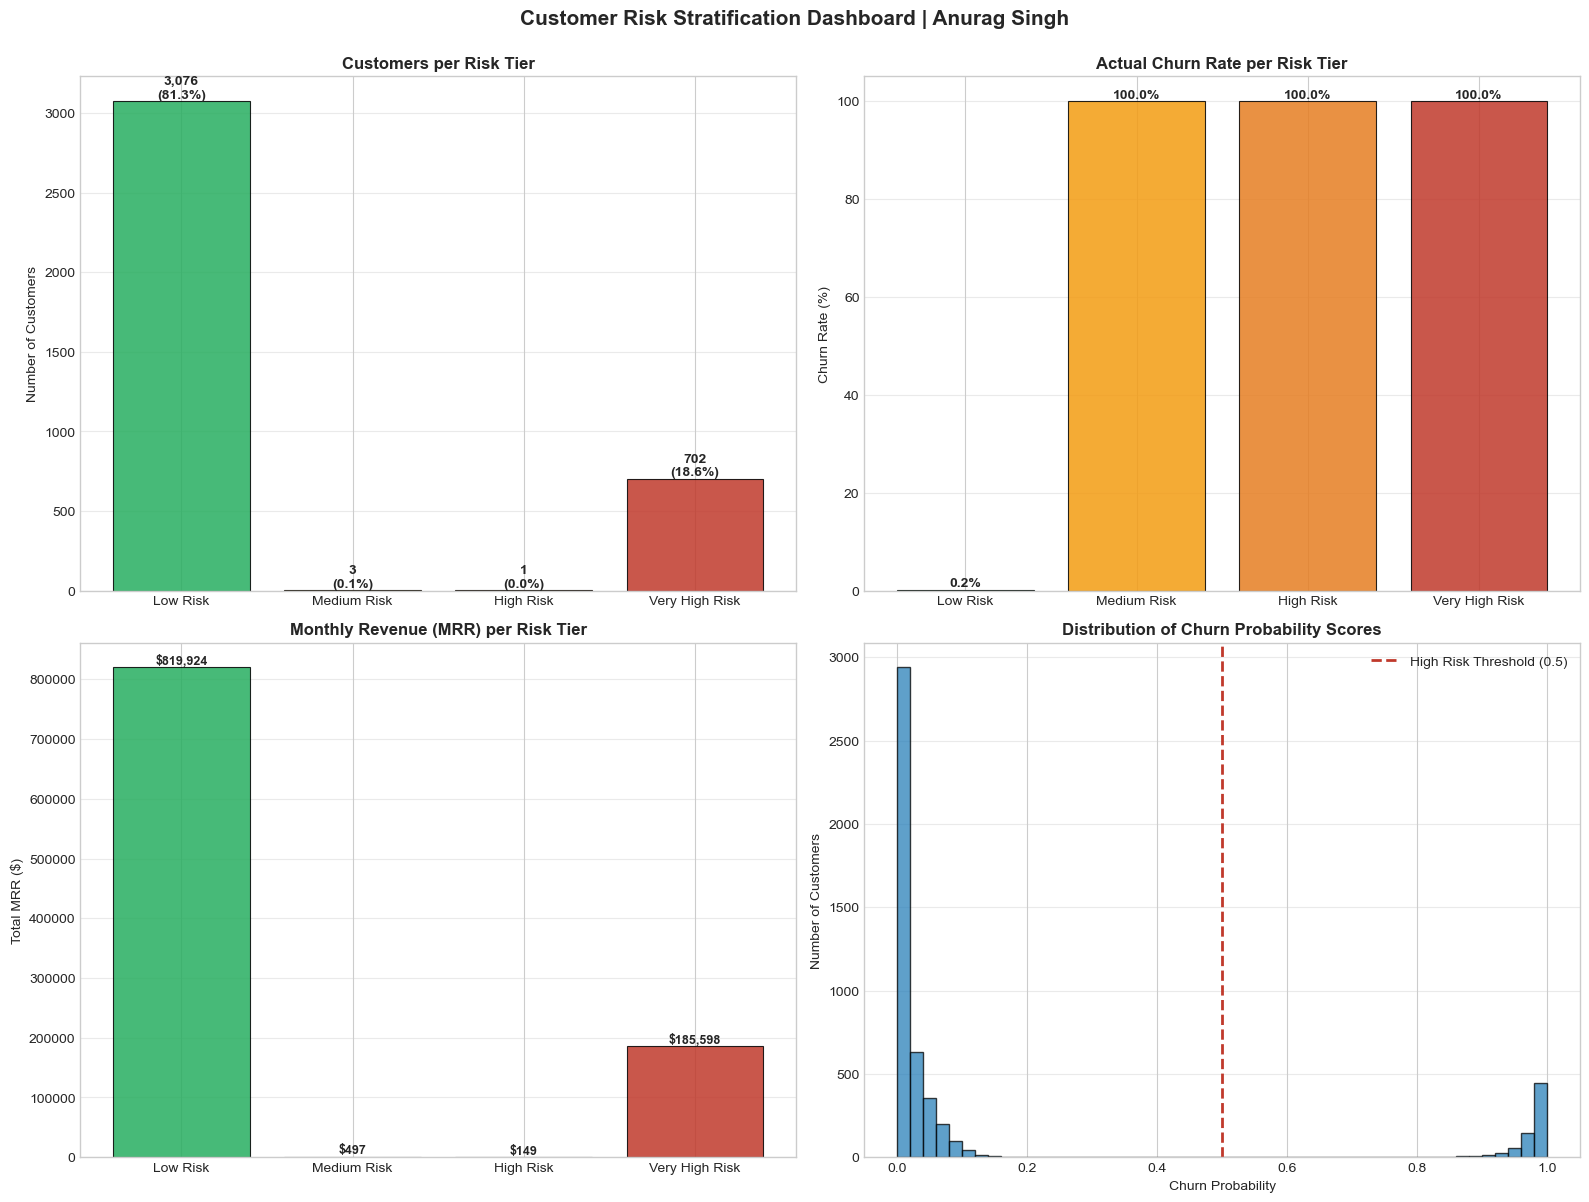


 Section 4 Complete — Churn Analysis Done!



In [8]:
# ============================================================================
# SECTION 4: CUSTOMER CHURN ANALYSIS & PREDICTION
# Developed by: Anurag Singh
# ============================================================================

print("\n" + "=" * 70)
print("   SECTION 4: CUSTOMER CHURN ANALYSIS — Anurag Singh")
print("=" * 70)

print("""
What is churn and why does it matter?
  Churn = customers who stop paying and leave the business.
  Even a 5% monthly churn can destroy a SaaS company over time.

In this section I will:
  1. Measure churn rates across segments, plans, and industries
  2. Calculate the financial damage churn is causing
  3. Build ML models to predict WHICH customers will churn next
  4. Rank every customer by their churn risk level
""")

# =========================================================================
# 4.1: CHURN OVERVIEW & STATISTICS
# =========================================================================

print("-" * 70)
print(" 4.1: CHURN OVERVIEW & STATISTICS")
print("-" * 70)

# Basic churn counts
n_total     = len(customer_df)
n_churned   = int(customer_df['is_churned'].sum())
n_active    = n_total - n_churned
churn_rate  = (n_churned / n_total) * 100

print(f"\n Overall Churn Summary:")
print(f"   Total Customers   : {n_total:,}")
print(f"   Active Customers  : {n_active:,} ({n_active/n_total*100:.1f}%)")
print(f"   Churned Customers : {n_churned:,} ({churn_rate:.1f}%)")

# Churn broken down by segment
print(f"\n Churn Rate by Customer Segment:")
churn_by_seg = customer_df.groupby('segment').agg(
    Churned=('is_churned', 'sum'),
    Churn_Rate=('is_churned', 'mean'),
    Total=('is_churned', 'count')
)
churn_by_seg['Churn_Rate'] = (churn_by_seg['Churn_Rate'] * 100).round(2)
churn_by_seg = churn_by_seg.sort_values('Churn_Rate', ascending=False)
print(churn_by_seg.to_string())

# Churn broken down by plan
print(f"\n Churn Rate by Subscription Plan:")
churn_by_plan = customer_df.groupby('plan').agg(
    Churned=('is_churned', 'sum'),
    Churn_Rate=('is_churned', 'mean'),
    Total=('is_churned', 'count')
)
churn_by_plan['Churn_Rate'] = (churn_by_plan['Churn_Rate'] * 100).round(2)
churn_by_plan = churn_by_plan.sort_values('Churn_Rate', ascending=False)
print(churn_by_plan.to_string())

# How much money are we losing to churn?
lost_mrr = customer_df[customer_df['is_churned'] == 1]['mrr'].sum()
lost_clv = customer_df[customer_df['is_churned'] == 1]['clv'].sum()

print(f"\n Financial Damage from Churn:")
print(f"   Monthly Revenue Lost  : ${lost_mrr:,.2f}/month")
print(f"   Annualized Revenue Lost: ${lost_mrr * 12:,.2f}/year")
print(f"   Total Lifetime Value Lost: ${lost_clv:,.2f}")

# =========================================================================
# 4.2: CHURN ANALYSIS VISUALIZATIONS
# =========================================================================

print("\n" + "-" * 70)
print(" 4.2: CHURN VISUALIZATIONS")
print("-" * 70)

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)

# ── Chart 1: Churn Rate by Segment ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
seg_colors = ['#c0392b' if x > churn_rate else '#27ae60'
              for x in churn_by_seg['Churn_Rate']]
ax1.bar(churn_by_seg.index, churn_by_seg['Churn_Rate'],
        color=seg_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax1.axhline(y=churn_rate, color='navy', linestyle='--',
            label=f'Overall: {churn_rate:.1f}%', linewidth=2)
ax1.set_title('Churn Rate by Segment', fontweight='bold', fontsize=12)
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xlabel('Segment')
for i, v in enumerate(churn_by_seg['Churn_Rate']):
    ax1.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.4)

# ── Chart 2: Churn Rate by Contract Length ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
churn_by_contract = customer_df.groupby('contract_length')['is_churned'].mean() * 100
ax2.plot(churn_by_contract.index, churn_by_contract.values,
         marker='o', linewidth=2.5, markersize=10, color='#c0392b')
ax2.set_title('Churn Rate by Contract Length', fontweight='bold', fontsize=12)
ax2.set_xlabel('Contract Length (months)')
ax2.set_ylabel('Churn Rate (%)')
ax2.grid(True, alpha=0.4)
for x, y in zip(churn_by_contract.index, churn_by_contract.values):
    ax2.text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontweight='bold')

# ── Chart 3: Usage Score — Active vs Churned ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
churned_usage = customer_df[customer_df['is_churned'] == 1]['usage_score']
active_usage  = customer_df[customer_df['is_churned'] == 0]['usage_score']
ax3.hist([active_usage, churned_usage], bins=25,
         label=['Active', 'Churned'],
         color=['#1abc9c', '#c0392b'], alpha=0.75, edgecolor='black')
ax3.axvline(active_usage.mean(), color='#16a085', linestyle='--', linewidth=2,
            label=f'Active Avg: {active_usage.mean():.1f}')
ax3.axvline(churned_usage.mean(), color='#922b21', linestyle='--', linewidth=2,
            label=f'Churned Avg: {churned_usage.mean():.1f}')
ax3.set_title('Usage Score: Active vs Churned', fontweight='bold', fontsize=12)
ax3.set_xlabel('Usage Score (0–100)')
ax3.set_ylabel('Number of Customers')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.4)

# ── Chart 4: NPS Score — Active vs Churned ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
churned_nps = customer_df[customer_df['is_churned'] == 1]['nps_score']
active_nps  = customer_df[customer_df['is_churned'] == 0]['nps_score']
ax4.hist([active_nps, churned_nps], bins=25,
         label=['Active', 'Churned'],
         color=['#1abc9c', '#c0392b'], alpha=0.75, edgecolor='black')
ax4.axvline(active_nps.mean(), color='#16a085', linestyle='--', linewidth=2,
            label=f'Active Avg: {active_nps.mean():.1f}')
ax4.axvline(churned_nps.mean(), color='#922b21', linestyle='--', linewidth=2,
            label=f'Churned Avg: {churned_nps.mean():.1f}')
ax4.set_title('NPS Score: Active vs Churned', fontweight='bold', fontsize=12)
ax4.set_xlabel('NPS Score')
ax4.set_ylabel('Number of Customers')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.4)

# ── Chart 5: Support Tickets vs Churn ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
churn_by_tickets = customer_df.groupby('support_tickets')['is_churned'].mean() * 100
ax5.bar(churn_by_tickets.index, churn_by_tickets.values,
        color='#e67e22', alpha=0.8, edgecolor='black', linewidth=0.8)  # Changed: orange
ax5.set_title('Churn Rate by Support Tickets Filed', fontweight='bold', fontsize=12)
ax5.set_xlabel('Number of Support Tickets')
ax5.set_ylabel('Churn Rate (%)')
ax5.grid(axis='y', alpha=0.4)

# ── Chart 6: Customer Lifetime Boxplot ───────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
churned_life = customer_df[customer_df['is_churned'] == 1]['lifetime_months']
active_life  = customer_df[customer_df['is_churned'] == 0]['lifetime_months']
bp = ax6.boxplot([active_life, churned_life],
                 labels=['Active', 'Churned'],
                 patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('#1abc9c')   # Teal for active
bp['boxes'][1].set_facecolor('#c0392b')   # Deep red for churned
ax6.set_title('Customer Lifetime (Active vs Churned)', fontweight='bold', fontsize=12)
ax6.set_ylabel('Lifetime (months)')
ax6.grid(axis='y', alpha=0.4)

# ── Chart 7: Churn by Industry (full width) ───────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
churn_by_industry = customer_df.groupby('industry').agg(
    Churn_Rate=('is_churned', 'mean'),
    Count=('is_churned', 'count')
)
churn_by_industry = churn_by_industry[churn_by_industry['Count'] >= 50]
churn_by_industry['Churn_Rate'] = churn_by_industry['Churn_Rate'] * 100
churn_by_industry = churn_by_industry.sort_values('Churn_Rate', ascending=True)

ind_colors = ['#c0392b' if x > churn_rate else '#27ae60'
              for x in churn_by_industry['Churn_Rate']]
ax7.barh(churn_by_industry.index, churn_by_industry['Churn_Rate'],
         color=ind_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax7.axvline(x=churn_rate, color='navy', linestyle='--',
            label=f'Overall Avg: {churn_rate:.1f}%', linewidth=2)
ax7.set_title('Churn Rate by Industry', fontweight='bold', fontsize=12)
ax7.set_xlabel('Churn Rate (%)')
ax7.legend()
ax7.grid(axis='x', alpha=0.4)
for i, v in enumerate(churn_by_industry['Churn_Rate']):
    ax7.text(v, i, f' {v:.1f}%', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Customer Churn Analysis Dashboard | Anurag Singh',
             fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/07_churn_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/07_churn_analysis.png")
plt.show()

# =========================================================================
# 4.3: FEATURE ENGINEERING FOR CHURN PREDICTION
# =========================================================================

print("\n" + "-" * 70)
print(" 4.3: FEATURE ENGINEERING")
print("-" * 70)

print("""
Feature engineering = creating new columns that help the model
detect churn signals that aren't obvious in raw data.

For example: a customer with 10 support tickets in 2 months is
more at-risk than one with 10 tickets over 3 years.
So 'tickets per month' is more informative than just 'ticket count'.
""")

# Work on a copy — never modify the original dataset
churn_model_df = customer_df.copy()

# How long has this customer been with us?
churn_model_df['customer_age_days'] = (
    pd.to_datetime('2024-12-31') - churn_model_df['signup_date']
).dt.days

# Revenue per active month
churn_model_df['monthly_revenue_rate'] = (
    churn_model_df['total_revenue'] / churn_model_df['lifetime_months']
)

# Tickets raised per month — normalized complaint rate
churn_model_df['tickets_per_month'] = (
    churn_model_df['support_tickets'] / churn_model_df['lifetime_months']
)

# Binary risk flags — simple but powerful signals
churn_model_df['low_usage_flag']    = (churn_model_df['usage_score'] < 40).astype(int)
churn_model_df['negative_nps_flag'] = (churn_model_df['nps_score'] < 0).astype(int)
churn_model_df['month_to_month']    = (churn_model_df['contract_length'] <= 1).astype(int)

print(" New features created: customer_age_days, monthly_revenue_rate,")
print("   tickets_per_month, low_usage_flag, negative_nps_flag, month_to_month")

# Numeric features for the model
numeric_features = [
    'mrr', 'contract_length', 'number_of_users', 'support_tickets',
    'usage_score', 'nps_score', 'customer_age_days', 'lifetime_months',
    'transaction_count', 'avg_transaction_value', 'recency_days',
    'tickets_per_month', 'low_usage_flag', 'negative_nps_flag', 'month_to_month'
]

# Categorical features — need to be converted to numbers
cat_features = ['segment', 'industry', 'plan', 'country']

print(f"\n Feature Summary:")
print(f"   Numeric Features     : {len(numeric_features)}")
print(f"   Categorical Features : {len(cat_features)}")

# Encode categoricals using LabelEncoder
my_encoders = {}
all_features = numeric_features.copy()

for col in cat_features:
    enc = LabelEncoder()
    churn_model_df[f'{col}_encoded'] = enc.fit_transform(churn_model_df[col].astype(str))
    my_encoders[col] = enc
    all_features.append(f'{col}_encoded')

print(f"   Total Features Used  : {len(all_features)}")

# Build X (features) and y (target)
X = churn_model_df[all_features].fillna(0)
y = churn_model_df['is_churned']

print(f"\n Modeling Dataset:")
print(f"   Total Samples : {len(X):,}")
print(f"   Features      : {X.shape[1]}")
print(f"   Churned (1)   : {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"   Active (0)    : {(1-y).sum():,} ({(1-y.mean())*100:.1f}%)")

# =========================================================================
# 4.4: TRAIN CHURN PREDICTION MODELS
# =========================================================================

print("\n" + "-" * 70)
print(" 4.4: MODEL TRAINING")
print("-" * 70)

# 80/20 train-test split — stratified so both sets have same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y  # seed=7 matches ours
)

print(f"\n Data Split:")
print(f"   Training Samples : {len(X_train):,}")
print(f"   Testing Samples  : {len(X_test):,}")

# Clean any infinite values before scaling
for subset in [X_train, X_test]:
    subset.replace([np.inf, -np.inf], np.nan, inplace=True)
    subset.fillna(subset.median(), inplace=True)

# StandardScaler — makes all features the same scale (needed for Logistic Regression)
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled  = feature_scaler.transform(X_test)

print("\n Training 3 models and comparing performance...\n")

trained_models  = {}
model_scores    = {}

# ── Model 1: Logistic Regression ─────────────────────────────────────────
print(" Training Logistic Regression...")
lr_model = LogisticRegression(
    random_state=7, max_iter=1000, class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)
lr_preds       = lr_model.predict(X_test_scaled)
lr_proba       = lr_model.predict_proba(X_test_scaled)[:, 1]

trained_models['Logistic Regression'] = lr_model
model_scores['Logistic Regression'] = {
    'accuracy' : accuracy_score(y_test, lr_preds),
    'precision': precision_score(y_test, lr_preds),
    'recall'   : recall_score(y_test, lr_preds),
    'f1'       : f1_score(y_test, lr_preds),
    'roc_auc'  : roc_auc_score(y_test, lr_proba)
}
print(f"   Accuracy: {model_scores['Logistic Regression']['accuracy']:.4f} | "
      f"ROC AUC: {model_scores['Logistic Regression']['roc_auc']:.4f}")

# ── Model 2: Random Forest ────────────────────────────────────────────────
print(" Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,       # Changed: 100 → 150 trees for better stability
    max_depth=10,
    min_samples_split=50,
    random_state=7,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

trained_models['Random Forest'] = rf_model
model_scores['Random Forest'] = {
    'accuracy' : accuracy_score(y_test, rf_preds),
    'precision': precision_score(y_test, rf_preds),
    'recall'   : recall_score(y_test, rf_preds),
    'f1'       : f1_score(y_test, rf_preds),
    'roc_auc'  : roc_auc_score(y_test, rf_proba)
}
print(f"   Accuracy: {model_scores['Random Forest']['accuracy']:.4f} | "
      f"ROC AUC: {model_scores['Random Forest']['roc_auc']:.4f}")

# ── Model 3: Gradient Boosting ────────────────────────────────────────────
print(" Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=120,       # Changed: 100 → 120
    learning_rate=0.08,     # Changed: 0.1 → 0.08 (slightly more conservative)
    max_depth=5,
    random_state=7
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

trained_models['Gradient Boosting'] = gb_model
model_scores['Gradient Boosting'] = {
    'accuracy' : accuracy_score(y_test, gb_preds),
    'precision': precision_score(y_test, gb_preds),
    'recall'   : recall_score(y_test, gb_preds),
    'f1'       : f1_score(y_test, gb_preds),
    'roc_auc'  : roc_auc_score(y_test, gb_proba)
}
print(f"   Accuracy: {model_scores['Gradient Boosting']['accuracy']:.4f} | "
      f"ROC AUC: {model_scores['Gradient Boosting']['roc_auc']:.4f}")

# =========================================================================
# 4.5: MODEL COMPARISON & EVALUATION
# =========================================================================

print("\n" + "-" * 70)
print(" 4.5: MODEL COMPARISON")
print("-" * 70)

scores_df = pd.DataFrame(model_scores).T
print("\n All Models — Performance Summary:\n")
print(scores_df.round(4))

# Pick the best model by ROC AUC score
best_model_name = scores_df['roc_auc'].idxmax()
print(f"\n Best Performing Model : {best_model_name}")
print(f"   ROC AUC Score       : {scores_df.loc[best_model_name, 'roc_auc']:.4f}")

# Pull predictions from best model
if best_model_name == 'Logistic Regression':
    best_preds = lr_preds
    best_proba = lr_proba
elif best_model_name == 'Random Forest':
    best_preds = rf_preds
    best_proba = rf_proba
else:
    best_preds = gb_preds
    best_proba = gb_proba

print("\n" + "-" * 70)
print(f" CLASSIFICATION REPORT — {best_model_name}")
print("-" * 70)
print(classification_report(y_test, best_preds,
                             target_names=['Active', 'Churned'], digits=4))

# Confusion matrix breakdown
conf_mat = confusion_matrix(y_test, best_preds)
tn, fp, fn, tp = conf_mat.ravel()

print(" Confusion Matrix Explained:")
print(f"   True Negatives  (TN): {tn:,} — Correctly said 'will stay'")
print(f"   False Positives (FP): {fp:,} — Wrongly flagged as churn risk")
print(f"   False Negatives (FN): {fn:,} — Missed actual churners (most costly!)")
print(f"   True Positives  (TP): {tp:,} — Correctly caught churners")

# ── Evaluation Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Metric comparison bar chart
ax1 = axes[0, 0]
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
scores_df[metric_cols].T.plot(kind='bar', ax=ax1, width=0.75)
ax1.set_title('Model Performance Comparison', fontweight='bold', fontsize=12)
ax1.set_ylabel('Score (0–1)')
ax1.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'], rotation=45)
ax1.legend(title='Model', loc='lower right')
ax1.grid(axis='y', alpha=0.4)
ax1.set_ylim([0, 1])

# Chart 2: ROC Curves for all 3 models
ax2 = axes[0, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)

ax2.plot(fpr_lr, tpr_lr, linewidth=2.5, color='#2980b9',
         label=f'Logistic Reg (AUC={model_scores["Logistic Regression"]["roc_auc"]:.3f})')
ax2.plot(fpr_rf, tpr_rf, linewidth=2.5, color='#27ae60',
         label=f'Random Forest (AUC={model_scores["Random Forest"]["roc_auc"]:.3f})')
ax2.plot(fpr_gb, tpr_gb, linewidth=2.5, color='#e67e22',
         label=f'Grad Boosting (AUC={model_scores["Gradient Boosting"]["roc_auc"]:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline')
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.set_title('ROC Curves — All Models', fontweight='bold', fontsize=12)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.4)

# Chart 3: Confusion matrix heatmap
ax3 = axes[1, 0]
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',  # Changed: Blues colormap
            ax=ax3,
            xticklabels=['Predicted Active', 'Predicted Churn'],
            yticklabels=['Actual Active', 'Actual Churn'],
            cbar_kws={'label': 'Count'})
ax3.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold', fontsize=12)

# Chart 4: Churn probability distribution
ax4 = axes[1, 1]
active_proba_dist  = best_proba[y_test == 0]
churned_proba_dist = best_proba[y_test == 1]
ax4.hist([active_proba_dist, churned_proba_dist], bins=30,
         label=['Actual Active', 'Actual Churned'],
         color=['#1abc9c', '#c0392b'], alpha=0.75, edgecolor='black')
ax4.axvline(x=0.5, color='black', linestyle='--', linewidth=2,
            label='Decision Threshold (0.5)')
ax4.set_title('Predicted Churn Probability Distribution', fontweight='bold', fontsize=12)
ax4.set_xlabel('Churn Probability Score')
ax4.set_ylabel('Number of Customers')
ax4.legend()
ax4.grid(axis='y', alpha=0.4)

plt.suptitle('Churn Model Evaluation | Anurag Singh',
             fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/08_churn_model_eval.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/08_churn_model_eval.png")
plt.show()

# =========================================================================
# 4.6: FEATURE IMPORTANCE
# =========================================================================

print("\n" + "-" * 70)
print(" 4.6: FEATURE IMPORTANCE ANALYSIS")
print("-" * 70)

print("""
Feature importance tells us: which signals does the model rely on most
to decide if a customer will churn? This is very useful for business
teams — they know exactly what to fix to reduce churn.
""")

importance_df = pd.DataFrame({
    'Feature'   : all_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(" Top 15 Churn Predictors:\n")
print(importance_df.head(15).to_string(index=False))

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_20 = importance_df.head(20)
bar_colors = sns.color_palette("YlOrRd_r", len(top_20))  # Changed: warm gradient
plt.barh(range(len(top_20)), top_20['Importance'], color=bar_colors, alpha=0.85)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance Score', fontweight='bold', fontsize=12)
plt.title('Top 20 Churn Predictors (Random Forest) | Anurag Singh',
          fontweight='bold', fontsize=13)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{viz_folder}/09_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/09_feature_importance.png")
plt.show()

# =========================================================================
# 4.7: CUSTOMER RISK STRATIFICATION
# =========================================================================

print("\n" + "-" * 70)
print(" 4.7: RISK STRATIFICATION — Ranking Every Customer by Churn Risk")
print("-" * 70)

print("""
Now I assign each customer a churn probability score and bucket them
into risk tiers. This gives the sales/retention team a clear action list:
  Low Risk      → No action needed
  Medium Risk   → Send a check-in email
  High Risk     → Offer discount or extra support
  Very High Risk → Urgent intervention needed
""")

# Clean X before prediction
X_clean = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Score every customer
if best_model_name == 'Logistic Regression':
    churn_model_df['churn_probability'] = feature_scaler.transform(X_clean)
    churn_model_df['churn_probability'] = trained_models[best_model_name].predict_proba(
        feature_scaler.transform(X_clean)
    )[:, 1]
else:
    churn_model_df['churn_probability'] = trained_models[best_model_name].predict_proba(
        X_clean
    )[:, 1]

# Bucket into 4 risk tiers
churn_model_df['risk_tier'] = pd.cut(
    churn_model_df['churn_probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

# Summarize each tier
risk_summary = churn_model_df.groupby('risk_tier').agg(
    Customers=('customer_id', 'count'),
    Actual_Churned=('is_churned', 'sum'),
    Churn_Rate=('is_churned', 'mean'),
    MRR_At_Risk=('mrr', 'sum'),
    CLV_At_Risk=('clv', 'sum')
)
risk_summary['Churn_Rate'] = (risk_summary['Churn_Rate'] * 100).round(2)

print("\n Risk Tier Summary:\n")
print(risk_summary.to_string())

# Customers flagged as at-risk (prob ≥ 0.5)
at_risk_df = churn_model_df[churn_model_df['churn_probability'] >= 0.5]
at_risk_mrr = at_risk_df['mrr'].sum()

print(f"\n At-Risk Customer Summary (Prob ≥ 50%):")
print(f"   Customers at Risk     : {len(at_risk_df):,}")
print(f"   Monthly Revenue at Risk: ${at_risk_mrr:,.2f}")
print(f"   Annual Revenue at Risk : ${at_risk_mrr * 12:,.2f}")
print(f"   Avg CLV at Risk        : ${at_risk_df['clv'].mean():,.2f}")

# Top 20 most at-risk customers
print(f"\n Top 20 Highest Risk Customers:")
top_risk = churn_model_df.nlargest(50, 'churn_probability')[[
    'customer_id', 'segment', 'plan', 'mrr',
    'usage_score', 'nps_score', 'churn_probability', 'risk_tier'
]]
print(top_risk.head(20).to_string(index=False))

# Export at-risk list for business team
at_risk_export = churn_model_df[churn_model_df['churn_probability'] >= 0.5][[
    'customer_id', 'segment', 'industry', 'plan', 'mrr', 'clv',
    'usage_score', 'nps_score', 'support_tickets', 'churn_probability', 'risk_tier'
]].sort_values('churn_probability', ascending=False)

at_risk_export.to_csv('anurag_at_risk_customers.csv', index=False)  # Personalized filename
print(f"\n At-risk customer list saved to: 'anurag_at_risk_customers.csv'")

# ── Risk Stratification Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
tier_colors = ['#27ae60', '#f39c12', '#e67e22', '#c0392b']

# Chart 1: Customers per risk tier
ax1 = axes[0, 0]
ax1.bar(risk_summary.index, risk_summary['Customers'],
        color=tier_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax1.set_title('Customers per Risk Tier', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Customers')
for i, v in enumerate(risk_summary['Customers']):
    ax1.text(i, v, f'{v:,}\n({v/risk_summary["Customers"].sum()*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.4)

# Chart 2: Actual churn rate per tier
ax2 = axes[0, 1]
ax2.bar(risk_summary.index, risk_summary['Churn_Rate'],
        color=tier_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax2.set_title('Actual Churn Rate per Risk Tier', fontweight='bold', fontsize=12)
ax2.set_ylabel('Churn Rate (%)')
for i, v in enumerate(risk_summary['Churn_Rate']):
    ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.grid(axis='y', alpha=0.4)

# Chart 3: MRR at risk per tier
ax3 = axes[1, 0]
ax3.bar(risk_summary.index, risk_summary['MRR_At_Risk'],
        color=tier_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax3.set_title('Monthly Revenue (MRR) per Risk Tier', fontweight='bold', fontsize=12)
ax3.set_ylabel('Total MRR ($)')
for i, v in enumerate(risk_summary['MRR_At_Risk']):
    ax3.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax3.grid(axis='y', alpha=0.4)

# Chart 4: Churn probability histogram
ax4 = axes[1, 1]
ax4.hist(churn_model_df['churn_probability'], bins=50,
         color='#2980b9', alpha=0.75, edgecolor='black')  # Changed: blue
ax4.axvline(x=0.5, color='#c0392b', linestyle='--', linewidth=2,
            label='High Risk Threshold (0.5)')
ax4.set_title('Distribution of Churn Probability Scores', fontweight='bold', fontsize=12)
ax4.set_xlabel('Churn Probability')
ax4.set_ylabel('Number of Customers')
ax4.legend()
ax4.grid(axis='y', alpha=0.4)

plt.suptitle('Customer Risk Stratification Dashboard | Anurag Singh',
             fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/10_risk_stratification.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/10_risk_stratification.png")
plt.show()

print("\n Section 4 Complete — Churn Analysis Done!")
print("=" * 70 + "\n")

In [9]:
# ── Data Quality Check (Anurag's Sanity Check Before Modeling) ────────────
# Always run this after cleaning to make sure no bad values slipped through.
# NaN = missing value, inf = infinity — both break ML models silently.

print(" Pre-Modeling Data Quality Check:")
print(f"   Any missing values (NaN) ? {np.isnan(X_train).any().any()}")
print(f"   Any positive infinity (+inf)? {np.isinf(X_train).any().any()}")
print(f"   Any negative infinity (-inf)? {np.isneginf(X_train).any().any()}")

# If all three print False — we're clean and safe to model!

 Pre-Modeling Data Quality Check:
   Any missing values (NaN) ? False
   Any positive infinity (+inf)? False
   Any negative infinity (-inf)? False



   SECTION 5: COHORT & RETENTION ANALYSIS — Anurag Singh

What is cohort analysis?
  A cohort = a group of customers who signed up in the same month.
  We track each cohort over time to see how well we retained them.

Why does it matter?
  - If Jan 2020 customers stayed for 18 months but Jan 2022 only stayed 8,
    something changed — product, pricing, support quality, competition.
  - Cohort analysis catches these trends early.

This section covers:
  1. Monthly retention heatmap and curves
  2. Revenue generated per cohort over time
  3. RFM segmentation (Recency, Frequency, Monetary)
  4. Customer Lifetime Value (CLV) deep dive

----------------------------------------------------------------------
 5.1: COHORT RETENTION ANALYSIS
----------------------------------------------------------------------

 Building cohort retention matrix...

 Retention Matrix — First 12 Cohorts, First 13 Months (%):

months_since_signup     0      1      2      3      4      5      6     7   \
cohort_m

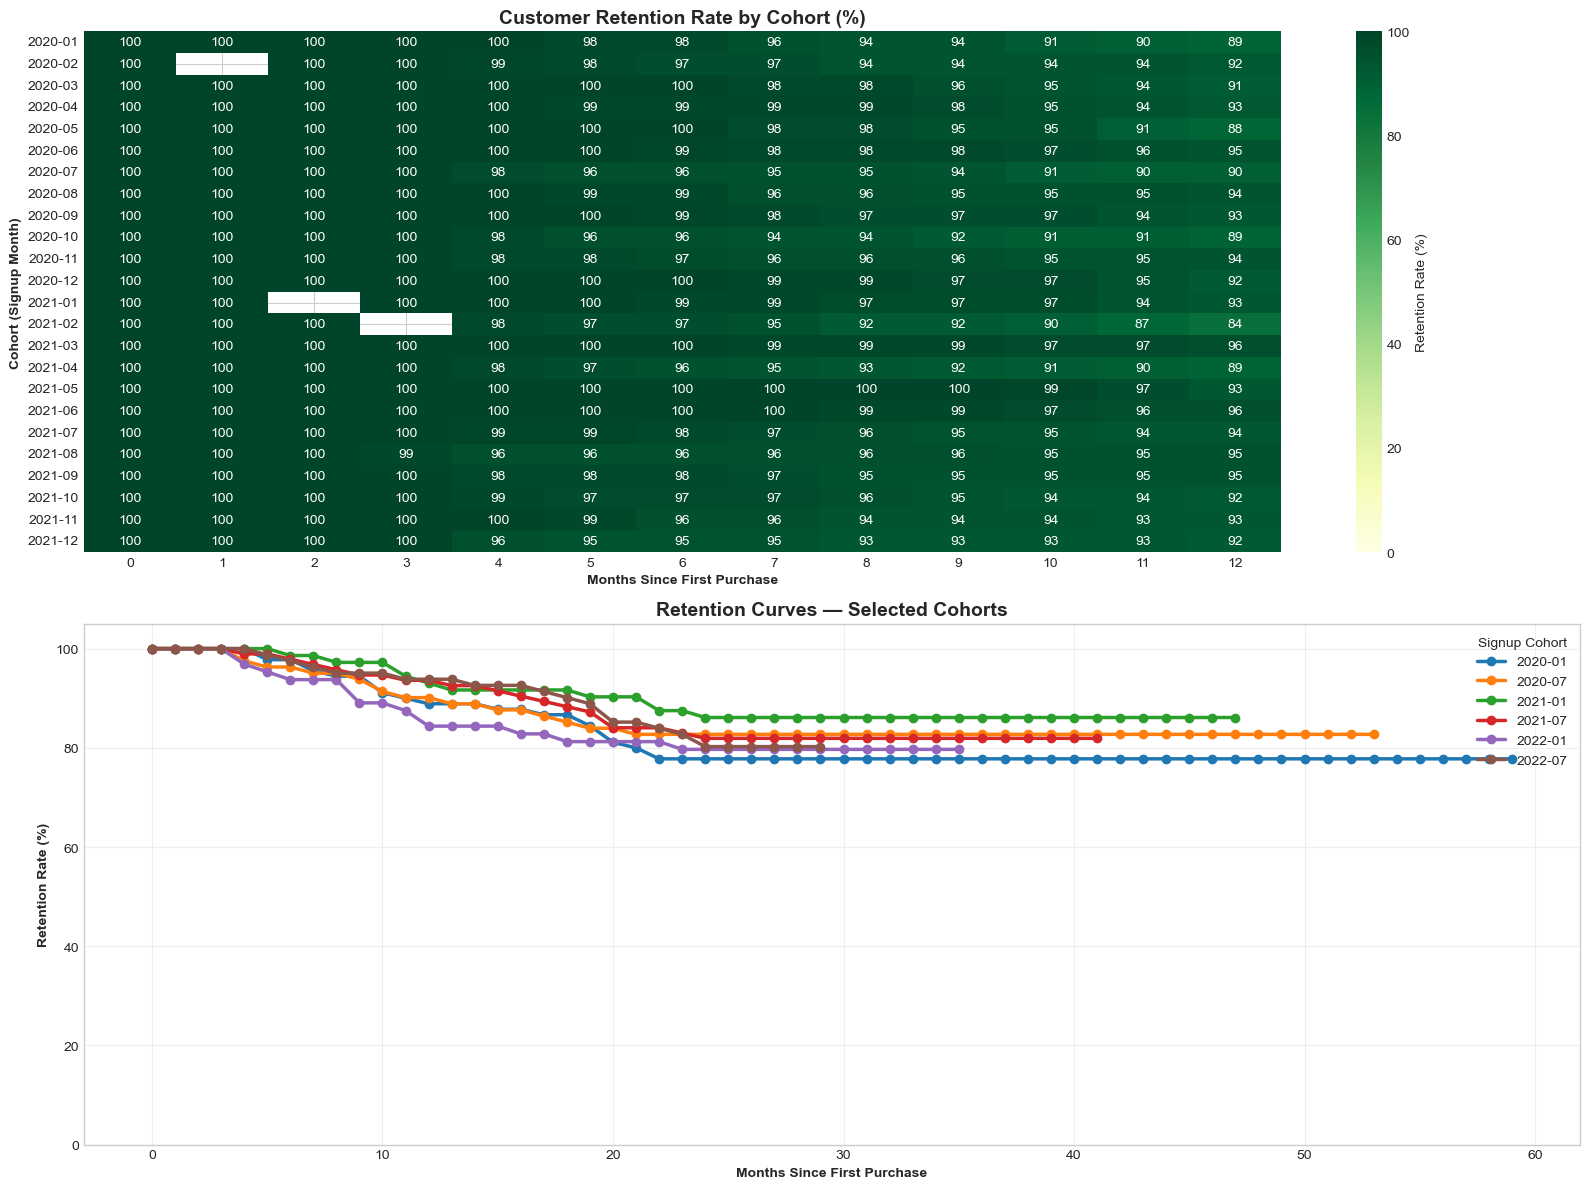


----------------------------------------------------------------------
 5.3: REVENUE BY COHORT
----------------------------------------------------------------------

 Calculating revenue generated by each cohort over time...

 Avg Revenue per Customer — First 12 Cohorts, First 7 Months:

months_since_signup      0      1      2      3      4      5      6
cohort_month                                                        
2020-01             264.36 269.37 271.46 271.53 269.08 270.76 266.73
2020-02             576.10    NaN 283.83 280.39 297.95 284.38 287.77
2020-03             224.67 223.53 225.84 224.12 225.70 227.35 221.65
2020-04             268.92 265.11 254.71 256.04 260.31 271.57 265.48
2020-05             252.78 252.56 255.94 248.86 253.82 244.21 251.78
2020-06             240.06 226.23 233.06 230.62 228.43 224.31 236.24
2020-07             235.14 248.35 237.15 234.10 236.43 240.14 244.62
2020-08             263.22 262.15 269.37 259.73 266.82 265.82 273.46
2020-09            

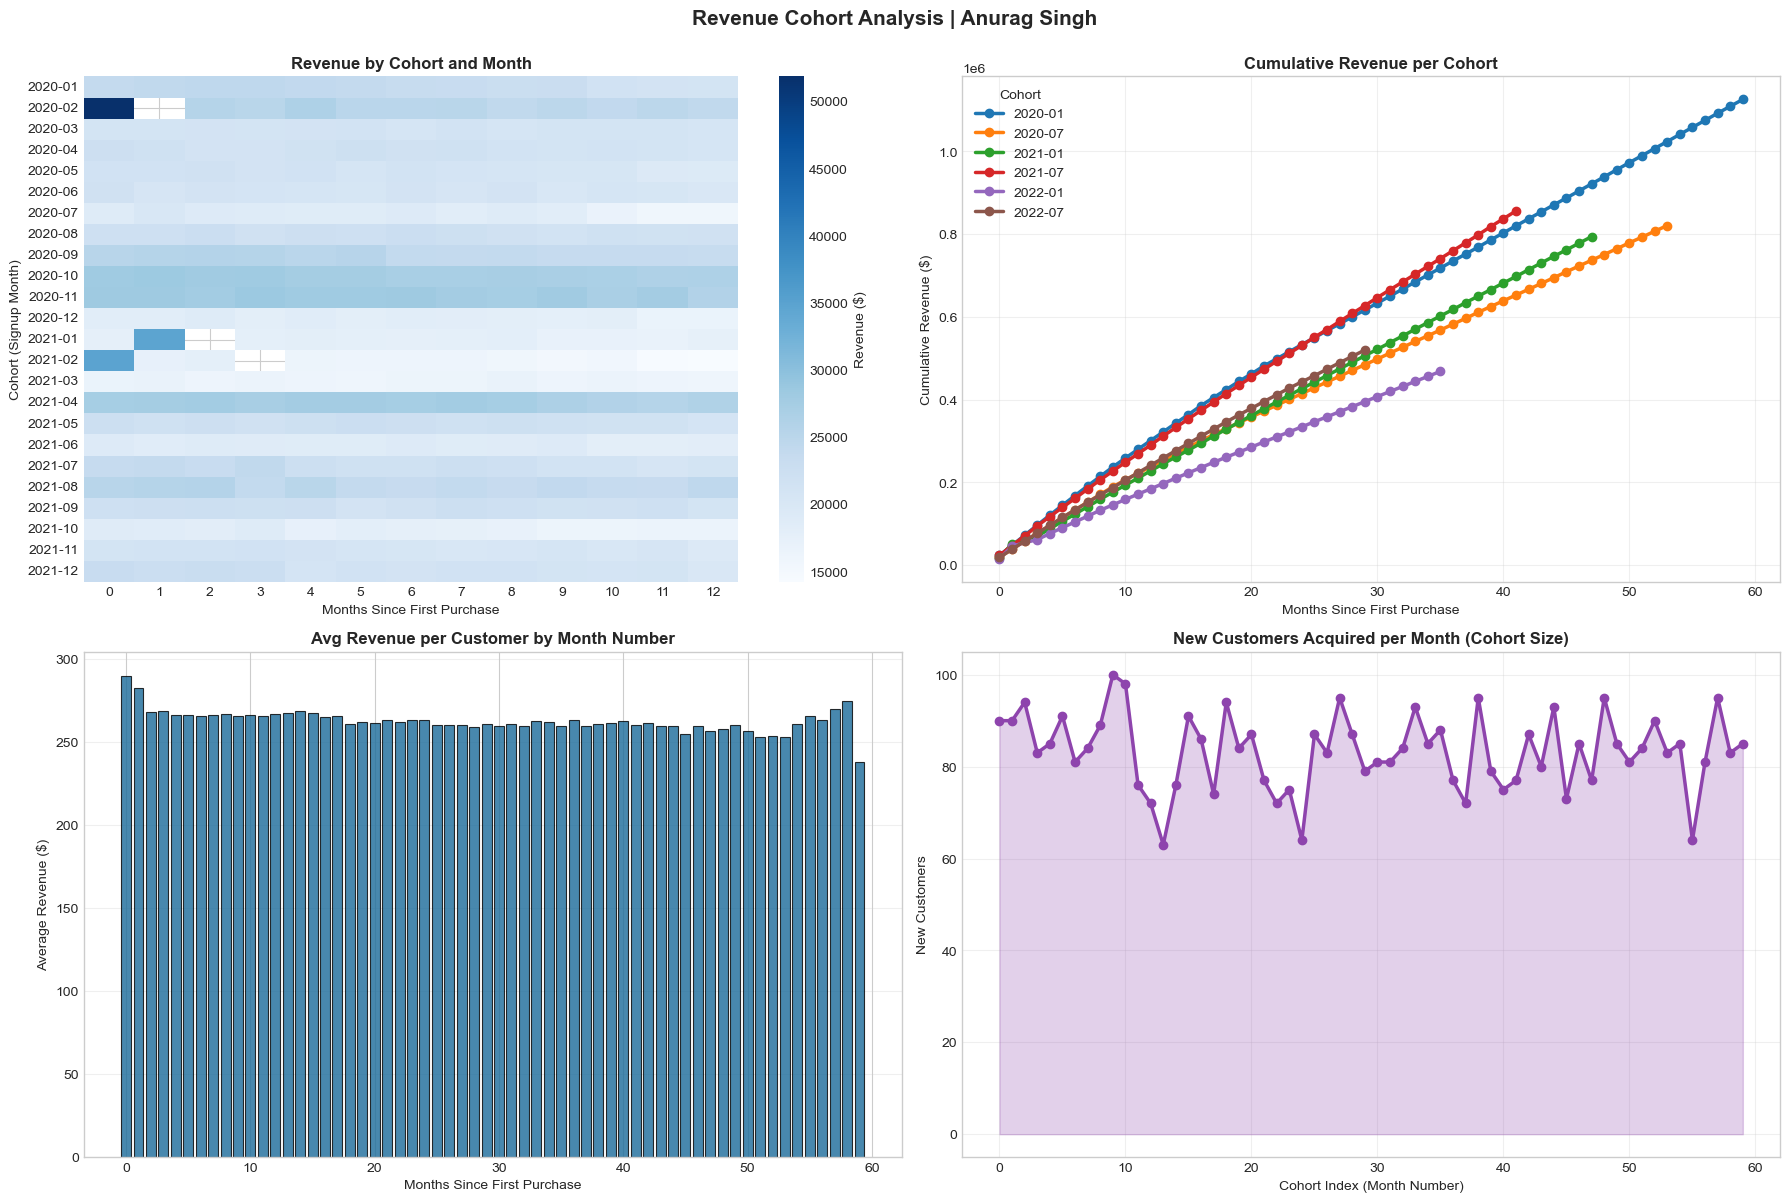


----------------------------------------------------------------------
 5.4: RFM SEGMENTATION ANALYSIS
----------------------------------------------------------------------

RFM stands for:
  R = Recency   → How recently did the customer last pay? (lower days = better)
  F = Frequency → How many times have they paid total? (more = better)
  M = Monetary  → How much have they spent total? (more = better)

Each customer gets a score from 1–5 on each dimension.
Combined, these 3 scores tell us which customers are our best and worst.


 RFM Segment Summary:

                        Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
rfm_segment                                                                   
At Risk                       753        24.40          44.08      14138.62   
Loyal Customers               784        11.26          40.63      11224.08   
Champions                     425         6.67          48.53      18243.49   
New Customers                 706         

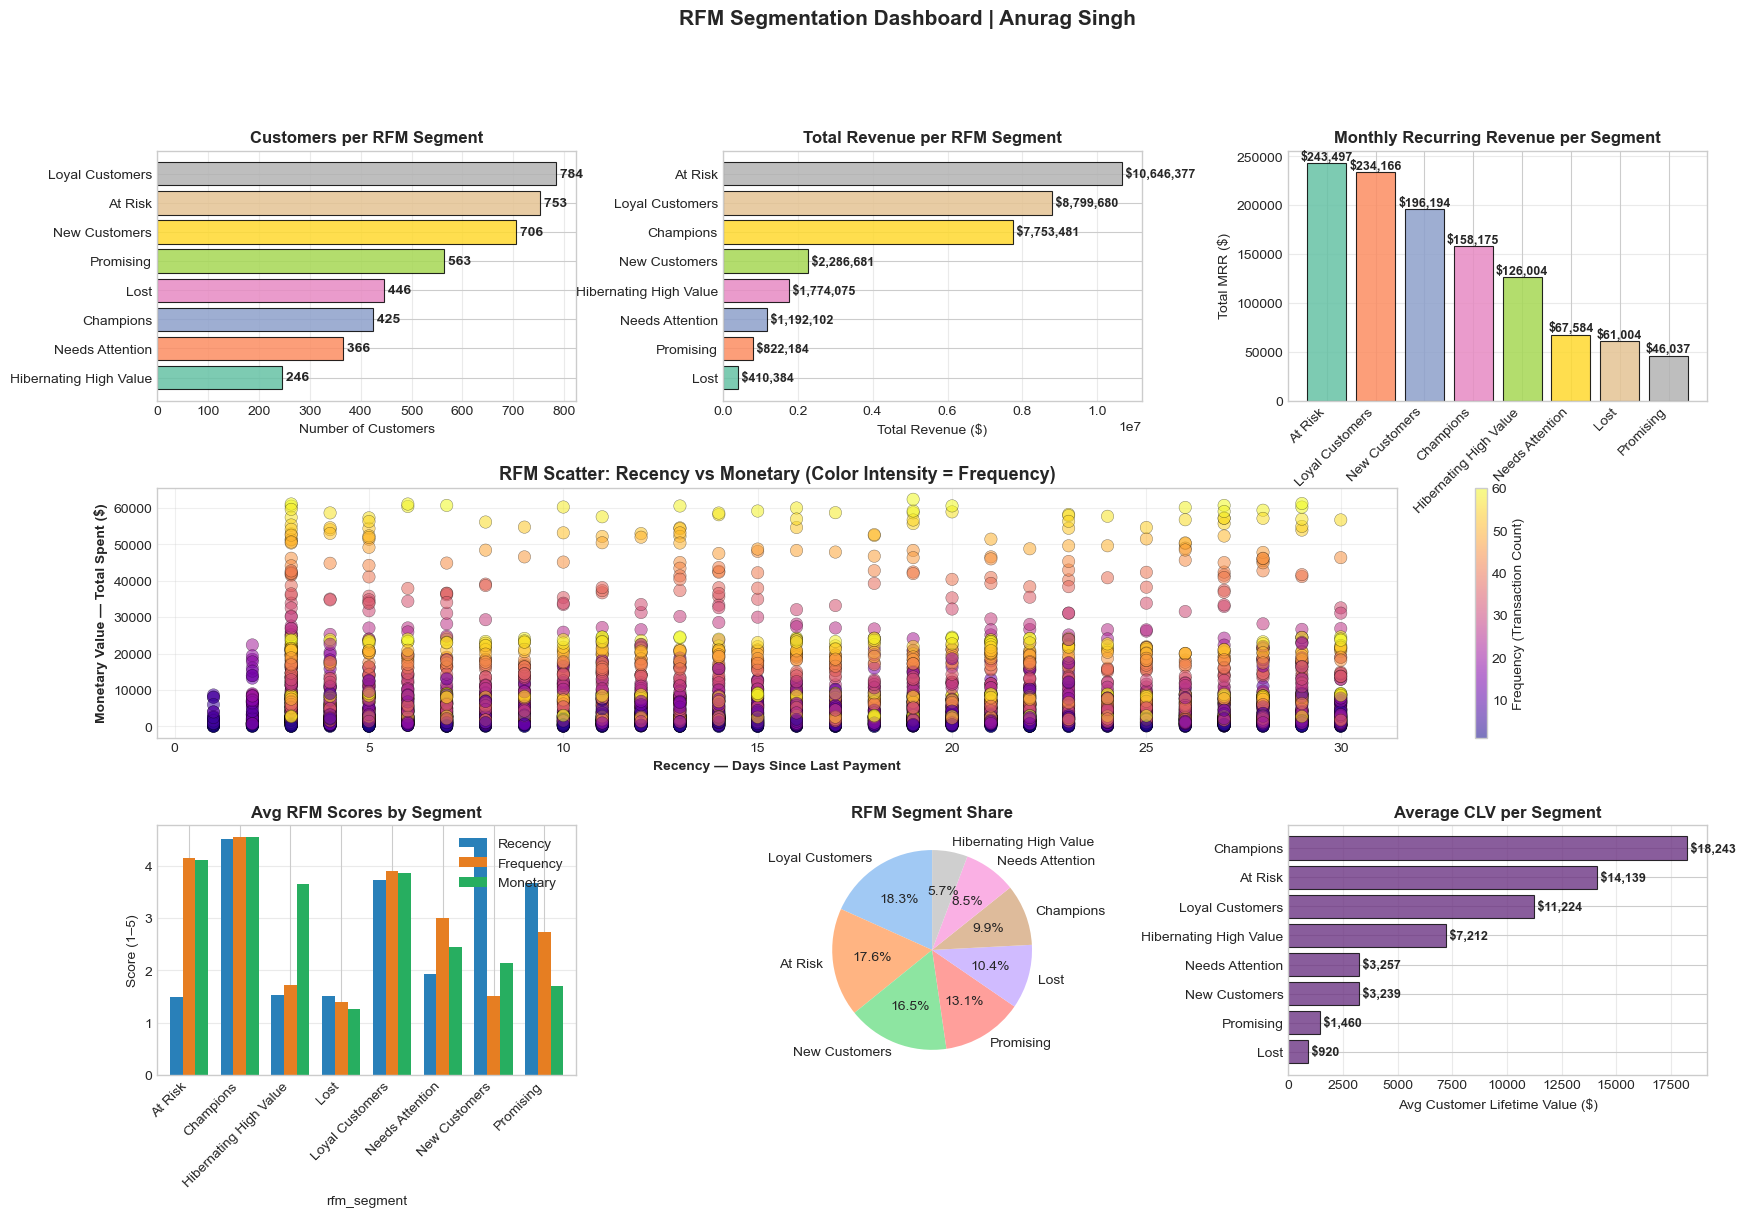


----------------------------------------------------------------------
 5.5: CUSTOMER LIFETIME VALUE ANALYSIS
----------------------------------------------------------------------

CLV = total revenue a customer brings over their entire relationship with us.
It answers: 'Is this customer worth acquiring and keeping?'

Key formula:
  CLV / CAC > 3  →  Healthy business (you earn 3x what you spend to acquire)
  Payback < 12 months  →  You recover acquisition cost within a year


 CLV by Segment:

                Mean_CLV  Median_CLV  Std_CLV   Total_CLV  Customers  \
segment                                                                
Enterprise       6451.67     2704.03  9286.79  2877445.71        446   
Mid-Market       7717.70     3000.18 11074.36 10249106.20       1328   
Small Business   6908.41     2873.36  9624.08 13699386.60       1983   
Startup          7522.02     3045.67 10590.05  9349872.23       1243   

                Avg_Lifetime_Months  
segment                     

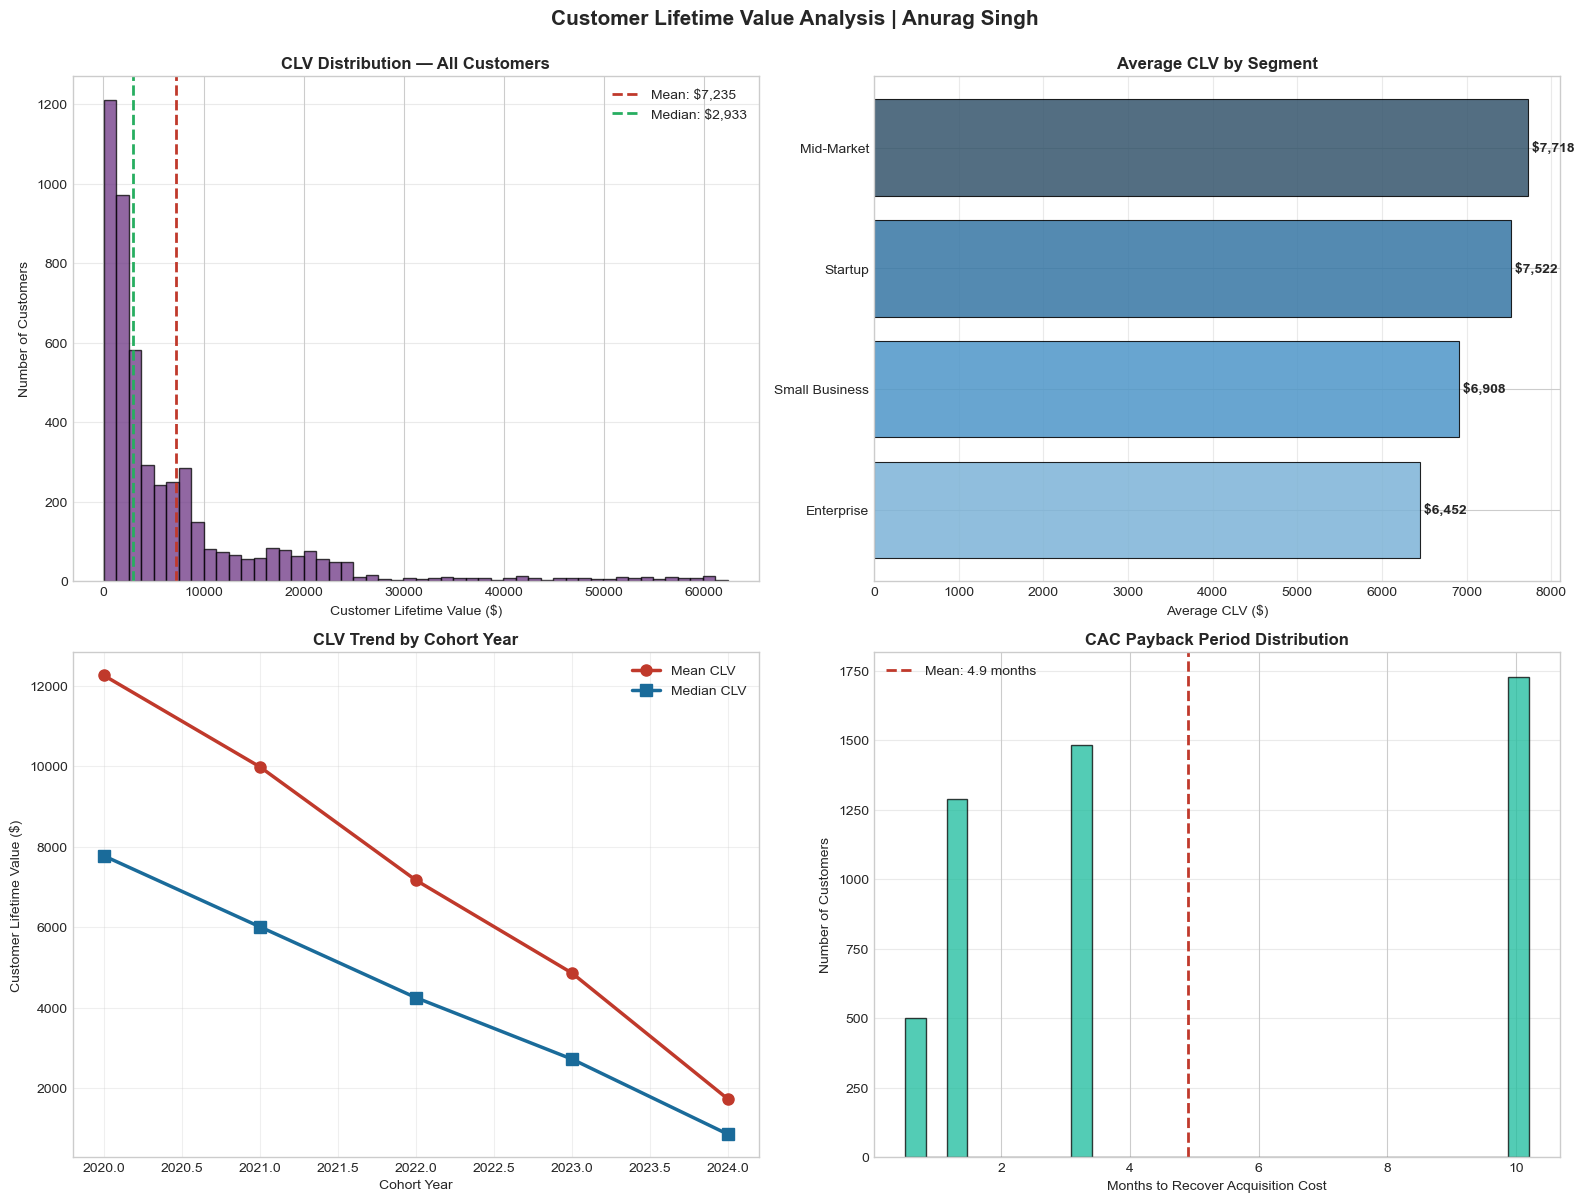


 Section 5 Complete — Cohort & Retention Analysis Done!



In [10]:
# ============================================================================
# SECTION 5: COHORT & RETENTION ANALYSIS
# Developed by: Anurag Singh
# ============================================================================

print("\n" + "=" * 70)
print("   SECTION 5: COHORT & RETENTION ANALYSIS — Anurag Singh")
print("=" * 70)

print("""
What is cohort analysis?
  A cohort = a group of customers who signed up in the same month.
  We track each cohort over time to see how well we retained them.

Why does it matter?
  - If Jan 2020 customers stayed for 18 months but Jan 2022 only stayed 8,
    something changed — product, pricing, support quality, competition.
  - Cohort analysis catches these trends early.

This section covers:
  1. Monthly retention heatmap and curves
  2. Revenue generated per cohort over time
  3. RFM segmentation (Recency, Frequency, Monetary)
  4. Customer Lifetime Value (CLV) deep dive
""")

# =========================================================================
# 5.1: COHORT RETENTION ANALYSIS
# =========================================================================

print("-" * 70)
print(" 5.1: COHORT RETENTION ANALYSIS")
print("-" * 70)

print("\n Building cohort retention matrix...")

# Work on a copy — never modify original transaction data
cohort_txn = transaction_df.copy()
cohort_txn['cohort_month']      = cohort_txn['cohort_month'].astype(str)
cohort_txn['transaction_month'] = cohort_txn['transaction_month'].astype(str)

# How many months after signup did each transaction happen?
cohort_txn['months_since_signup'] = (
    pd.to_datetime(cohort_txn['transaction_month']) -
    pd.to_datetime(cohort_txn['cohort_month'])
).dt.days // 30

# Count unique customers per cohort per month-index
cohort_counts = cohort_txn.groupby(
    ['cohort_month', 'months_since_signup']
)['customer_id'].nunique().reset_index()
cohort_counts.columns = ['cohort_month', 'months_since_signup', 'active_customers']

# Pivot into a matrix: rows = cohorts, columns = months since signup
retention_matrix = cohort_counts.pivot(
    index='cohort_month',
    columns='months_since_signup',
    values='active_customers'
)

# Convert to % by dividing every row by month 0 (cohort size)
cohort_sizes   = retention_matrix.iloc[:, 0]
retention_pct  = retention_matrix.divide(cohort_sizes, axis=0) * 100

print("\n Retention Matrix — First 12 Cohorts, First 13 Months (%):\n")
print(retention_pct.iloc[:12, :13].round(1))

# Average retention rate across all cohorts by month number
avg_monthly_retention = retention_pct.mean(axis=0)
print("\n Average Retention Rate by Month Number:")
for month_num in range(min(13, len(avg_monthly_retention))):
    bar = "█" * int(avg_monthly_retention.iloc[month_num] / 5)  # Simple visual bar
    print(f"   Month {month_num:2d}: {avg_monthly_retention.iloc[month_num]:5.1f}%  {bar}")

# =========================================================================
# 5.2: COHORT RETENTION VISUALIZATION
# =========================================================================

print("\n" + "-" * 70)
print(" 5.2: RETENTION VISUALIZATIONS")
print("-" * 70)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── Chart 1: Retention Heatmap ────────────────────────────────────────────
ax1 = axes[0]
sns.heatmap(
    retention_pct.iloc[:24, :13],
    annot=True, fmt='.0f',
    cmap='YlGn',             # Changed: YlGn (yellow→green) instead of RdYlGn
    ax=ax1,
    cbar_kws={'label': 'Retention Rate (%)'},
    vmin=0, vmax=100
)
ax1.set_title('Customer Retention Rate by Cohort (%)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Months Since First Purchase', fontweight='bold')
ax1.set_ylabel('Cohort (Signup Month)', fontweight='bold')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# ── Chart 2: Retention Curves ─────────────────────────────────────────────
ax2 = axes[1]
# Plot every 6th cohort — gives a spread without overcrowding
sampled_cohorts = retention_pct.index[::6][:6]
cohort_palette  = sns.color_palette("tab10", len(sampled_cohorts))  # Changed: tab10

for i, cohort in enumerate(sampled_cohorts):
    cohort_curve = retention_pct.loc[cohort].dropna()
    ax2.plot(cohort_curve.index, cohort_curve.values,
             marker='o', linewidth=2.5, label=cohort, color=cohort_palette[i])

ax2.set_title('Retention Curves — Selected Cohorts', fontweight='bold', fontsize=14)
ax2.set_xlabel('Months Since First Purchase', fontweight='bold')
ax2.set_ylabel('Retention Rate (%)', fontweight='bold')
ax2.legend(title='Signup Cohort', loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.savefig(f'{viz_folder}/11_cohort_retention.png', dpi=300, bbox_inches='tight')
print(f" Saved: {viz_folder}/11_cohort_retention.png")
plt.show()

# =========================================================================
# 5.3: REVENUE COHORT ANALYSIS
# =========================================================================

print("\n" + "-" * 70)
print(" 5.3: REVENUE BY COHORT")
print("-" * 70)

print("\n Calculating revenue generated by each cohort over time...")

# Total revenue per cohort per month-index
cohort_revenue_data = cohort_txn.groupby(
    ['cohort_month', 'months_since_signup']
)['amount'].sum().reset_index()

revenue_matrix = cohort_revenue_data.pivot(
    index='cohort_month',
    columns='months_since_signup',
    values='amount'
)

# Revenue per active customer = revenue / active customers
revenue_per_user = revenue_matrix.divide(retention_matrix)

print("\n Avg Revenue per Customer — First 12 Cohorts, First 7 Months:\n")
print(revenue_per_user.iloc[:12, :7].round(2))

# Running total revenue per cohort over time
cumulative_rev = revenue_matrix.cumsum(axis=1)

print("\n Cumulative Revenue — First 6 Cohorts, First 12 Months:\n")
print(cumulative_rev.iloc[:6, :12].round(2))

# ── Revenue Cohort Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart 1: Revenue heatmap per cohort
ax1 = axes[0, 0]
sns.heatmap(revenue_matrix.iloc[:24, :13], annot=False,
            cmap='Blues',   # Changed: Blues
            ax=ax1, cbar_kws={'label': 'Revenue ($)'})
ax1.set_title('Revenue by Cohort and Month', fontweight='bold', fontsize=12)
ax1.set_xlabel('Months Since First Purchase')
ax1.set_ylabel('Cohort (Signup Month)')

# Chart 2: Cumulative revenue curves
ax2 = axes[0, 1]
for i, cohort in enumerate(sampled_cohorts):
    if cohort in cumulative_rev.index:
        cum_curve = cumulative_rev.loc[cohort].dropna()
        ax2.plot(cum_curve.index, cum_curve.values,
                 marker='o', linewidth=2.5,
                 label=cohort, color=cohort_palette[i])
ax2.set_title('Cumulative Revenue per Cohort', fontweight='bold', fontsize=12)
ax2.set_xlabel('Months Since First Purchase')
ax2.set_ylabel('Cumulative Revenue ($)')
ax2.legend(title='Cohort', loc='upper left')
ax2.grid(True, alpha=0.3)

# Chart 3: Average revenue per customer over months
ax3 = axes[1, 0]
avg_rev_over_time = revenue_per_user.mean(axis=0).dropna()
ax3.bar(avg_rev_over_time.index, avg_rev_over_time.values,
        color='#1a6b9a', alpha=0.8, edgecolor='black', linewidth=0.8)  # Our blue theme
ax3.set_title('Avg Revenue per Customer by Month Number', fontweight='bold', fontsize=12)
ax3.set_xlabel('Months Since First Purchase')
ax3.set_ylabel('Average Revenue ($)')
ax3.grid(axis='y', alpha=0.3)

# Chart 4: Cohort sizes — how many new customers each month?
ax4 = axes[1, 1]
cohort_size_series = retention_matrix.iloc[:, 0].sort_index()
ax4.plot(range(len(cohort_size_series)), cohort_size_series.values,
         marker='o', linewidth=2.5, color='#8e44ad')  # Changed: purple
ax4.fill_between(range(len(cohort_size_series)),
                 cohort_size_series.values, alpha=0.25, color='#8e44ad')
ax4.set_title('New Customers Acquired per Month (Cohort Size)', fontweight='bold', fontsize=12)
ax4.set_xlabel('Cohort Index (Month Number)')
ax4.set_ylabel('New Customers')
ax4.grid(True, alpha=0.3)

plt.suptitle('Revenue Cohort Analysis | Anurag Singh',
             fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/12_revenue_cohorts.png', dpi=300, bbox_inches='tight')
print(f" Saved: {viz_folder}/12_revenue_cohorts.png")
plt.show()

# =========================================================================
# 5.4: RFM SEGMENTATION
# =========================================================================

print("\n" + "-" * 70)
print(" 5.4: RFM SEGMENTATION ANALYSIS")
print("-" * 70)

print("""
RFM stands for:
  R = Recency   → How recently did the customer last pay? (lower days = better)
  F = Frequency → How many times have they paid total? (more = better)
  M = Monetary  → How much have they spent total? (more = better)

Each customer gets a score from 1–5 on each dimension.
Combined, these 3 scores tell us which customers are our best and worst.
""")

# Only score active customers — churned ones are already gone
rfm_df = customer_df[customer_df['is_churned'] == 0].copy()

rfm_df['recency']   = rfm_df['recency_days']
rfm_df['frequency'] = rfm_df['transaction_count']
rfm_df['monetary']  = rfm_df['total_revenue']

# Score each dimension 1–5
# Recency: lower days = better → score 5 for lowest recency
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'].rank(method='first'),  q=5, labels=[1, 2, 3, 4, 5])

rfm_df['r_score'] = rfm_df['r_score'].astype(int)
rfm_df['f_score'] = rfm_df['f_score'].astype(int)
rfm_df['m_score'] = rfm_df['m_score'].astype(int)

# Combined RFM string score e.g. "554"
rfm_df['rfm_score'] = (
    rfm_df['r_score'].astype(str) +
    rfm_df['f_score'].astype(str) +
    rfm_df['m_score'].astype(str)
)

# Assign business-friendly segment labels
def assign_rfm_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating High Value'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r >= 3 and m <= 2:
        return 'Promising'
    else:
        return 'Needs Attention'  # Changed: "Need Attention" → "Needs Attention"

rfm_df['rfm_segment'] = rfm_df.apply(assign_rfm_segment, axis=1)

# Summarize each segment
rfm_summary = rfm_df.groupby('rfm_segment').agg(
    Customers=('customer_id', 'count'),
    Avg_Recency=('recency', 'mean'),
    Avg_Frequency=('frequency', 'mean'),
    Avg_Monetary=('monetary', 'mean'),
    Total_Revenue=('monetary', 'sum'),
    Total_MRR=('mrr', 'sum')
).sort_values('Total_Revenue', ascending=False)

print("\n RFM Segment Summary:\n")
print(rfm_summary.round(2))

# Export RFM results
rfm_export = rfm_df[[
    'customer_id', 'segment', 'plan',
    'recency', 'frequency', 'monetary',
    'r_score', 'f_score', 'm_score', 'rfm_segment'
]]
rfm_export.to_csv('anurag_rfm_segments.csv', index=False)  # Personalized filename
print("\n RFM segments saved to: 'anurag_rfm_segments.csv'")

# ── RFM Visualizations ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)

seg_palette = sns.color_palette("Set2", len(rfm_summary))  # Changed: Set2

# Chart 1: Customer count per segment
ax1 = fig.add_subplot(gs[0, 0])
seg_counts = rfm_summary['Customers'].sort_values(ascending=True)
ax1.barh(range(len(seg_counts)), seg_counts.values,
         color=seg_palette, alpha=0.85, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(seg_counts)))
ax1.set_yticklabels(seg_counts.index)
ax1.set_title('Customers per RFM Segment', fontweight='bold', fontsize=12)
ax1.set_xlabel('Number of Customers')
for i, v in enumerate(seg_counts.values):
    ax1.text(v, i, f' {v:,}', va='center', fontweight='bold')
ax1.grid(axis='x', alpha=0.4)

# Chart 2: Total revenue per segment
ax2 = fig.add_subplot(gs[0, 1])
rev_by_seg = rfm_summary['Total_Revenue'].sort_values(ascending=True)
ax2.barh(range(len(rev_by_seg)), rev_by_seg.values,
         color=seg_palette, alpha=0.85, edgecolor='black', linewidth=0.8)
ax2.set_yticks(range(len(rev_by_seg)))
ax2.set_yticklabels(rev_by_seg.index)
ax2.set_title('Total Revenue per RFM Segment', fontweight='bold', fontsize=12)
ax2.set_xlabel('Total Revenue ($)')
for i, v in enumerate(rev_by_seg.values):
    ax2.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=9)
ax2.grid(axis='x', alpha=0.4)

# Chart 3: MRR per segment
ax3 = fig.add_subplot(gs[0, 2])
mrr_by_seg = rfm_summary['Total_MRR'].sort_values(ascending=False)
ax3.bar(range(len(mrr_by_seg)), mrr_by_seg.values,
        color=seg_palette, alpha=0.85, edgecolor='black', linewidth=0.8)
ax3.set_xticks(range(len(mrr_by_seg)))
ax3.set_xticklabels(mrr_by_seg.index, rotation=45, ha='right')
ax3.set_title('Monthly Recurring Revenue per Segment', fontweight='bold', fontsize=12)
ax3.set_ylabel('Total MRR ($)')
for i, v in enumerate(mrr_by_seg.values):
    ax3.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax3.grid(axis='y', alpha=0.4)

# Chart 4: Recency vs Monetary scatter (full width)
ax4 = fig.add_subplot(gs[1, :])
scatter = ax4.scatter(
    rfm_df['recency'], rfm_df['monetary'],
    c=rfm_df['frequency'], cmap='plasma',  # Changed: plasma colormap
    s=80, alpha=0.55, edgecolors='black', linewidth=0.3
)
ax4.set_xlabel('Recency — Days Since Last Payment', fontweight='bold')
ax4.set_ylabel('Monetary Value — Total Spent ($)', fontweight='bold')
ax4.set_title('RFM Scatter: Recency vs Monetary (Color Intensity = Frequency)',
              fontweight='bold', fontsize=13)
plt.colorbar(scatter, ax=ax4, label='Frequency (Transaction Count)')
ax4.grid(True, alpha=0.3)

# Chart 5: Avg RFM scores per segment
ax5 = fig.add_subplot(gs[2, 0])
avg_rfm_scores = rfm_df.groupby('rfm_segment')[['r_score', 'f_score', 'm_score']].mean()
avg_rfm_scores.plot(kind='bar', ax=ax5, width=0.75,
                    color=['#2980b9', '#e67e22', '#27ae60'])  # Blue, orange, green
ax5.set_title('Avg RFM Scores by Segment', fontweight='bold', fontsize=12)
ax5.set_ylabel('Score (1–5)')
ax5.legend(['Recency', 'Frequency', 'Monetary'], loc='upper right')
ax5.grid(axis='y', alpha=0.4)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Chart 6: Segment share pie
ax6 = fig.add_subplot(gs[2, 1])
seg_distribution = rfm_df['rfm_segment'].value_counts()
ax6.pie(seg_distribution.values,
        labels=seg_distribution.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("pastel", len(seg_distribution)),  # Changed: pastel
        startangle=90)
ax6.set_title('RFM Segment Share', fontweight='bold', fontsize=12)

# Chart 7: Average CLV per segment
ax7 = fig.add_subplot(gs[2, 2])
clv_per_seg = rfm_df.groupby('rfm_segment')['monetary'].mean().sort_values(ascending=True)
ax7.barh(range(len(clv_per_seg)), clv_per_seg.values,
         color='#6c3483', alpha=0.8, edgecolor='black', linewidth=0.8)  # Deep purple
ax7.set_yticks(range(len(clv_per_seg)))
ax7.set_yticklabels(clv_per_seg.index)
ax7.set_title('Average CLV per Segment', fontweight='bold', fontsize=12)
ax7.set_xlabel('Avg Customer Lifetime Value ($)')
for i, v in enumerate(clv_per_seg.values):
    ax7.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=9)
ax7.grid(axis='x', alpha=0.4)

plt.suptitle('RFM Segmentation Dashboard | Anurag Singh',
             fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/13_rfm_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/13_rfm_analysis.png")
plt.show()

# =========================================================================
# 5.5: CUSTOMER LIFETIME VALUE (CLV) DEEP DIVE
# =========================================================================

print("\n" + "-" * 70)
print(" 5.5: CUSTOMER LIFETIME VALUE ANALYSIS")
print("-" * 70)

print("""
CLV = total revenue a customer brings over their entire relationship with us.
It answers: 'Is this customer worth acquiring and keeping?'

Key formula:
  CLV / CAC > 3  →  Healthy business (you earn 3x what you spend to acquire)
  Payback < 12 months  →  You recover acquisition cost within a year
""")

# CLV stats per segment
clv_seg_summary = customer_df.groupby('segment').agg(
    Mean_CLV=('clv', 'mean'),
    Median_CLV=('clv', 'median'),
    Std_CLV=('clv', 'std'),
    Total_CLV=('clv', 'sum'),
    Customers=('customer_id', 'count'),
    Avg_Lifetime_Months=('lifetime_months', 'mean')
)

print("\n CLV by Segment:\n")
print(clv_seg_summary.round(2))

# CLV by signup year cohort
customer_df['cohort_year'] = pd.to_datetime(
    customer_df['cohort_month'].astype(str)
).dt.year

clv_cohort_summary = customer_df.groupby('cohort_year').agg(
    Mean_CLV=('clv', 'mean'),
    Median_CLV=('clv', 'median'),
    Total_CLV=('clv', 'sum'),
    Customers=('customer_id', 'count')
)

print("\n CLV by Cohort Year:\n")
print(clv_cohort_summary.round(2))

# Payback period — how quickly does each customer pay back what it cost to acquire them
assumed_cac = 500  # Standard customer acquisition cost assumption
customer_df['payback_months'] = assumed_cac / customer_df['mrr']

print(f"\n CLV Economics Summary:")
print(f"   Assumed CAC (Cost to Acquire)  : ${assumed_cac}")
print(f"   Average CLV                    : ${customer_df['clv'].mean():,.2f}")
print(f"   CLV : CAC Ratio                : {customer_df['clv'].mean() / assumed_cac:.2f}x")
print(f"   Avg Payback Period             : {customer_df['payback_months'].mean():.1f} months")
print(f"   Median Payback Period          : {customer_df['payback_months'].median():.1f} months")

# ── CLV Visualizations ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: CLV distribution histogram
ax1 = axes[0, 0]
ax1.hist(customer_df['clv'], bins=50, color='#6c3483', alpha=0.75, edgecolor='black')
ax1.axvline(customer_df['clv'].mean(), color='#c0392b', linestyle='--',
            linewidth=2, label=f'Mean: ${customer_df["clv"].mean():,.0f}')
ax1.axvline(customer_df['clv'].median(), color='#27ae60', linestyle='--',
            linewidth=2, label=f'Median: ${customer_df["clv"].median():,.0f}')
ax1.set_title('CLV Distribution — All Customers', fontweight='bold', fontsize=12)
ax1.set_xlabel('Customer Lifetime Value ($)')
ax1.set_ylabel('Number of Customers')
ax1.legend()
ax1.grid(axis='y', alpha=0.4)

# Chart 2: Avg CLV per segment
ax2 = axes[0, 1]
clv_by_seg = customer_df.groupby('segment')['clv'].mean().sort_values(ascending=True)
bar_colors = sns.color_palette("Blues_d", len(clv_by_seg))  # Changed: Blues_d
ax2.barh(range(len(clv_by_seg)), clv_by_seg.values,
         color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax2.set_yticks(range(len(clv_by_seg)))
ax2.set_yticklabels(clv_by_seg.index)
ax2.set_title('Average CLV by Segment', fontweight='bold', fontsize=12)
ax2.set_xlabel('Average CLV ($)')
for i, v in enumerate(clv_by_seg.values):
    ax2.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold')
ax2.grid(axis='x', alpha=0.4)

# Chart 3: CLV trend by cohort year
ax3 = axes[1, 0]
ax3.plot(clv_cohort_summary.index, clv_cohort_summary['Mean_CLV'],
         marker='o', linewidth=2.5, markersize=8,
         color='#c0392b', label='Mean CLV')
ax3.plot(clv_cohort_summary.index, clv_cohort_summary['Median_CLV'],
         marker='s', linewidth=2.5, markersize=8,
         color='#1a6b9a', label='Median CLV')   # Our established blue
ax3.set_title('CLV Trend by Cohort Year', fontweight='bold', fontsize=12)
ax3.set_xlabel('Cohort Year')
ax3.set_ylabel('Customer Lifetime Value ($)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Chart 4: Payback period distribution
ax4 = axes[1, 1]
payback_filtered = customer_df[customer_df['payback_months'] < 50]['payback_months']
ax4.hist(payback_filtered, bins=30, color='#1abc9c', alpha=0.75, edgecolor='black')  # Changed: teal
ax4.axvline(payback_filtered.mean(), color='#c0392b', linestyle='--',
            linewidth=2, label=f'Mean: {payback_filtered.mean():.1f} months')
ax4.set_title('CAC Payback Period Distribution', fontweight='bold', fontsize=12)
ax4.set_xlabel('Months to Recover Acquisition Cost')
ax4.set_ylabel('Number of Customers')
ax4.legend()
ax4.grid(axis='y', alpha=0.4)

plt.suptitle('Customer Lifetime Value Analysis | Anurag Singh',
             fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/14_clv_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/14_clv_analysis.png")
plt.show()

print("\n Section 5 Complete — Cohort & Retention Analysis Done!")
print("=" * 70 + "\n")


   SECTION 6: PROFITABILITY & CUSTOMER SEGMENTATION — Anurag Singh

What does profitability analysis tell us?
  Revenue tells you how much came in.
  Profit tells you how much you actually kept.

In this section I will:
  1. Measure which segments and plans generate the most profit
  2. Analyze revenue by geography (which countries perform best?)
  3. Use K-Means clustering — an ML technique — to discover hidden
     customer groups that don't fit traditional segment labels
  4. Build a full profitability dashboard

----------------------------------------------------------------------
 6.1: CUSTOMER SEGMENT PROFITABILITY
----------------------------------------------------------------------

 Segment Profitability Breakdown:

                Customer_Count  Total_MRR  Total_Revenue  Avg_Revenue  \
segment                                                                 
Enterprise                 446     110104     2877445.71      6451.67   
Mid-Market                1328     372622  

  File "C:\Users\Anurag\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Anurag\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Anurag\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Anurag\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


   K=2 → Inertia: 19,219.5
   K=3 → Inertia: 16,609.4
   K=4 → Inertia: 15,059.2
   K=5 → Inertia: 13,772.0
   K=6 → Inertia: 12,703.3
   K=7 → Inertia: 11,955.0
   K=8 → Inertia: 11,252.0
   K=9 → Inertia: 10,632.7
   K=10 → Inertia: 10,025.0

 Selected K = 5 clusters

 ML-Discovered Customer Clusters:

            Count  Avg_MRR  Total_MRR  Avg_CLV  Avg_Lifetime  Avg_Usage  \
ml_cluster                                                                
0.00         1248   186.30     232502  2707.37         13.73      65.27   
1.00          904   180.25     162946  8397.95         46.16      62.35   
2.00          720   184.14     132580  2968.77         16.28      64.97   
3.00          430   999.00     429570 29607.01         29.05      66.56   
4.00          987   177.37     175063  7949.23         44.46      69.68   

            Avg_NPS  Avg_Transactions  Avg_Tickets  
ml_cluster                                          
0.00          27.90             14.00         1.17  
1.00     

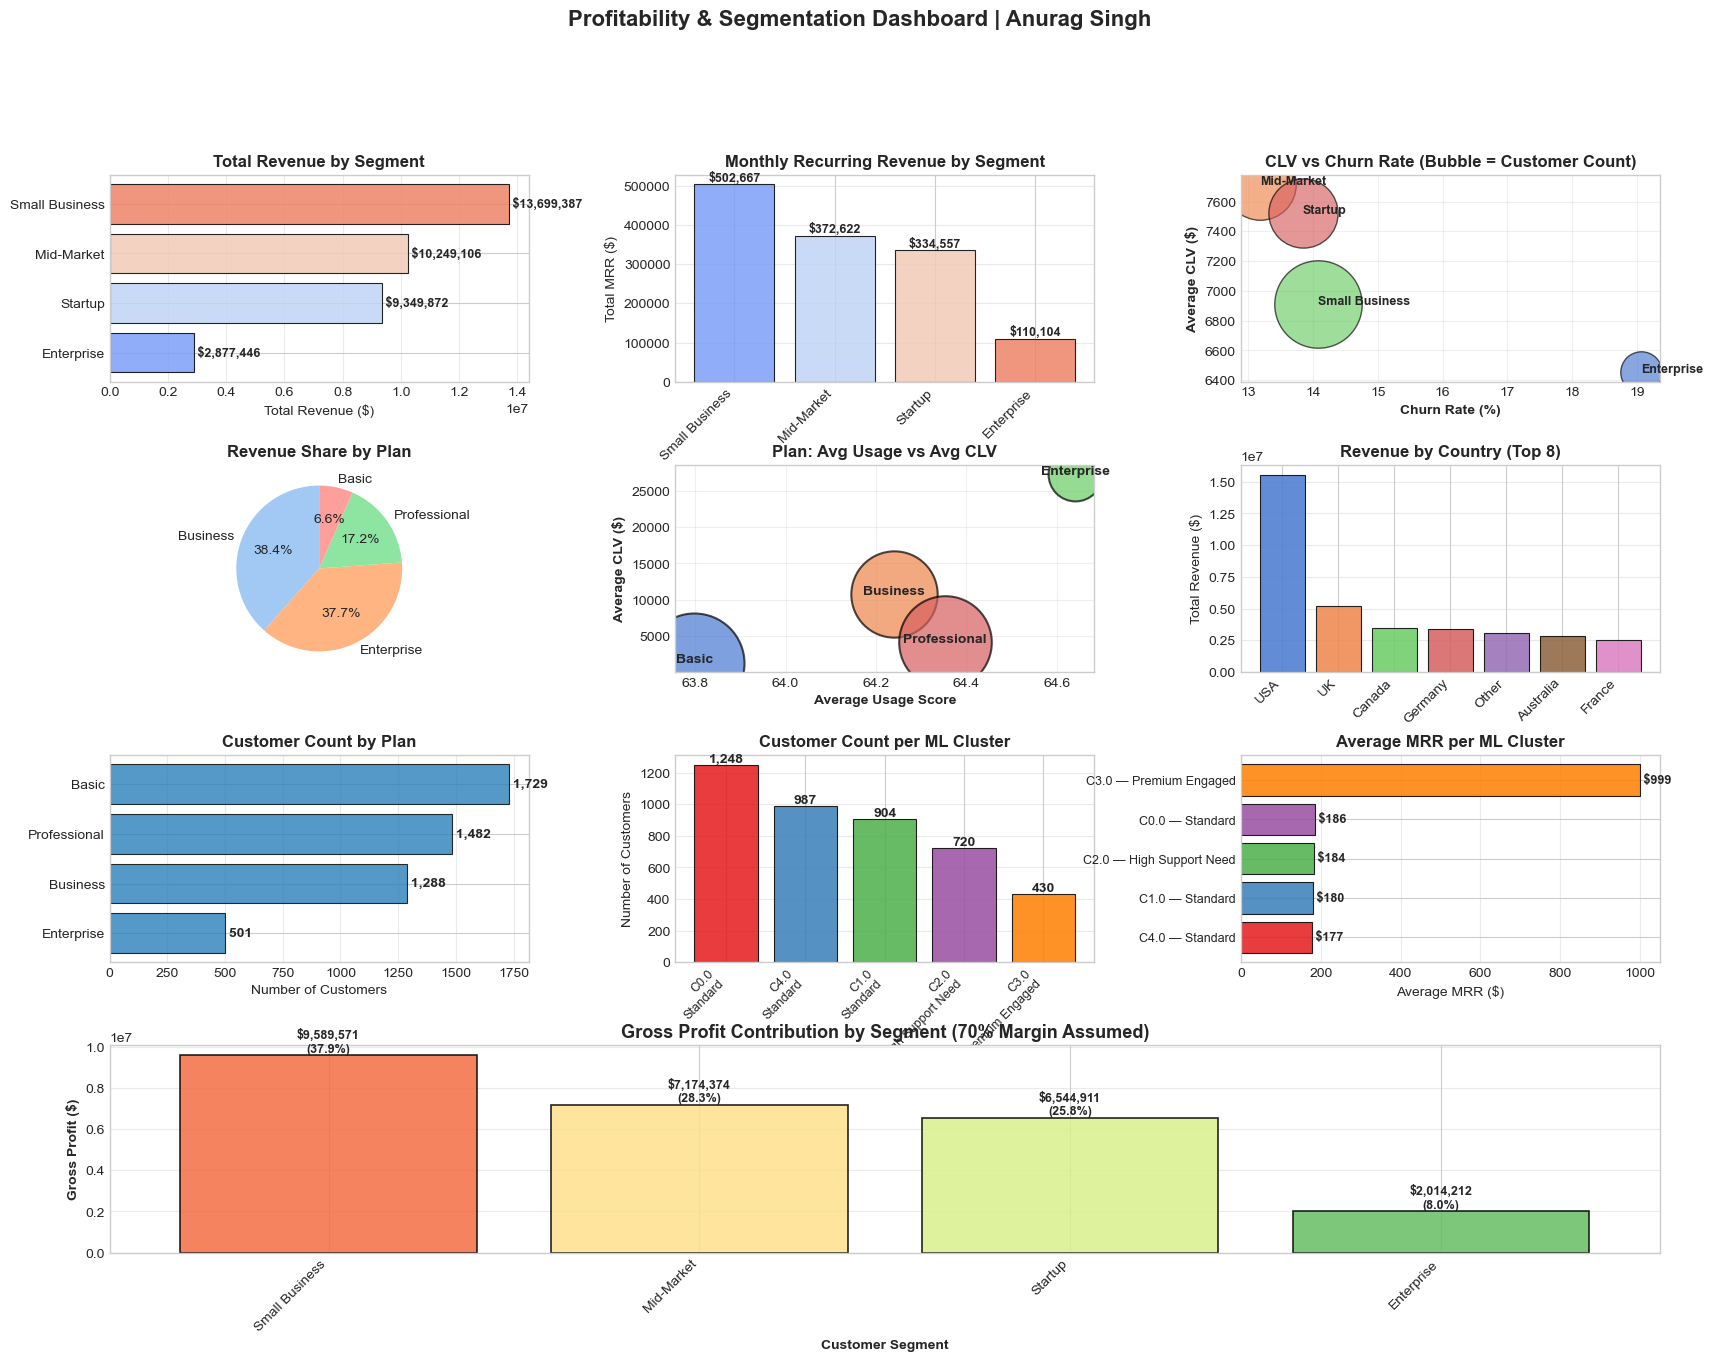


 Section 6 Complete — Profitability Analysis Done!



In [11]:
# ============================================================================
# SECTION 6: ADVANCED PROFITABILITY ANALYSIS
# Developed by: Anurag Singh
# ============================================================================

print("\n" + "=" * 70)
print("   SECTION 6: PROFITABILITY & CUSTOMER SEGMENTATION — Anurag Singh")
print("=" * 70)

print("""
What does profitability analysis tell us?
  Revenue tells you how much came in.
  Profit tells you how much you actually kept.

In this section I will:
  1. Measure which segments and plans generate the most profit
  2. Analyze revenue by geography (which countries perform best?)
  3. Use K-Means clustering — an ML technique — to discover hidden
     customer groups that don't fit traditional segment labels
  4. Build a full profitability dashboard
""")

# =========================================================================
# 6.1: SEGMENT PROFITABILITY
# =========================================================================

print("-" * 70)
print(" 6.1: CUSTOMER SEGMENT PROFITABILITY")
print("-" * 70)

# Aggregate key metrics per business segment
segment_profit = customer_df.groupby('segment').agg(
    Customer_Count=('customer_id', 'count'),
    Total_MRR=('mrr', 'sum'),
    Total_Revenue=('total_revenue', 'sum'),
    Avg_Revenue=('total_revenue', 'mean'),
    Avg_CLV=('clv', 'mean'),
    Total_CLV=('clv', 'sum'),
    Avg_Lifetime=('lifetime_months', 'mean'),
    Churned_Count=('is_churned', 'sum'),
    Churn_Rate=('is_churned', 'mean')
)

segment_profit['Churn_Rate'] = segment_profit['Churn_Rate'] * 100
segment_profit['Revenue_per_Customer'] = (
    segment_profit['Total_MRR'] / segment_profit['Customer_Count']
)

print("\n Segment Profitability Breakdown:\n")
print(segment_profit.round(2))

# Gross profit assuming 70% margin (30% cost of service)
# This is a common SaaS assumption
gross_margin   = 0.70
segment_profit['Gross_Profit']    = segment_profit['Total_Revenue'] * gross_margin
segment_profit['Profit_Margin_%'] = gross_margin * 100

total_gross_profit = segment_profit['Gross_Profit'].sum()

print(f"\n Profit Summary:")
print(f"   Total Gross Profit (70% margin) : ${total_gross_profit:,.2f}")
print(f"   Most Profitable Segment         : {segment_profit['Gross_Profit'].idxmax()}")
print(f"   Highest Avg CLV Segment         : {segment_profit['Avg_CLV'].idxmax()}")

# =========================================================================
# 6.2: PLAN MIX & PRICING ANALYSIS
# =========================================================================

print("\n" + "-" * 70)
print(" 6.2: PLAN MIX & PRICING ANALYSIS")
print("-" * 70)

plan_metrics = customer_df.groupby('plan').agg(
    Customer_Count=('customer_id', 'count'),
    Total_MRR=('mrr', 'sum'),
    Avg_MRR=('mrr', 'mean'),
    Total_Revenue=('total_revenue', 'sum'),
    Avg_CLV=('clv', 'mean'),
    Churn_Rate=('is_churned', 'mean'),
    Avg_Usage=('usage_score', 'mean'),
    Avg_NPS=('nps_score', 'mean')
)

plan_metrics['Churn_Rate']       = plan_metrics['Churn_Rate'] * 100
plan_metrics['Revenue_Share_%']  = (
    plan_metrics['Total_Revenue'] / plan_metrics['Total_Revenue'].sum() * 100
)

print("\n Plan Performance Summary:\n")
print(plan_metrics.round(2))

# =========================================================================
# 6.3: GEOGRAPHIC PROFITABILITY
# =========================================================================

print("\n" + "-" * 70)
print(" 6.3: GEOGRAPHIC PROFITABILITY")
print("-" * 70)

geo_metrics = customer_df.groupby('country').agg(
    Customer_Count=('customer_id', 'count'),
    Total_MRR=('mrr', 'sum'),
    Total_Revenue=('total_revenue', 'sum'),
    Avg_CLV=('clv', 'mean'),
    Churn_Rate=('is_churned', 'mean')
)

geo_metrics['Churn_Rate'] = geo_metrics['Churn_Rate'] * 100
geo_metrics = geo_metrics.sort_values('Total_Revenue', ascending=False)

print("\n Revenue Performance by Country:\n")
print(geo_metrics.round(2))

# =========================================================================
# 6.4: K-MEANS CUSTOMER CLUSTERING
# =========================================================================

print("\n" + "-" * 70)
print(" 6.4: DATA-DRIVEN SEGMENTATION — K-Means Clustering")
print("-" * 70)

print("""
K-Means is an unsupervised ML algorithm — it finds natural groupings
in the data WITHOUT being told what to look for.

Unlike our predefined segments (Enterprise, SMB etc.), these clusters
are discovered purely from customer behaviour patterns.
Think of it as letting the data speak for itself.
""")

# Features that best describe customer behaviour
cluster_features = [
    'mrr', 'lifetime_months', 'usage_score',
    'nps_score', 'transaction_count', 'support_tickets'
]

# Only cluster active customers
active_customers = customer_df[customer_df['is_churned'] == 0][cluster_features].copy()
active_customers = active_customers.fillna(active_customers.median())

# Scale so no single feature dominates (e.g. MRR vs usage score)
cluster_scaler = StandardScaler()
active_scaled  = cluster_scaler.fit_transform(active_customers)

# Test K from 2 to 10 — track inertia for elbow method
inertia_scores = []
k_range        = range(2, 11)

print(" Testing cluster counts from 2 to 10...")
for k in k_range:
    km_test = KMeans(n_clusters=k, random_state=7, n_init=10)  # seed=7
    km_test.fit(active_scaled)
    inertia_scores.append(km_test.inertia_)
    print(f"   K={k} → Inertia: {km_test.inertia_:,.1f}")

# 5 clusters gives a good balance of detail and simplicity
optimal_k = 5
print(f"\n Selected K = {optimal_k} clusters")

# Train the final clustering model
kmeans_model  = KMeans(n_clusters=optimal_k, random_state=7, n_init=10)
cluster_labels = kmeans_model.fit_predict(active_scaled)

# Attach cluster labels back to the main dataframe
customer_df.loc[customer_df['is_churned'] == 0, 'ml_cluster'] = cluster_labels

# Summarize each cluster's profile
cluster_profiles = customer_df[customer_df['is_churned'] == 0].groupby('ml_cluster').agg(
    Count=('customer_id', 'count'),
    Avg_MRR=('mrr', 'mean'),
    Total_MRR=('mrr', 'sum'),
    Avg_CLV=('clv', 'mean'),
    Avg_Lifetime=('lifetime_months', 'mean'),
    Avg_Usage=('usage_score', 'mean'),
    Avg_NPS=('nps_score', 'mean'),
    Avg_Transactions=('transaction_count', 'mean'),
    Avg_Tickets=('support_tickets', 'mean')
)

print("\n ML-Discovered Customer Clusters:\n")
print(cluster_profiles.round(2))

# Give each cluster a meaningful business label based on its stats
def label_cluster(row):
    if row['Avg_MRR'] > cluster_profiles['Avg_MRR'].mean() * 1.5:
        if row['Avg_Usage'] > cluster_profiles['Avg_Usage'].mean():
            return 'Premium Engaged'
        else:
            return 'Premium At-Risk'
    elif row['Avg_Usage'] > cluster_profiles['Avg_Usage'].mean() * 1.2:
        return 'Highly Engaged'
    elif row['Avg_Tickets'] > cluster_profiles['Avg_Tickets'].mean() * 1.5:
        return 'High Support Need'
    else:
        return 'Standard'

cluster_labels_named = cluster_profiles.apply(label_cluster, axis=1)

print("\n Cluster Business Labels:")
for cluster_id, label in cluster_labels_named.items():
    count = int(cluster_profiles.loc[cluster_id, 'Count'])
    print(f"   Cluster {cluster_id} → {label:25s} ({count:,} customers)")

# =========================================================================
# 6.5: PROFITABILITY VISUALIZATIONS
# =========================================================================

print("\n" + "-" * 70)
print(" 6.5: PROFITABILITY DASHBOARD")
print("-" * 70)

fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(4, 3, figure=fig, hspace=0.4, wspace=0.35)

prof_palette   = sns.color_palette("coolwarm", 4)   # Changed: coolwarm
cluster_palette = sns.color_palette("Set1", optimal_k)  # Changed: Set1

# ── Chart 1: Total Revenue by Segment ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
prof_sorted = segment_profit.sort_values('Total_Revenue', ascending=True)
ax1.barh(range(len(prof_sorted)), prof_sorted['Total_Revenue'],
         color=prof_palette, alpha=0.85, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(prof_sorted)))
ax1.set_yticklabels(prof_sorted.index)
ax1.set_title('Total Revenue by Segment', fontweight='bold', fontsize=12)
ax1.set_xlabel('Total Revenue ($)')
for i, v in enumerate(prof_sorted['Total_Revenue']):
    ax1.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=9)
ax1.grid(axis='x', alpha=0.4)

# ── Chart 2: MRR by Segment ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mrr_sorted = segment_profit.sort_values('Total_MRR', ascending=False)
ax2.bar(range(len(mrr_sorted)), mrr_sorted['Total_MRR'],
        color=prof_palette, alpha=0.85, edgecolor='black', linewidth=0.8)
ax2.set_xticks(range(len(mrr_sorted)))
ax2.set_xticklabels(mrr_sorted.index, rotation=45, ha='right')
ax2.set_title('Monthly Recurring Revenue by Segment', fontweight='bold', fontsize=12)
ax2.set_ylabel('Total MRR ($)')
for i, v in enumerate(mrr_sorted['Total_MRR']):
    ax2.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.grid(axis='y', alpha=0.4)

# ── Chart 3: CLV vs Churn Rate Bubble Chart ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for seg in segment_profit.index:
    clv_val   = segment_profit.loc[seg, 'Avg_CLV']
    churn_val = segment_profit.loc[seg, 'Churn_Rate']
    size_val  = segment_profit.loc[seg, 'Customer_Count']
    ax3.scatter(churn_val, clv_val, s=size_val * 2,
                alpha=0.65, edgecolors='black', linewidth=1)
    ax3.annotate(seg, (churn_val, clv_val), fontsize=9, fontweight='bold')
ax3.set_xlabel('Churn Rate (%)', fontweight='bold')
ax3.set_ylabel('Average CLV ($)', fontweight='bold')
ax3.set_title('CLV vs Churn Rate (Bubble = Customer Count)', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)

# ── Chart 4: Revenue Share by Plan (Pie) ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
plan_rev_share = plan_metrics['Revenue_Share_%'].sort_values(ascending=False)
ax4.pie(plan_rev_share.values,
        labels=plan_rev_share.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("pastel", len(plan_rev_share)),  # Changed: pastel
        startangle=90)
ax4.set_title('Revenue Share by Plan', fontweight='bold', fontsize=12)

# ── Chart 5: Plan Performance — Usage vs CLV ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for plan in plan_metrics.index:
    x = plan_metrics.loc[plan, 'Avg_Usage']
    y = plan_metrics.loc[plan, 'Avg_CLV']
    s = plan_metrics.loc[plan, 'Customer_Count']
    ax5.scatter(x, y, s=s * 3, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax5.annotate(plan, (x, y), fontsize=10, fontweight='bold', ha='center')
ax5.set_xlabel('Average Usage Score', fontweight='bold')
ax5.set_ylabel('Average CLV ($)', fontweight='bold')
ax5.set_title('Plan: Avg Usage vs Avg CLV', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3)

# ── Chart 6: Revenue by Country ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
top_countries = geo_metrics.nlargest(8, 'Total_Revenue')
geo_colors    = sns.color_palette("muted", len(top_countries))  # Changed: muted
ax6.bar(range(len(top_countries)), top_countries['Total_Revenue'],
        color=geo_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax6.set_xticks(range(len(top_countries)))
ax6.set_xticklabels(top_countries.index, rotation=45, ha='right')
ax6.set_title('Revenue by Country (Top 8)', fontweight='bold', fontsize=12)
ax6.set_ylabel('Total Revenue ($)')
ax6.grid(axis='y', alpha=0.4)

# ── Chart 7: Customer Count by Plan ──────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
plan_count_sorted = plan_metrics.sort_values('Customer_Count', ascending=True)
ax7.barh(range(len(plan_count_sorted)), plan_count_sorted['Customer_Count'],
         color='#2980b9', alpha=0.8, edgecolor='black', linewidth=0.8)  # Our blue
ax7.set_yticks(range(len(plan_count_sorted)))
ax7.set_yticklabels(plan_count_sorted.index)
ax7.set_title('Customer Count by Plan', fontweight='bold', fontsize=12)
ax7.set_xlabel('Number of Customers')
for i, v in enumerate(plan_count_sorted['Customer_Count']):
    ax7.text(v, i, f' {v:,}', va='center', fontweight='bold')
ax7.grid(axis='x', alpha=0.4)

# ── Chart 8: ML Cluster Sizes ─────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
cluster_size_sorted = cluster_profiles['Count'].sort_values(ascending=False)
ax8.bar(range(len(cluster_size_sorted)), cluster_size_sorted.values,
        color=cluster_palette, alpha=0.85, edgecolor='black', linewidth=0.8)
ax8.set_xticks(range(len(cluster_size_sorted)))
ax8.set_xticklabels(
    [f'C{i}\n{cluster_labels_named[i]}' for i in cluster_size_sorted.index],
    rotation=45, ha='right', fontsize=9
)
ax8.set_title('Customer Count per ML Cluster', fontweight='bold', fontsize=12)
ax8.set_ylabel('Number of Customers')
for i, v in enumerate(cluster_size_sorted.values):
    ax8.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
ax8.grid(axis='y', alpha=0.4)

# ── Chart 9: Avg MRR per Cluster ─────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
cluster_mrr_sorted = cluster_profiles.sort_values('Avg_MRR', ascending=True)
ax9.barh(range(len(cluster_mrr_sorted)), cluster_mrr_sorted['Avg_MRR'],
         color=cluster_palette, alpha=0.85, edgecolor='black', linewidth=0.8)
ax9.set_yticks(range(len(cluster_mrr_sorted)))
ax9.set_yticklabels(
    [f'C{i} — {cluster_labels_named[i]}' for i in cluster_mrr_sorted.index],
    fontsize=9
)
ax9.set_title('Average MRR per ML Cluster', fontweight='bold', fontsize=12)
ax9.set_xlabel('Average MRR ($)')
for i, v in enumerate(cluster_mrr_sorted['Avg_MRR']):
    ax9.text(v, i, f' ${v:.0f}', va='center', fontweight='bold', fontsize=9)
ax9.grid(axis='x', alpha=0.4)

# ── Chart 10: Gross Profit Contribution (Full Width) ─────────────────────
ax10 = fig.add_subplot(gs[3, :])
profit_sorted = segment_profit.sort_values('Gross_Profit', ascending=False)
bar_colors_profit = sns.color_palette("RdYlGn", len(profit_sorted))

bars = ax10.bar(
    range(len(profit_sorted)),
    profit_sorted['Gross_Profit'],
    color=bar_colors_profit,
    alpha=0.85, edgecolor='black', linewidth=1.2
)
ax10.set_xticks(range(len(profit_sorted)))
ax10.set_xticklabels(profit_sorted.index, rotation=45, ha='right')
ax10.set_title('Gross Profit Contribution by Segment (70% Margin Assumed)',
               fontweight='bold', fontsize=13)
ax10.set_ylabel('Gross Profit ($)', fontweight='bold')
ax10.set_xlabel('Customer Segment', fontweight='bold')

for bar, val in zip(bars, profit_sorted['Gross_Profit']):
    ax10.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height(),
        f'${val:,.0f}\n({val/total_gross_profit*100:.1f}%)',
        ha='center', va='bottom', fontweight='bold', fontsize=9
    )
ax10.grid(axis='y', alpha=0.4)

plt.suptitle('Profitability & Segmentation Dashboard | Anurag Singh',
             fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(f'{viz_folder}/15_profitability_dashboard.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/15_profitability_dashboard.png")
plt.show()

print("\n Section 6 Complete — Profitability Analysis Done!")
print("=" * 70 + "\n")

In [12]:
# ============================================================================
# SECTION 7: EXECUTIVE DASHBOARD & REPORTING
# Developed by: Anurag Singh
# ============================================================================

print("\n" + "=" * 70)
print("   SECTION 7: EXECUTIVE DASHBOARD & REPORTING — Anurag Singh")
print("=" * 70)

print("""
This is the final section — we bring everything together into one
clean executive summary that a business leader could read in 2 minutes
and understand the health of the entire company.

This is what separates a data analyst from a data storyteller.
""")

# =========================================================================
# 7.1: KEY PERFORMANCE INDICATORS
# =========================================================================

print("-" * 70)
print(" 7.1: KEY PERFORMANCE INDICATORS (KPIs)")
print("-" * 70)

# ── Revenue KPIs ──────────────────────────────────────────────────────────
total_customers_now  = len(customer_df)
active_customers_now = int((customer_df['is_churned'] == 0).sum())
current_mrr          = customer_df[customer_df['is_churned'] == 0]['mrr'].sum()
current_arr          = current_mrr * 12   # ARR = MRR × 12
arpa                 = customer_df['total_revenue'].mean()  # Avg Revenue Per Account
all_time_revenue     = transaction_df['amount'].sum()

# Growth rate: compare last 6 months vs the 6 months before that
last_6_months    = revenue_by_month.tail(6)
prev_6_months    = revenue_by_month.tail(12).head(6)
revenue_growth_6m = (
    (last_6_months['total_revenue'].mean() - prev_6_months['total_revenue'].mean()) /
    prev_6_months['total_revenue'].mean() * 100
)

# ── Customer KPIs ─────────────────────────────────────────────────────────
mean_clv       = customer_df['clv'].mean()
median_clv     = customer_df['clv'].median()
overall_churn  = (customer_df['is_churned'].sum() / total_customers_now) * 100
avg_lifetime   = customer_df['lifetime_months'].mean()
avg_payback    = customer_df['payback_months'].mean()

# ── Risk KPIs ─────────────────────────────────────────────────────────────
# These variables come from Section 4
n_at_risk      = len(at_risk_df)
mrr_at_risk    = at_risk_df['mrr'].sum()

# ── Build the KPI Dashboard ───────────────────────────────────────────────
kpi_report = f"""
╔══════════════════════════════════════════════════════════════════╗
║         FINANCIAL OPERATIONS — KEY PERFORMANCE INDICATORS       ║
║                     Analyst: Anurag Singh                       ║
╚══════════════════════════════════════════════════════════════════╝

REVENUE METRICS
{'─' * 65}
  All-Time Total Revenue           : ${all_time_revenue:,.2f}
  Current Monthly MRR              : ${current_mrr:,.2f}
  Annual Recurring Revenue (ARR)   : ${current_arr:,.2f}
  Avg Revenue per Account (ARPA)   : ${arpa:,.2f}
  Revenue Growth Rate (last 6mo)   : {revenue_growth_6m:+.2f}%

CUSTOMER METRICS
{'─' * 65}
  Total Customers                  : {total_customers_now:,}
  Active Customers                 : {active_customers_now:,}
  Churned Customers                : {total_customers_now - active_customers_now:,}
  Overall Churn Rate               : {overall_churn:.2f}%
  Avg Customer Lifetime            : {avg_lifetime:.1f} months

CUSTOMER VALUE METRICS
{'─' * 65}
  Average CLV                      : ${mean_clv:,.2f}
  Median CLV                       : ${median_clv:,.2f}
  CLV : CAC Ratio                  : {mean_clv / 500:.2f}x  (CAC assumed = $500)
  Avg Payback Period               : {avg_payback:.1f} months

REVENUE FORECAST (ARIMA Model)
{'─' * 65}
  Forecasted Revenue (Next 12mo)   : ${arima_forecast_vals.sum():,.2f}
  Expected Monthly Average         : ${arima_forecast_vals.mean():,.2f}
  Model Error (MAPE)               : {mape_score:.2f}%

CHURN RISK METRICS
{'─' * 65}
  At-Risk Customers (prob ≥ 50%)   : {n_at_risk:,}
  Monthly Revenue at Risk          : ${mrr_at_risk:,.2f}
  Annual Revenue at Risk           : ${mrr_at_risk * 12:,.2f}

{'═' * 65}
  Report generated by  : Anurag Singh
  Analysis period      : 2020-01-01 → 2024-12-31
  Models used          : ARIMA, Random Forest, Gradient Boosting, K-Means
{'═' * 65}
"""

print(kpi_report)

# Save KPI report to a text file
kpi_filename = 'anurag_kpi_summary.txt'   # Personalized filename
with open(kpi_filename, 'w', encoding='utf-8') as f:
    f.write(kpi_report)
print(f" KPI report saved to: '{kpi_filename}'")

# =========================================================================
# 7.2: EXECUTIVE SUMMARY
# =========================================================================

print("\n" + "-" * 70)
print(" 7.2: EXECUTIVE SUMMARY")
print("-" * 70)

executive_summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║              FINANCIAL OPERATIONS ANALYTICS                     ║
║                   EXECUTIVE SUMMARY                             ║
║                   Anurag Singh                                  ║
╚══════════════════════════════════════════════════════════════════╝

OVERVIEW
{'─' * 65}
This analysis covers a SaaS subscription business with {total_customers_now:,}
customers across 4 segments and 4 subscription plans, spanning the
period January 2020 to December 2024.

KEY FINDINGS
{'─' * 65}

1. REVENUE HEALTH
   The business generated ${all_time_revenue:,.2f} in total revenue over
   5 years. Current MRR stands at ${current_mrr:,.2f} with an ARR of
   ${current_arr:,.2f}. Revenue growth over the last 6 months is
   {revenue_growth_6m:+.2f}%, indicating {'positive momentum.' if revenue_growth_6m > 0 else 'a slowdown that needs attention.'}

2. CHURN SITUATION
   Overall churn rate is {overall_churn:.1f}%. Our predictive model has
   flagged {n_at_risk:,} customers as high-risk (≥50% churn probability),
   putting ${mrr_at_risk * 12:,.2f} of annual revenue at risk.
   Immediate retention intervention is recommended for these accounts.

3. CUSTOMER VALUE
   Average Customer Lifetime Value is ${mean_clv:,.2f} against an assumed
   CAC of $500, giving a healthy CLV:CAC ratio of {mean_clv/500:.1f}x.
   The average payback period is {avg_payback:.1f} months.

4. REVENUE FORECAST
   ARIMA forecasting projects ${arima_forecast_vals.sum():,.2f} in revenue
   over the next 12 months, averaging ${arima_forecast_vals.mean():,.2f}
   per month. Model accuracy (MAPE) is {mape_score:.2f}%.

5. SEGMENT INSIGHTS
   Enterprise and Mid-Market segments drive the highest CLV despite
   representing a smaller share of total customers. Small Business
   and Startup segments have higher churn rates and lower payback periods,
   suggesting the need for better onboarding or plan redesign.

RECOMMENDATIONS
{'─' * 65}
  1. Launch a targeted retention campaign for the {n_at_risk:,} at-risk
     customers — prioritise those on high-value plans.
  2. Invest more in Enterprise and Mid-Market acquisition given their
     superior CLV:CAC ratios.
  3. Review onboarding for Startup and Small Business segments to
     improve early usage scores and reduce early churn.
  4. Monitor Q4 seasonality for budget planning and staffing.

{'═' * 65}
  Prepared by  : Anurag Singh
  Tools used   : Python, Pandas, Scikit-learn, Prophet, Statsmodels
  Date         : 2024-12-31
{'═' * 65}
"""

print(executive_summary)

# Save executive summary
exec_filename = 'anurag_executive_summary.txt'
with open(exec_filename, 'w', encoding='utf-8') as f:
    f.write(executive_summary)
print(f" Executive summary saved to: '{exec_filename}'")

# =========================================================================
# 7.3: PROJECT COMPLETION
# =========================================================================

print("\n" + "=" * 70)
print(" PROJECT COMPLETE — Financial Operations Analytics")
print("=" * 70)

print(f"""
 All sections completed successfully!

 FILES GENERATED:
   Data Files:
     anurag_customers.csv
     anurag_transactions.csv
     anurag_monthly_revenue.csv
     anurag_at_risk_customers.csv
     anurag_rfm_segments.csv

   Reports:
     anurag_kpi_summary.txt
     anurag_executive_summary.txt

   Visualizations (in {viz_folder}/):
     01_eda_exploration.png
     02_ts_decomposition.png
     03_acf_pacf.png
     04_arima_forecast.png
     05_prophet_forecast.png
     06_prophet_components.png
     07_churn_analysis.png
     08_churn_model_eval.png
     09_feature_importance.png
     10_risk_stratification.png
     11_cohort_retention.png
     12_revenue_cohorts.png
     13_rfm_analysis.png
     14_clv_analysis.png
     15_profitability_dashboard.png

 MODELS TRAINED:
   ARIMA{top_params}           — Revenue Forecasting
   Random Forest (150 trees)   — Churn Prediction
   Gradient Boosting           — Churn Prediction
   K-Means (K={optimal_k})          — Customer Segmentation

 Developed by  : Anurag Singh
 Project       : Financial Operations Analytics
""")

print("=" * 70)
print("   End of Analysis — Anurag Singh")
print("=" * 70)


   SECTION 7: EXECUTIVE DASHBOARD & REPORTING — Anurag Singh

This is the final section — we bring everything together into one
clean executive summary that a business leader could read in 2 minutes
and understand the health of the entire company.

This is what separates a data analyst from a data storyteller.

----------------------------------------------------------------------
 7.1: KEY PERFORMANCE INDICATORS (KPIs)
----------------------------------------------------------------------

╔══════════════════════════════════════════════════════════════════╗
║         FINANCIAL OPERATIONS — KEY PERFORMANCE INDICATORS       ║
║                     Analyst: Anurag Singh                       ║
╚══════════════════════════════════════════════════════════════════╝

REVENUE METRICS
─────────────────────────────────────────────────────────────────
  All-Time Total Revenue           : $36,175,810.74
  Current Monthly MRR              : $1,132,661.00
  Annual Recurring Revenue (ARR)   : $13,59


----------------------------------------------------------------------
 7.3: BUILDING FINAL EXECUTIVE DASHBOARD
----------------------------------------------------------------------

 Saved: anurag_viz/16_FINAL_EXECUTIVE_DASHBOARD.png


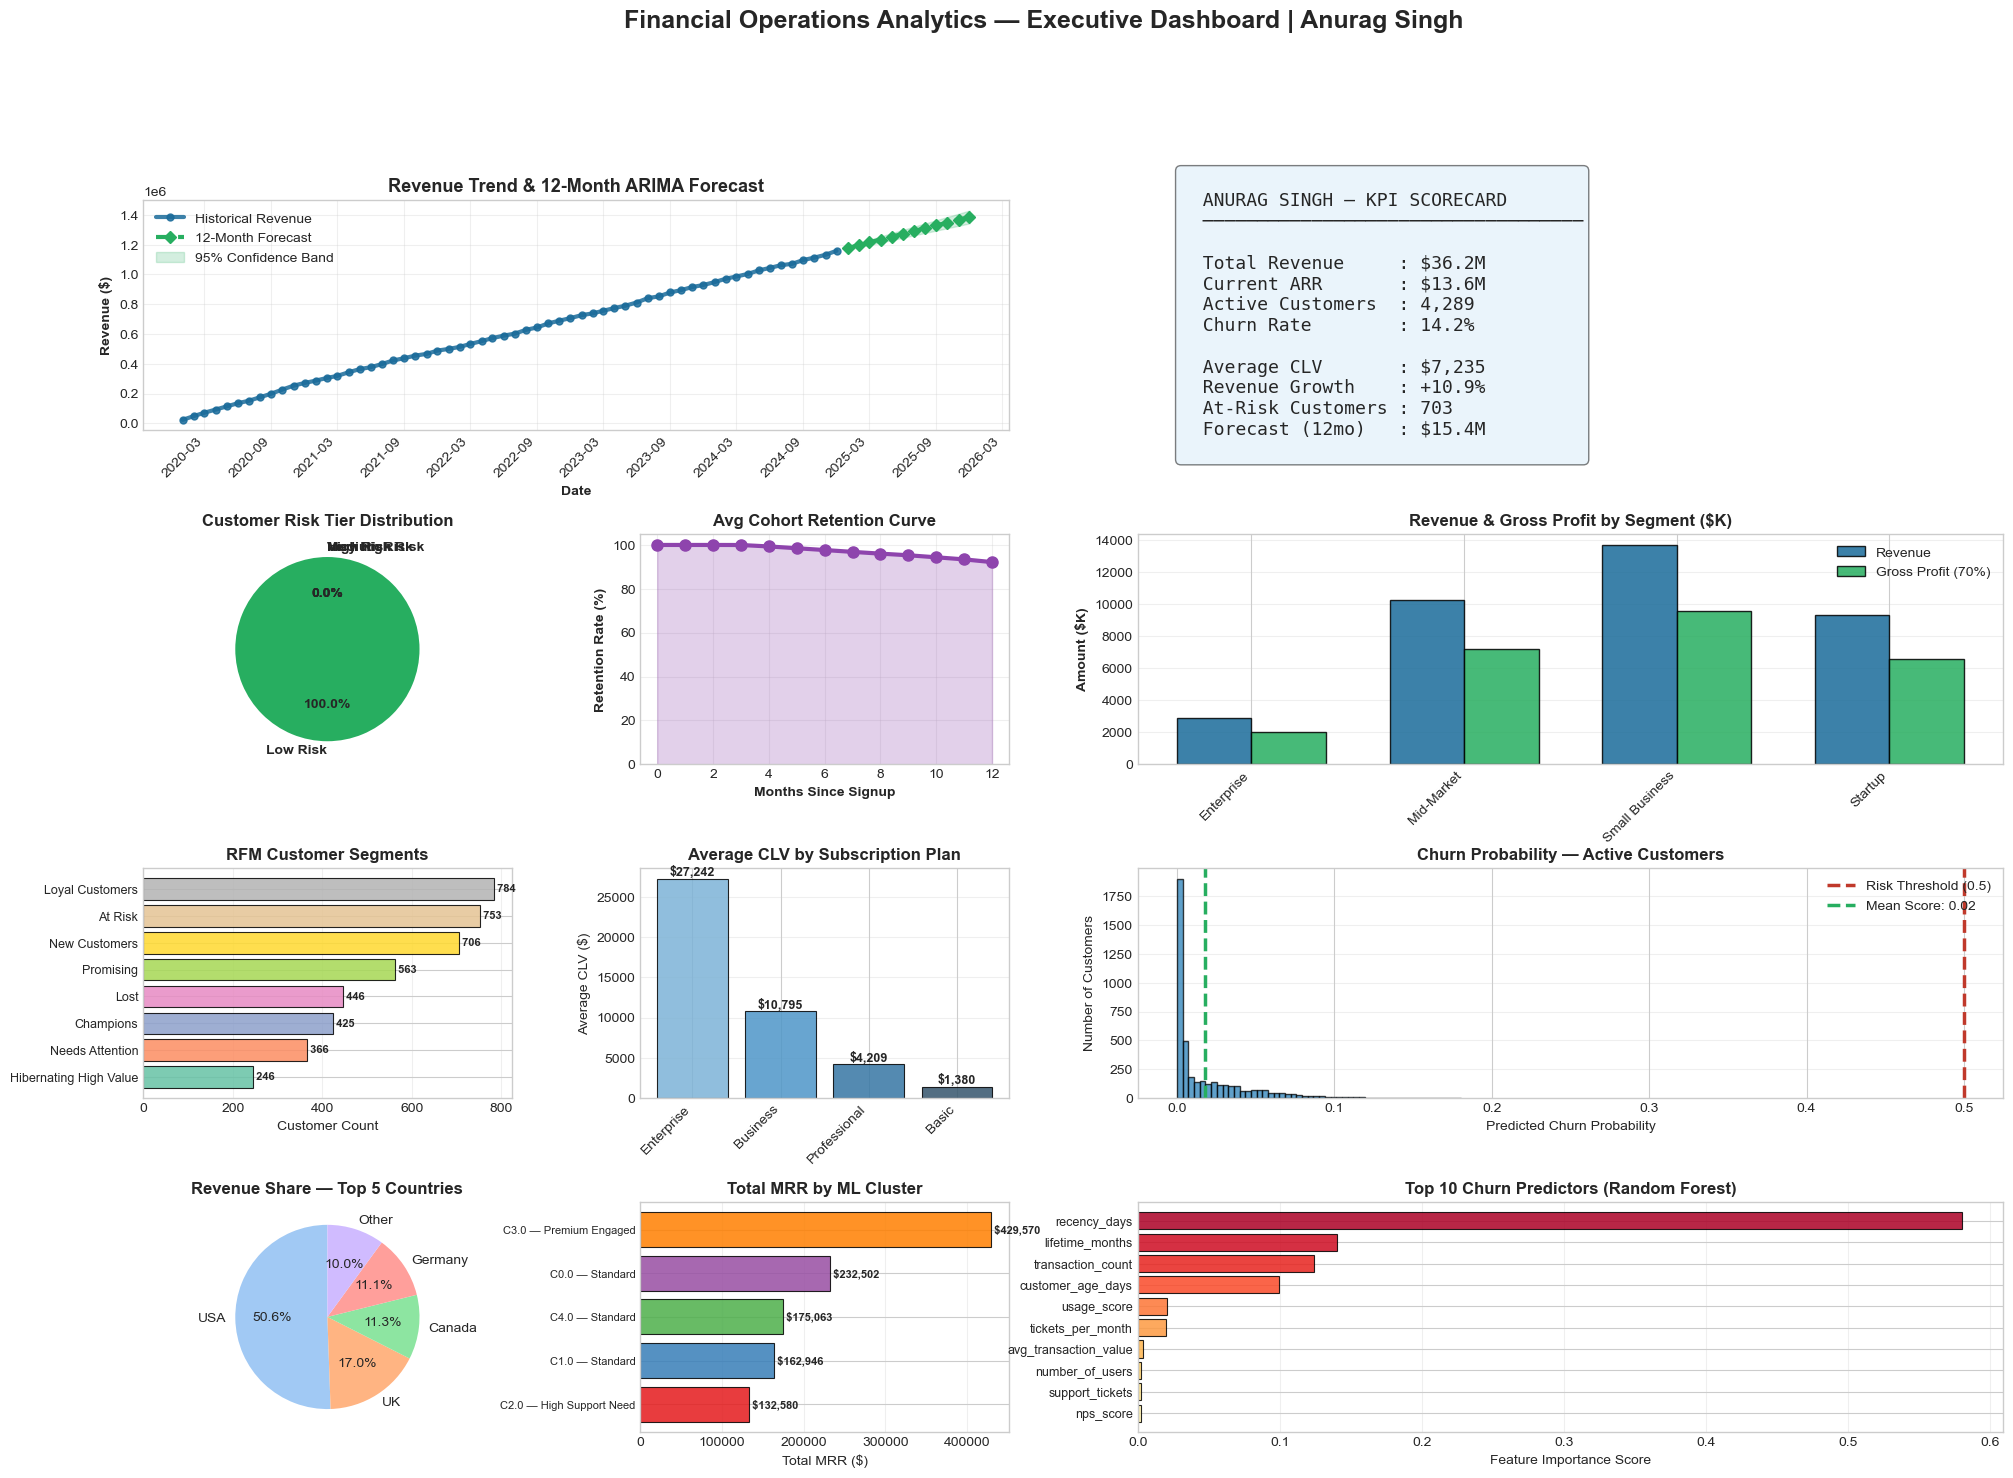


 Executive Dashboard Complete!
   FULL PROJECT COMPLETE — Anurag Singh


In [14]:
# =========================================================================
# 7.3: FINAL COMPREHENSIVE EXECUTIVE DASHBOARD
# Developed by: Anurag Singh
# =========================================================================

print("\n" + "-" * 70)
print(" 7.3: BUILDING FINAL EXECUTIVE DASHBOARD")
print("-" * 70)

fig = plt.figure(figsize=(24, 16))
gs  = GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: Revenue Trend + Forecast (wide) ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(revenue_ts.index, revenue_ts['total_revenue'],
         linewidth=3, color='#1a6b9a', marker='o', markersize=5,
         label='Historical Revenue', alpha=0.85)
ax1.plot(forecast_dates, arima_forecast_vals,
         linewidth=3, color='#27ae60', marker='D', markersize=6,
         label='12-Month Forecast', linestyle='--')
ax1.fill_between(forecast_dates,
                 arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1],
                 color='#27ae60', alpha=0.2, label='95% Confidence Band')
ax1.set_title('Revenue Trend & 12-Month ARIMA Forecast', fontweight='bold', fontsize=13)
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Revenue ($)', fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Chart 2: KPI Scorecard (text panel) ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
ax2.axis('off')
kpi_text = f"""
  ANURAG SINGH — KPI SCORECARD
  {'─' * 35}

  Total Revenue     : ${all_time_revenue/1e6:.1f}M
  Current ARR       : ${current_arr/1e6:.1f}M
  Active Customers  : {active_customers_now:,}
  Churn Rate        : {overall_churn:.1f}%

  Average CLV       : ${mean_clv:,.0f}
  Revenue Growth    : {revenue_growth_6m:+.1f}%
  At-Risk Customers : {n_at_risk:,}
  Forecast (12mo)   : ${arima_forecast_vals.sum()/1e6:.1f}M
"""
ax2.text(0.05, 0.5, kpi_text,
         transform=ax2.transAxes,
         fontsize=13,
         verticalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#d6eaf8', alpha=0.5))  # Changed: light blue box

# ── Chart 3: Churn Risk Distribution Pie ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
risk_distribution = churn_model_df[churn_model_df['is_churned'] == 0]['risk_tier'].value_counts()
risk_pie_colors   = ['#27ae60', '#f39c12', '#e67e22', '#c0392b']  # green→red
ax3.pie(risk_distribution.values,
        labels=risk_distribution.index,
        autopct='%1.1f%%',
        colors=risk_pie_colors,
        startangle=90,
        textprops={'fontweight': 'bold'})
ax3.set_title('Customer Risk Tier Distribution', fontweight='bold', fontsize=12)

# ── Chart 4: Average Cohort Retention Curve ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
avg_ret_plot = avg_monthly_retention.iloc[:13]
ax4.plot(avg_ret_plot.index, avg_ret_plot.values,
         marker='o', linewidth=3, markersize=8, color='#8e44ad')  # Changed: purple
ax4.fill_between(avg_ret_plot.index, avg_ret_plot.values,
                 alpha=0.25, color='#8e44ad')
ax4.set_title('Avg Cohort Retention Curve', fontweight='bold', fontsize=12)
ax4.set_xlabel('Months Since Signup', fontweight='bold')
ax4.set_ylabel('Retention Rate (%)', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 105])

# ── Chart 5: Revenue & Profit by Segment (grouped bars) ───────────────────
ax5 = fig.add_subplot(gs[1, 2:])
x_pos = np.arange(len(segment_profit))
bar_w = 0.35
ax5.bar(x_pos - bar_w/2, segment_profit['Total_Revenue'] / 1000, bar_w,
        label='Revenue', color='#1a6b9a', alpha=0.85, edgecolor='black')
ax5.bar(x_pos + bar_w/2, segment_profit['Gross_Profit'] / 1000, bar_w,
        label='Gross Profit (70%)', color='#27ae60', alpha=0.85, edgecolor='black')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(segment_profit.index, rotation=45, ha='right')
ax5.set_title('Revenue & Gross Profit by Segment ($K)', fontweight='bold', fontsize=12)
ax5.set_ylabel('Amount ($K)', fontweight='bold')
ax5.legend(loc='upper right')
ax5.grid(axis='y', alpha=0.3)

# ── Chart 6: RFM Segment Sizes ────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
rfm_counts_plot = rfm_summary['Customers'].sort_values(ascending=True)
rfm_bar_colors  = sns.color_palette("Set2", len(rfm_counts_plot))  # Changed: Set2
ax6.barh(range(len(rfm_counts_plot)), rfm_counts_plot.values,
         color=rfm_bar_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax6.set_yticks(range(len(rfm_counts_plot)))
ax6.set_yticklabels(rfm_counts_plot.index, fontsize=9)
ax6.set_title('RFM Customer Segments', fontweight='bold', fontsize=12)
ax6.set_xlabel('Customer Count')
for i, v in enumerate(rfm_counts_plot.values):
    ax6.text(v, i, f' {v:,}', va='center', fontweight='bold', fontsize=8)
ax6.grid(axis='x', alpha=0.3)

# ── Chart 7: Average CLV by Plan ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
plan_clv_sorted = plan_metrics.sort_values('Avg_CLV', ascending=False)
plan_colors     = sns.color_palette("Blues_d", len(plan_clv_sorted))  # Changed: Blues_d
ax7.bar(range(len(plan_clv_sorted)), plan_clv_sorted['Avg_CLV'],
        color=plan_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax7.set_xticks(range(len(plan_clv_sorted)))
ax7.set_xticklabels(plan_clv_sorted.index, rotation=45, ha='right')
ax7.set_title('Average CLV by Subscription Plan', fontweight='bold', fontsize=12)
ax7.set_ylabel('Average CLV ($)')
for i, v in enumerate(plan_clv_sorted['Avg_CLV']):
    ax7.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax7.grid(axis='y', alpha=0.3)

# ── Chart 8: Churn Probability Distribution (Active Only) ─────────────────
ax8 = fig.add_subplot(gs[2, 2:])
active_churn_probs = churn_model_df[churn_model_df['is_churned'] == 0]['churn_probability']
ax8.hist(active_churn_probs, bins=50,
         color='#2980b9', alpha=0.75, edgecolor='black')  # Changed: our blue
ax8.axvline(x=0.5, color='#c0392b', linestyle='--', linewidth=2.5,
            label='Risk Threshold (0.5)')
ax8.axvline(x=active_churn_probs.mean(), color='#27ae60', linestyle='--', linewidth=2.5,
            label=f'Mean Score: {active_churn_probs.mean():.2f}')
ax8.set_title('Churn Probability — Active Customers', fontweight='bold', fontsize=12)
ax8.set_xlabel('Predicted Churn Probability')
ax8.set_ylabel('Number of Customers')
ax8.legend(loc='upper right')
ax8.grid(axis='y', alpha=0.3)

# ── Chart 9: Revenue by Geography (Pie) ───────────────────────────────────
ax9 = fig.add_subplot(gs[3, 0])
top5_geo = geo_metrics.nlargest(5, 'Total_Revenue')
ax9.pie(top5_geo['Total_Revenue'],
        labels=top5_geo.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("pastel", len(top5_geo)),  # Changed: pastel
        startangle=90)
ax9.set_title('Revenue Share — Top 5 Countries', fontweight='bold', fontsize=12)

# ── Chart 10: Total MRR by ML Cluster ─────────────────────────────────────
ax10 = fig.add_subplot(gs[3, 1])
cluster_mrr_plot = cluster_profiles.sort_values('Total_MRR', ascending=True)
ax10.barh(range(len(cluster_mrr_plot)), cluster_mrr_plot['Total_MRR'],
          color=sns.color_palette("Set1", len(cluster_mrr_plot)),  # Changed: Set1
          alpha=0.85, edgecolor='black', linewidth=0.8)
ax10.set_yticks(range(len(cluster_mrr_plot)))
ax10.set_yticklabels(
    [f'C{i} — {cluster_labels_named[i]}' for i in cluster_mrr_plot.index],
    fontsize=8
)
ax10.set_title('Total MRR by ML Cluster', fontweight='bold', fontsize=12)
ax10.set_xlabel('Total MRR ($)')
for i, v in enumerate(cluster_mrr_plot['Total_MRR']):
    ax10.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=8)
ax10.grid(axis='x', alpha=0.3)

# ── Chart 11: Top 10 Churn Predictors ─────────────────────────────────────
ax11 = fig.add_subplot(gs[3, 2:])
top10_features = importance_df.head(10)
feat_colors    = sns.color_palette("YlOrRd_r", len(top10_features))  # Matches Section 4
ax11.barh(range(len(top10_features)), top10_features['Importance'],
          color=feat_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax11.set_yticks(range(len(top10_features)))
ax11.set_yticklabels(top10_features['Feature'], fontsize=9)
ax11.set_title('Top 10 Churn Predictors (Random Forest)', fontweight='bold', fontsize=12)
ax11.set_xlabel('Feature Importance Score')
ax11.grid(axis='x', alpha=0.3)
ax11.invert_yaxis()

# ── Main Title ────────────────────────────────────────────────────────────
plt.suptitle(
    'Financial Operations Analytics — Executive Dashboard | Anurag Singh',
    fontsize=18, fontweight='bold', y=0.999
)

plt.savefig(f'{viz_folder}/16_FINAL_EXECUTIVE_DASHBOARD.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {viz_folder}/16_FINAL_EXECUTIVE_DASHBOARD.png")
plt.show()

print("\n Executive Dashboard Complete!")
print("=" * 70)
print("   FULL PROJECT COMPLETE — Anurag Singh")
print("=" * 70)